<a href="https://colab.research.google.com/github/giorrdanna/L-gica-de-Programa-o-HTML-e-JS/blob/main/SinaisDeVoz_Giordanna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo

Investigar de forma sistemática as propriedades acústicas e demográficas do conjunto de dados *“Parkinson’s Speech with Multiple Types of Sound Recordings”*, visando entender como características vocais e variáveis clínicas se comportam entre indivíduos com doença de Parkinson (PD) e controles saudáveis.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving test_data.txt to test_data.txt
Saving train_data.txt to train_data.txt


# 1) Análise Exploratória Inicial

In [ ]:
import pandas as pd
import numpy as np

# Ler o dataset (sem cabeçalho)
train = pd.read_csv("train_data.txt", header=None)
test = pd.read_csv("test_data.txt", header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1040, 29)
Test shape: (168, 28)


Treino: 40 pessoas (20 PD, 20 saudáveis) × 26 gravações cada

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
train.head(1040)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
0,1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,6.802,13.551,0.905905,0.119116,11.130,166.533,164.781,10.421,142.229,187.576,160,159,0.006065,0.000416,0.000,0,0.000,23,1
1,1,0.728,0.000038,0.353,0.376,1.059,5.864,0.642,2.058,3.180,7.194,6.175,0.951285,0.066758,17.403,195.252,193.289,14.773,159.515,234.505,170,169,0.005181,0.000403,2.247,0,0.000,23,1
2,1,1.220,0.000074,0.732,0.670,2.196,8.719,0.875,4.347,5.166,7.548,13.040,0.911508,0.109983,12.212,158.689,164.768,12.981,146.445,211.442,1431,1427,0.006071,0.000474,10.656,1,0.178,23,1
3,1,2.502,0.000123,1.156,1.634,3.469,13.513,1.273,5.263,8.771,16.779,15.789,0.901302,0.121982,11.384,201.997,203.471,10.853,182.713,220.230,94,92,0.004910,0.000320,0.000,0,0.000,23,1
4,1,3.509,0.000167,1.715,1.539,5.145,9.112,1.040,3.102,4.927,12.823,9.307,0.856907,0.236831,10.653,211.887,208.440,11.499,182.821,225.162,117,114,0.004757,0.000380,18.182,1,13.318,23,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,40,5.127,0.000398,2.721,2.510,8.162,9.846,0.965,4.593,6.806,8.303,13.780,0.754472,0.430569,6.798,126.492,130.350,14.387,96.145,158.591,63,60,0.007766,0.001066,24.194,2,15.113,1,0
1036,40,1.757,0.000133,0.808,0.690,2.425,7.571,0.740,2.720,3.927,11.928,8.160,0.880775,0.160787,11.216,128.142,132.244,7.140,121.490,143.797,47,44,0.007561,0.000430,46.053,1,25.792,1,0
1037,40,2.912,0.000226,1.141,1.266,3.423,15.489,1.456,6.433,10.138,14.239,19.300,0.883146,0.161736,11.035,129.727,128.388,13.593,95.921,149.641,79,77,0.007767,0.000881,20.000,1,4.574,1,0
1038,40,3.788,0.000275,1.786,1.484,5.359,15.702,1.367,6.374,11.094,18.818,19.123,0.765474,0.423034,6.583,126.131,135.943,46.764,90.051,451.366,75,70,0.007257,0.001714,16.667,3,19.575,1,0


Teste: 28 PD × 6 gravações (sem saudáveis)

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
test.head(168)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,1,0.135,0.000007,0.067,0.078,0.202,2.033,0.178,1.074,1.336,1.576,3.223,0.996050,0.003967,24.204,186.266,186.300,0.859,184.502,187.880,183.0,182.0,0.005368,0.000025,0.0,0.0,0.0,1
1,1,0.143,0.000007,0.073,0.081,0.219,1.236,0.107,0.612,0.904,0.894,1.835,0.998471,0.001531,28.729,200.577,200.477,0.755,198.665,202.214,194.0,193.0,0.004988,0.000020,0.0,0.0,0.0,1
2,1,0.162,0.000008,0.087,0.089,0.260,1.338,0.117,0.630,0.948,1.017,1.891,0.998021,0.001984,27.349,202.868,202.425,1.860,197.220,206.060,198.0,197.0,0.004940,0.000046,0.0,0.0,0.0,1
3,1,0.140,0.000007,0.075,0.089,0.224,1.086,0.094,0.556,0.747,0.823,1.667,0.999154,0.000847,32.114,204.027,204.090,0.931,202.324,206.182,200.0,199.0,0.004900,0.000023,0.0,0.0,0.0,1
4,1,0.150,0.000007,0.080,0.097,0.240,1.049,0.091,0.533,0.698,0.777,1.599,0.999295,0.000706,32.816,207.519,207.468,0.880,205.407,209.927,204.0,203.0,0.004820,0.000022,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,28,0.257,0.000018,0.105,0.122,0.315,5.665,0.544,2.612,3.390,5.655,7.836,0.980536,0.020021,17.925,140.342,139.973,7.855,122.280,153.180,137.0,136.0,0.007143,0.000407,0.0,0.0,0.0,1
164,28,0.311,0.000021,0.129,0.148,0.388,5.492,0.536,2.422,2.959,5.701,7.267,0.973778,0.027462,17.191,147.601,145.994,12.761,119.725,163.571,144.0,143.0,0.006852,0.000619,0.0,0.0,0.0,1
165,28,0.434,0.000029,0.178,0.229,0.534,5.048,0.549,2.284,3.082,5.219,6.852,0.968284,0.034602,17.977,151.016,147.377,15.935,112.170,169.648,145.0,144.0,0.006785,0.000768,0.0,0.0,0.0,1
166,28,0.464,0.000031,0.195,0.227,0.585,4.739,0.536,2.144,2.940,4.905,6.433,0.964228,0.039382,17.795,156.615,151.519,17.918,113.962,170.945,149.0,148.0,0.006608,0.000834,0.0,0.0,0.0,1


In [ ]:
# ============================================================
# 🎙️ Identificação e Estrutura das Categorias de Gravação
# ============================================================

import pandas as pd

# -------------------------------
# 🔍 1️⃣ Verificar estrutura real
# -------------------------------
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

# 🧠 Estrutura REAL dos dados
print("""
🧠 Estrutura REAL do conjunto de treino (29 colunas):
------------------------------------------------------
Índice | Coluna                    | Descrição
0      | subject_id                | ID do paciente (1-40)
1-26   | features 1-26             | 26 features acústicas extraídas de cada gravação
27     | UPDRS                     | Escala clínica (UPDRS)
28     | class                     | 1 = Parkinson, 0 = saudável

🧠 Estrutura REAL do conjunto de teste (28 colunas):
-----------------------------------------------------
Índice | Coluna                    | Descrição
0      | subject_id                | ID do paciente
1-26   | features 1-26             | 26 features acústicas
27     | class                     | 1 = Parkinson (todos são PD)

⚠️ IMPORTANTE: sample_number NÃO existe nos arquivos originais!
   Será CRIADO baseado na posição de cada gravação por pessoa.
""")

# -------------------------------
# 2️⃣ Nomear colunas (com base na estrutura real)
# -------------------------------

# Nomes das 26 features acústicas
feature_names = [
    'Jitter_local', 'Jitter_local_absolute', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp',
    'Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5',
    'Shimmer_apq11', 'Shimmer_dda', 'AC', 'NTH', 'HTN',
    'Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch',
    'Num_pulses', 'Num_periods', 'Mean_period', 'Std_period',
    'Frac_unvoiced_frames', 'Num_voice_breaks', 'Degree_voice_breaks'
]

# TRAIN: subject_id + 26 features + UPDRS + class (29 colunas)
train.columns = ['subject_id'] + feature_names + ['UPDRS', 'class']

# TEST: subject_id + 26 features + class (28 colunas)
test.columns = ['subject_id'] + feature_names + ['class']

print("\n✅ Colunas nomeadas corretamente!")
print(f"Train tem {len(train.columns)} colunas: {train.columns.tolist()[:3]}...{train.columns.tolist()[-3:]}")
print(f"Test tem {len(test.columns)} colunas: {test.columns.tolist()[:3]}...{test.columns.tolist()[-3:]}")

# Verificar estrutura
print(f"\n🔍 Verificação básica:")
print(f"Subject IDs únicos (train): {train['subject_id'].nunique()}")
print(f"Subject IDs únicos (test): {test['subject_id'].nunique()}")
print(f"Classes no train: {train['class'].value_counts().to_dict()}")
print(f"Classes no test: {test['class'].value_counts().to_dict()}")

# -------------------------------
# 3️⃣ CRIAR sample_number (NÃO existe no arquivo original!)
# -------------------------------

print("\n" + "=" * 70)
print("🔢 CRIANDO SAMPLE_NUMBER")
print("=" * 70)

# Para TRAIN: cada subject_id tem 26 amostras consecutivas
# cumcount() numera as linhas dentro de cada grupo (0, 1, 2, ..., 25)
train['sample_number'] = train.groupby('subject_id').cumcount() + 1

# Para TEST: cada subject_id tem 6 amostras consecutivas
test['sample_number'] = test.groupby('subject_id').cumcount() + 1

print("\n✅ Sample_number criado baseado na ordem das gravações!")

print(f"\nTRAIN - Primeiras 30 linhas:")
print(train[['subject_id', 'sample_number', 'UPDRS', 'class']].head(30))

print(f"\nTEST - Primeiras 12 linhas:")
print(test[['subject_id', 'sample_number', 'class']].head(12))

# Validação
print(f"\n🔍 Validação:")
print(f"Sample_number no TRAIN: min={train['sample_number'].min()}, max={train['sample_number'].max()}")
print(f"Sample_number no TEST: min={test['sample_number'].min()}, max={test['sample_number'].max()}")
print(f"Amostras por pessoa (train): {train.groupby('subject_id').size().unique()}")
print(f"Amostras por pessoa (test): {test.groupby('subject_id').size().unique()}")

# -------------------------------
# 4️⃣ Mapeamento das amostras → tipo de som
# -------------------------------

print("\n" + "=" * 70)
print("🎙️ MAPEANDO TIPOS DE SOM")
print("=" * 70)

train_sample_map = {
    1: 'Vowel_A', 2: 'Vowel_O', 3: 'Vowel_U',
    4: 'Number_1', 5: 'Number_2', 6: 'Number_3', 7: 'Number_4', 8: 'Number_5',
    9: 'Number_6', 10: 'Number_7', 11: 'Number_8', 12: 'Number_9', 13: 'Number_10',
    14: 'Sentence_1', 15: 'Sentence_2', 16: 'Sentence_3', 17: 'Sentence_4',
    18: 'Word_1', 19: 'Word_2', 20: 'Word_3', 21: 'Word_4', 22: 'Word_5',
    23: 'Word_6', 24: 'Word_7', 25: 'Word_8', 26: 'Word_9'
}

test_sample_map = {
    1: 'Vowel_A_1', 2: 'Vowel_A_2', 3: 'Vowel_A_3',
    4: 'Vowel_O_1', 5: 'Vowel_O_2', 6: 'Vowel_O_3'
}

# Aplicar o mapeamento
train['sample_type'] = train['sample_number'].map(train_sample_map)
test['sample_type'] = test['sample_number'].map(test_sample_map)

print("\n✅ Sample_type mapeado!")
print(f"\nTRAIN - Distribuição de tipos:")
print(train['sample_type'].value_counts().sort_index())

print(f"\nTEST - Distribuição de tipos:")
print(test['sample_type'].value_counts().sort_index())

# -------------------------------
# 5️⃣ Conferir as primeiras linhas
# -------------------------------

print("\n" + "=" * 70)
print("👁️ VISUALIZAÇÃO DOS DADOS ORGANIZADOS")
print("=" * 70)

print("\n🔹 Amostra do conjunto de treino (primeiras 30 linhas):")
display(train[["subject_id", "sample_number", "sample_type", "UPDRS", "class"]].head(30))

print("\n🔹 Amostra do conjunto de teste (primeiras 12 linhas):")
display(test[["subject_id", "sample_number", "sample_type", "class"]].head(12))


Train shape: (1040, 29)
Test shape:  (168, 28)

🧠 Estrutura REAL do conjunto de treino (29 colunas):
------------------------------------------------------
Índice | Coluna                    | Descrição
0      | subject_id                | ID do paciente (1-40)
1-26   | features 1-26             | 26 features acústicas extraídas de cada gravação
27     | UPDRS                     | Escala clínica (UPDRS)
28     | class                     | 1 = Parkinson, 0 = saudável

🧠 Estrutura REAL do conjunto de teste (28 colunas):
-----------------------------------------------------
Índice | Coluna                    | Descrição
0      | subject_id                | ID do paciente
1-26   | features 1-26             | 26 features acústicas
27     | class                     | 1 = Parkinson (todos são PD)

⚠️ IMPORTANTE: sample_number NÃO existe nos arquivos originais!
   Será CRIADO baseado na posição de cada gravação por pessoa.


✅ Colunas nomeadas corretamente!
Train tem 29 colunas: ['subject_i

,subject_id,sample_number,sample_type,UPDRS,class
0,1,1,Vowel_A,23,1
1,1,2,Vowel_O,23,1
2,1,3,Vowel_U,23,1
3,1,4,Number_1,23,1
4,1,5,Number_2,23,1
5,1,6,Number_3,23,1
6,1,7,Number_4,23,1
7,1,8,Number_5,23,1
8,1,9,Number_6,23,1
9,1,10,Number_7,23,1



🔹 Amostra do conjunto de teste (primeiras 12 linhas):


,subject_id,sample_number,sample_type,class
0,1,1,Vowel_A_1,1
1,1,2,Vowel_A_2,1
2,1,3,Vowel_A_3,1
3,1,4,Vowel_O_1,1
4,1,5,Vowel_O_2,1
5,1,6,Vowel_O_3,1
6,2,1,Vowel_A_1,1
7,2,2,Vowel_A_2,1
8,2,3,Vowel_A_3,1
9,2,4,Vowel_O_1,1


# 2) Análise Estatística das Features

In [ ]:
# ============================================================
# 🧹 Limpeza e preparação: Remover UPDRS e definir features
# ============================================================

# Remover UPDRS do conjunto de treino (não existe no teste)
if "UPDRS" in train.columns:
    train = train.drop(columns=["UPDRS"])
    print("✅ Coluna 'UPDRS' removida do dataset de treino.")
else:
    print("ℹ️ Coluna 'UPDRS' já foi removida.")

# Definir colunas de features (válidas para ambos os conjuntos)
feature_cols = [
    col for col in train.columns
    if col not in ["subject_id", "sample_number", "sample_type", "class"]
]

print(f"\nNúmero de features acústicas detectadas: {len(feature_cols)}")
print(f"Exemplo de features: {feature_cols[:5]}")

✅ Coluna 'UPDRS' removida do dataset de treino.

Número de features acústicas detectadas: 26
Exemplo de features: ['Jitter_local', 'Jitter_local_absolute', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp']


In [ ]:
# ============================================================
# 📊 Estatísticas descritivas para Train e Test
# ============================================================

def describe_features(df, name="Dataset"):
    desc = df[feature_cols].describe().T
    desc["median"] = df[feature_cols].median()
    desc["variance"] = df[feature_cols].var()
    desc["range"] = df[feature_cols].max() - df[feature_cols].min()
    print(f"\n📈 Estatísticas descritivas — {name}")
    display(desc.round(4))

describe_features(train, "Treino")


📈 Estatísticas descritivas — Treino


,count,mean,std,min,25%,50%,75%,max,median,variance,range
Jitter_local,1040.0,2.6795,1.7651,0.1900,1.5075,2.3960,3.4115,14.3760,2.3960,3.1154,14.1860
Jitter_local_absolute,1040.0,0.0002,0.0001,0.0000,0.0001,0.0002,0.0002,0.0008,0.0002,0.0000,0.0008
Jitter_rap,1040.0,1.2471,0.9795,0.0620,0.6170,1.0355,1.6025,8.0160,1.0355,0.9593,7.9540
Jitter_ppq5,1040.0,1.3483,1.1387,0.0810,0.6658,1.1265,1.6948,13.5420,1.1265,1.2967,13.4610
Jitter_ddp,1040.0,3.7412,2.9384,0.1850,1.8518,3.1070,4.8085,24.0480,3.1070,8.6344,23.8630
Shimmer_local,1040.0,12.9184,5.4522,1.1850,9.3535,12.3485,15.4932,41.1370,12.3485,29.7265,39.9520
Shimmer_local_dB,1040.0,1.1949,0.4201,0.1030,0.9410,1.1815,1.4110,2.7210,1.1815,0.1765,2.6180
Shimmer_apq3,1040.0,5.6996,3.0152,0.4960,3.7030,5.1345,6.9420,25.8200,5.1345,9.0913,25.3240
Shimmer_apq5,1040.0,7.9836,4.8409,0.7080,5.1602,7.0505,9.5589,72.8600,7.0505,23.4342,72.1520
Shimmer_apq11,1040.0,12.2153,6.0163,0.5170,8.0795,11.4187,15.3061,44.7640,11.4187,36.1954,44.2470


In [ ]:
describe_features(test, "Teste")


📈 Estatísticas descritivas — Teste


,count,mean,std,min,25%,50%,75%,max,median,variance,range
Jitter_local,168.0,0.6407,0.8244,0.1190,0.2478,0.4050,0.6075,5.2380,0.4050,0.6797,5.1190
Jitter_local_absolute,168.0,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0004,0.0000,0.0000,0.0004
Jitter_rap,168.0,0.3354,0.4501,0.0480,0.1135,0.1800,0.3442,2.6980,0.1800,0.2026,2.6500
Jitter_ppq5,168.0,0.3749,0.5284,0.0620,0.1328,0.2185,0.3410,3.1880,0.2185,0.2792,3.1260
Jitter_ddp,168.0,1.0062,1.3504,0.1430,0.3400,0.5400,1.0335,8.0940,0.5400,1.8235,7.9510
Shimmer_local,168.0,5.1627,3.0695,0.8130,3.1440,4.7915,6.4575,23.6080,4.7915,9.4216,22.7950
Shimmer_local_dB,168.0,0.4743,0.2665,0.0720,0.2980,0.4420,0.5935,1.9440,0.4420,0.0710,1.8720
Shimmer_apq3,168.0,2.6794,1.7996,0.3810,1.4700,2.3705,3.3848,13.0030,2.3705,3.2387,12.6220
Shimmer_apq5,168.0,3.0448,1.6801,0.4850,1.8218,2.9350,3.7550,11.4710,2.9350,2.8227,10.9860
Shimmer_apq11,168.0,4.2102,2.0426,0.7540,2.6610,4.1145,5.5920,11.1100,4.1145,4.1723,10.3560


In [ ]:
# -------------------------------
# SEPARAÇÃO POR CATEGORIAS
# -------------------------------

print("\n" + "="*70)
print("SEPARAÇÃO POR CATEGORIAS - TRAIN")
print("="*70)

# Separar por tipo de som
vogais_train = train[train['sample_type'].str.contains('Vowel', na=False)]
numeros_train = train[train['sample_type'].str.contains('Number', na=False)]
frases_train = train[train['sample_type'].str.contains('Sentence', na=False)]
palavras_train = train[train['sample_type'].str.contains('Word', na=False)]

print(f"\nVogais: {len(vogais_train)} amostras ({len(vogais_train)/len(train)*100:.1f}%)")
print(f"   - Vogal A: {len(train[train['sample_type'] == 'Vowel_A'])} amostras")
print(f"   - Vogal O: {len(train[train['sample_type'] == 'Vowel_O'])} amostras")
print(f"   - Vogal U: {len(train[train['sample_type'] == 'Vowel_U'])} amostras")

print(f"\nNúmeros: {len(numeros_train)} amostras ({len(numeros_train)/len(train)*100:.1f}%)")
print(f"Frases: {len(frases_train)} amostras ({len(frases_train)/len(train)*100:.1f}%)")
print(f"Palavras: {len(palavras_train)} amostras ({len(palavras_train)/len(train)*100:.1f}%)")
print(f"Total: {len(train)} amostras")

print(f"\n{'='*70}")
print("SEPARAÇÃO POR CATEGORIAS - TEST")
print("="*70)

print(f"\nVogais A: {len(test[test['sample_type'].str.contains('Vowel_A')])} amostras")
print(f"Vogais O: {len(test[test['sample_type'].str.contains('Vowel_O')])} amostras")
print(f"Total: {len(test)} amostras")

# Criar DataFrames separados para cada categoria (opcional)
vogal_a_train = train[train['sample_type'] == 'Vowel_A'].copy()
vogal_o_train = train[train['sample_type'] == 'Vowel_O'].copy()
vogal_u_train = train[train['sample_type'] == 'Vowel_U'].copy()

print(f"\nDataFrames separados criados:")
print(f"   - vogais_train: {vogais_train.shape}")
print(f"   - numeros_train: {numeros_train.shape}")
print(f"   - frases_train: {frases_train.shape}")
print(f"   - palavras_train: {palavras_train.shape}")
print(f"   - vogal_a_train: {vogal_a_train.shape}")
print(f"   - vogal_o_train: {vogal_o_train.shape}")
print(f"   - vogal_u_train: {vogal_u_train.shape}")

print("\n" + "="*70)
print("PROCESSAMENTO COMPLETO!")
print("="*70)



SEPARAÇÃO POR CATEGORIAS - TRAIN

Vogais: 120 amostras (11.5%)
   - Vogal A: 40 amostras
   - Vogal O: 40 amostras
   - Vogal U: 40 amostras

Números: 400 amostras (38.5%)
Frases: 160 amostras (15.4%)
Palavras: 360 amostras (34.6%)
Total: 1040 amostras

SEPARAÇÃO POR CATEGORIAS - TEST

Vogais A: 84 amostras
Vogais O: 84 amostras
Total: 168 amostras

DataFrames separados criados:
   - vogais_train: (120, 30)
   - numeros_train: (400, 30)
   - frases_train: (160, 30)
   - palavras_train: (360, 30)
   - vogal_a_train: (40, 30)
   - vogal_o_train: (40, 30)
   - vogal_u_train: (40, 30)

PROCESSAMENTO COMPLETO!


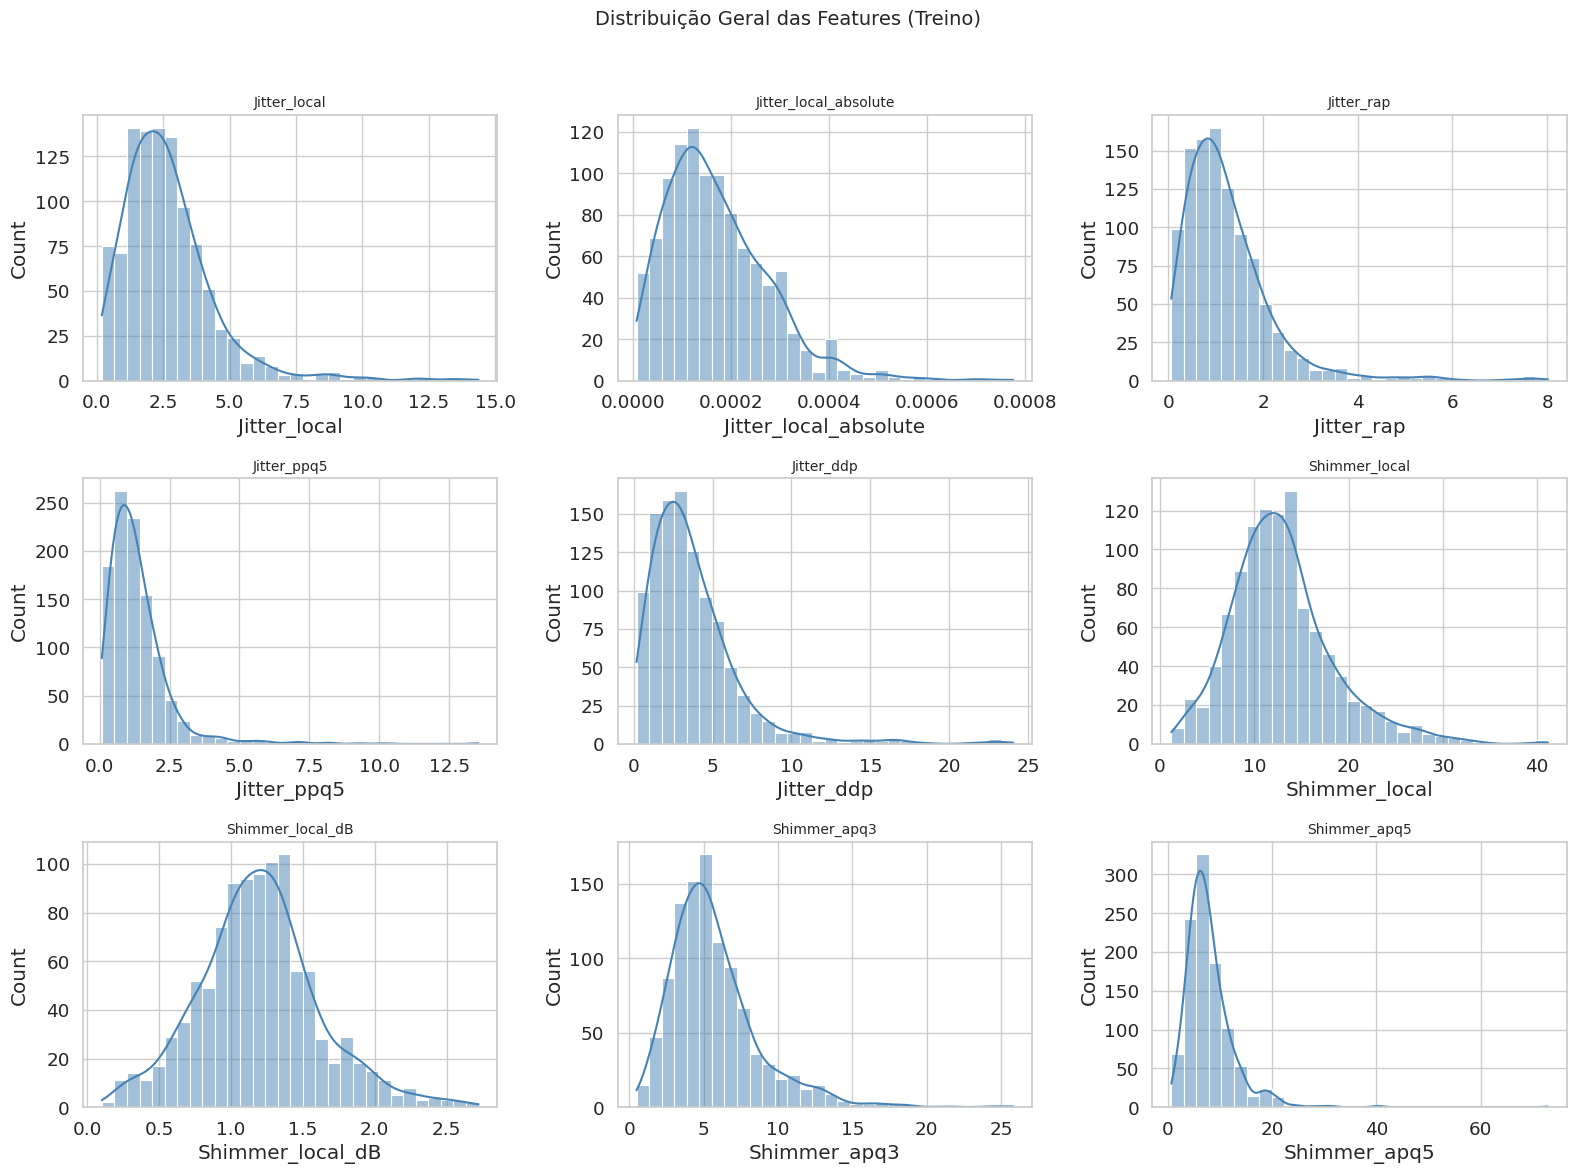

In [ ]:
# ============================================================
# 📊 DISTRIBUIÇÃO DAS FEATURES ACÚSTICAS (GERAL)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Exibir histogramas para as 9 primeiras features
plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_cols[:9]):
    plt.subplot(3, 3, i + 1)
    sns.histplot(train[col], bins=30, color="steelblue", kde=True)
    plt.title(col, fontsize=10)
plt.suptitle("Distribuição Geral das Features (Treino)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

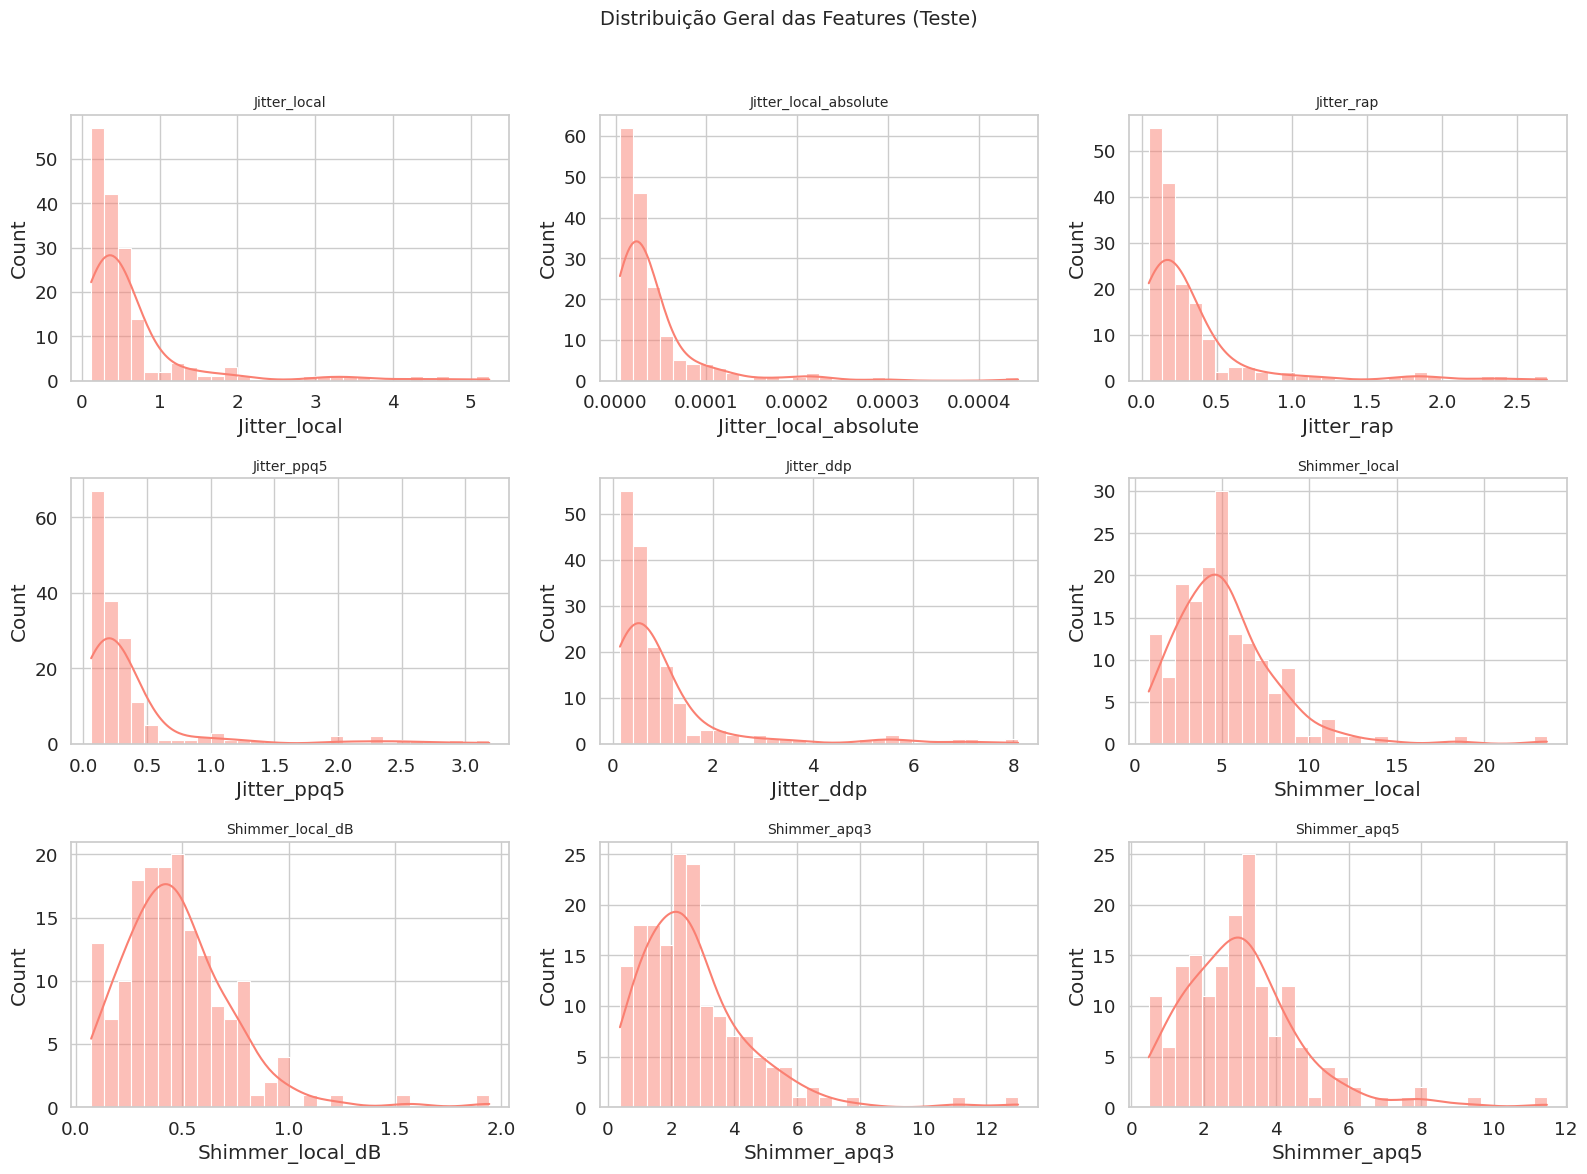

In [ ]:
# Mesmo gráfico para o conjunto de teste
plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_cols[:9]):
    plt.subplot(3, 3, i + 1)
    sns.histplot(test[col], bins=30, color="salmon", kde=True)
    plt.title(col, fontsize=10)
plt.suptitle("Distribuição Geral das Features (Teste)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

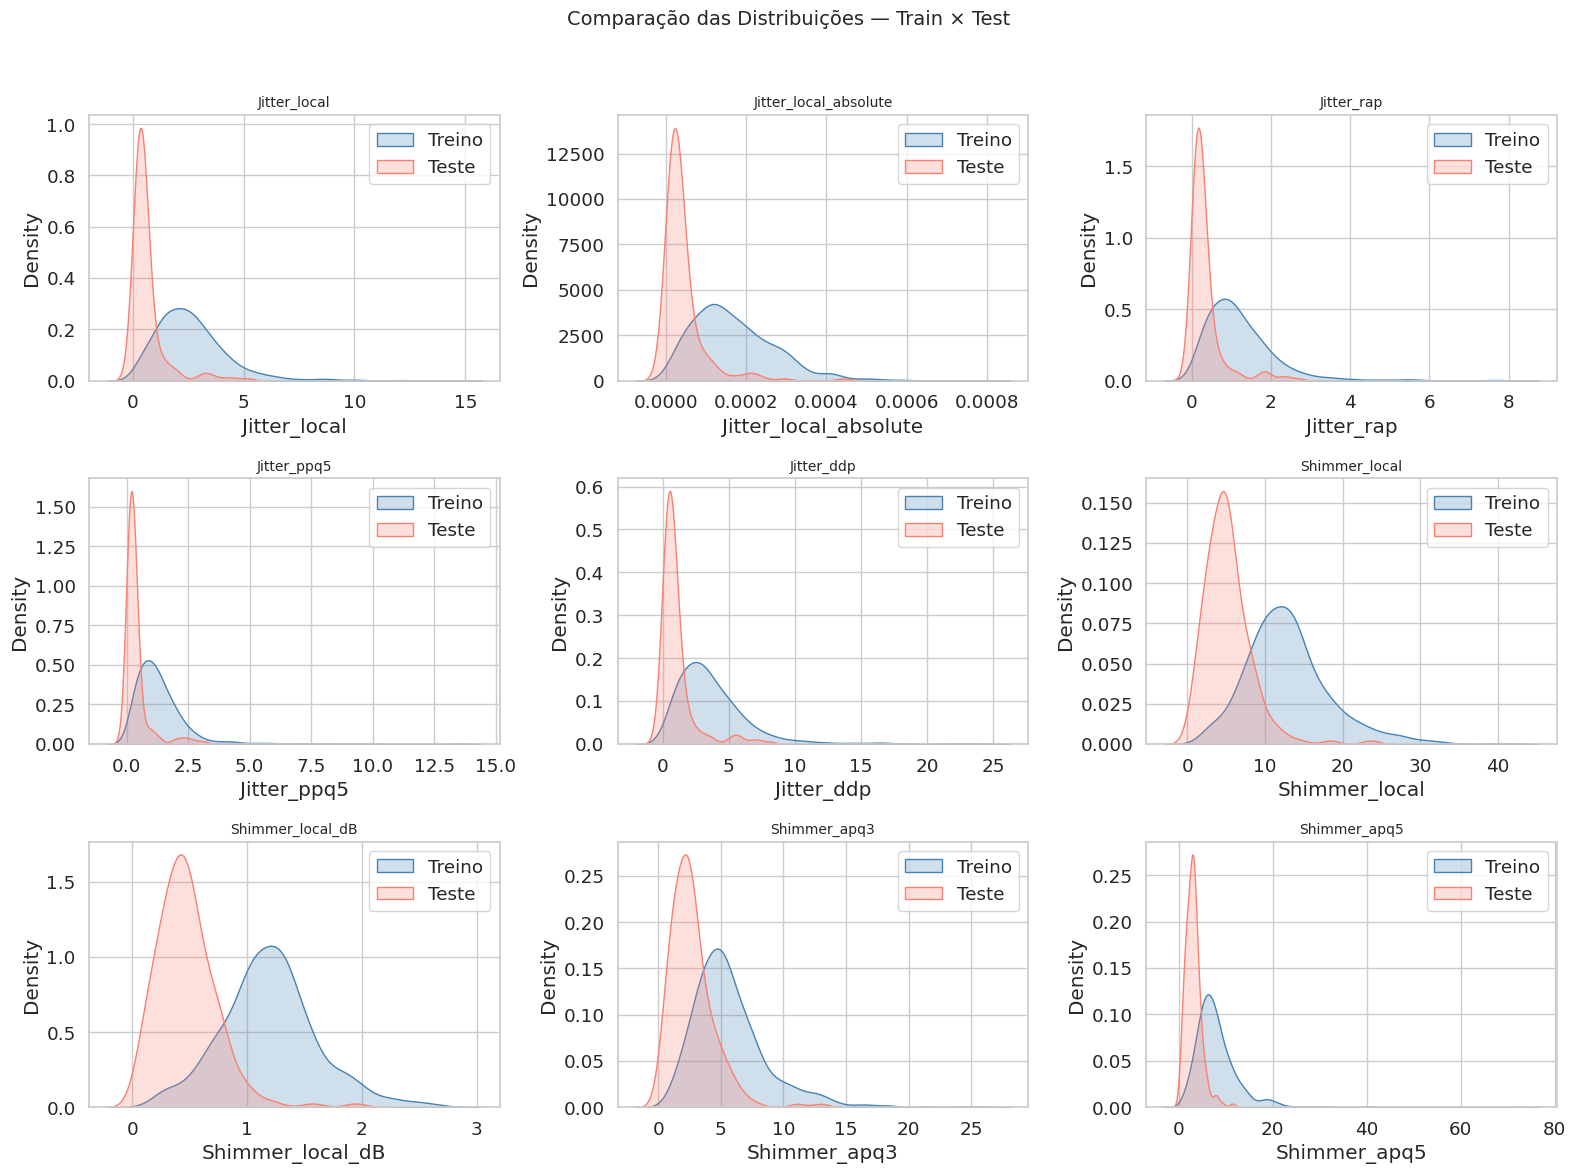

In [ ]:
# ============================================================
# ⚖️ COMPARAÇÃO DAS DISTRIBUIÇÕES ENTRE TRAIN × TEST
# ============================================================

plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_cols[:9]):
    plt.subplot(3, 3, i + 1)
    sns.kdeplot(train[col], label="Treino", color="steelblue", shade=True)
    sns.kdeplot(test[col], label="Teste", color="salmon", shade=True)
    plt.title(col, fontsize=10)
    plt.legend()
plt.suptitle("Comparação das Distribuições — Train × Test", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

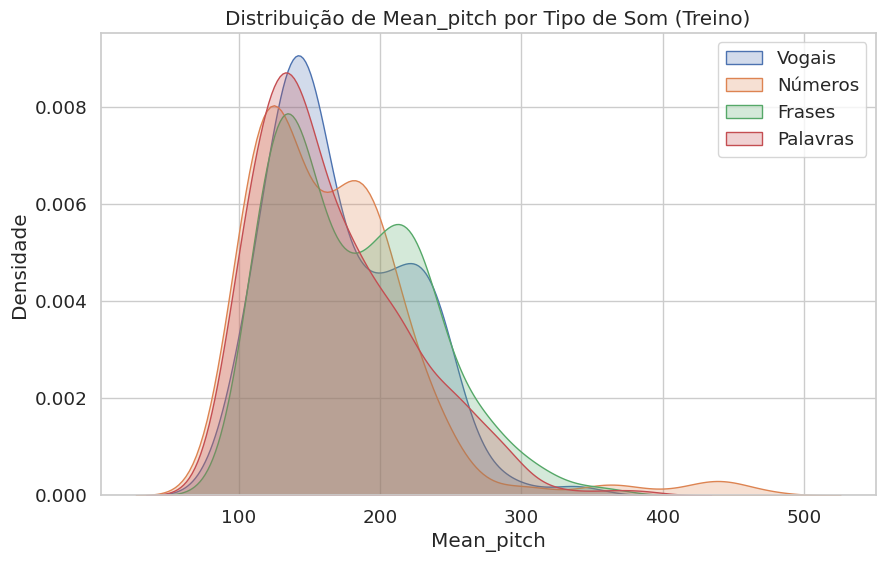

In [ ]:
# ============================================================
# 🔠 DISTRIBUIÇÕES POR TIPO DE SOM (TREINO)
# ============================================================

categorias = {
    "Vogais": vogais_train,
    "Números": numeros_train,
    "Frases": frases_train,
    "Palavras": palavras_train
}

# Plotar histogramas da mesma feature (exemplo: Mean_pitch) por categoria
feature_exemplo = "Mean_pitch"

plt.figure(figsize=(10,6))
for nome, df in categorias.items():
    sns.kdeplot(df[feature_exemplo], label=nome, shade=True)
plt.title(f"Distribuição de {feature_exemplo} por Tipo de Som (Treino)")
plt.xlabel(feature_exemplo)
plt.ylabel("Densidade")
plt.legend()
plt.show()

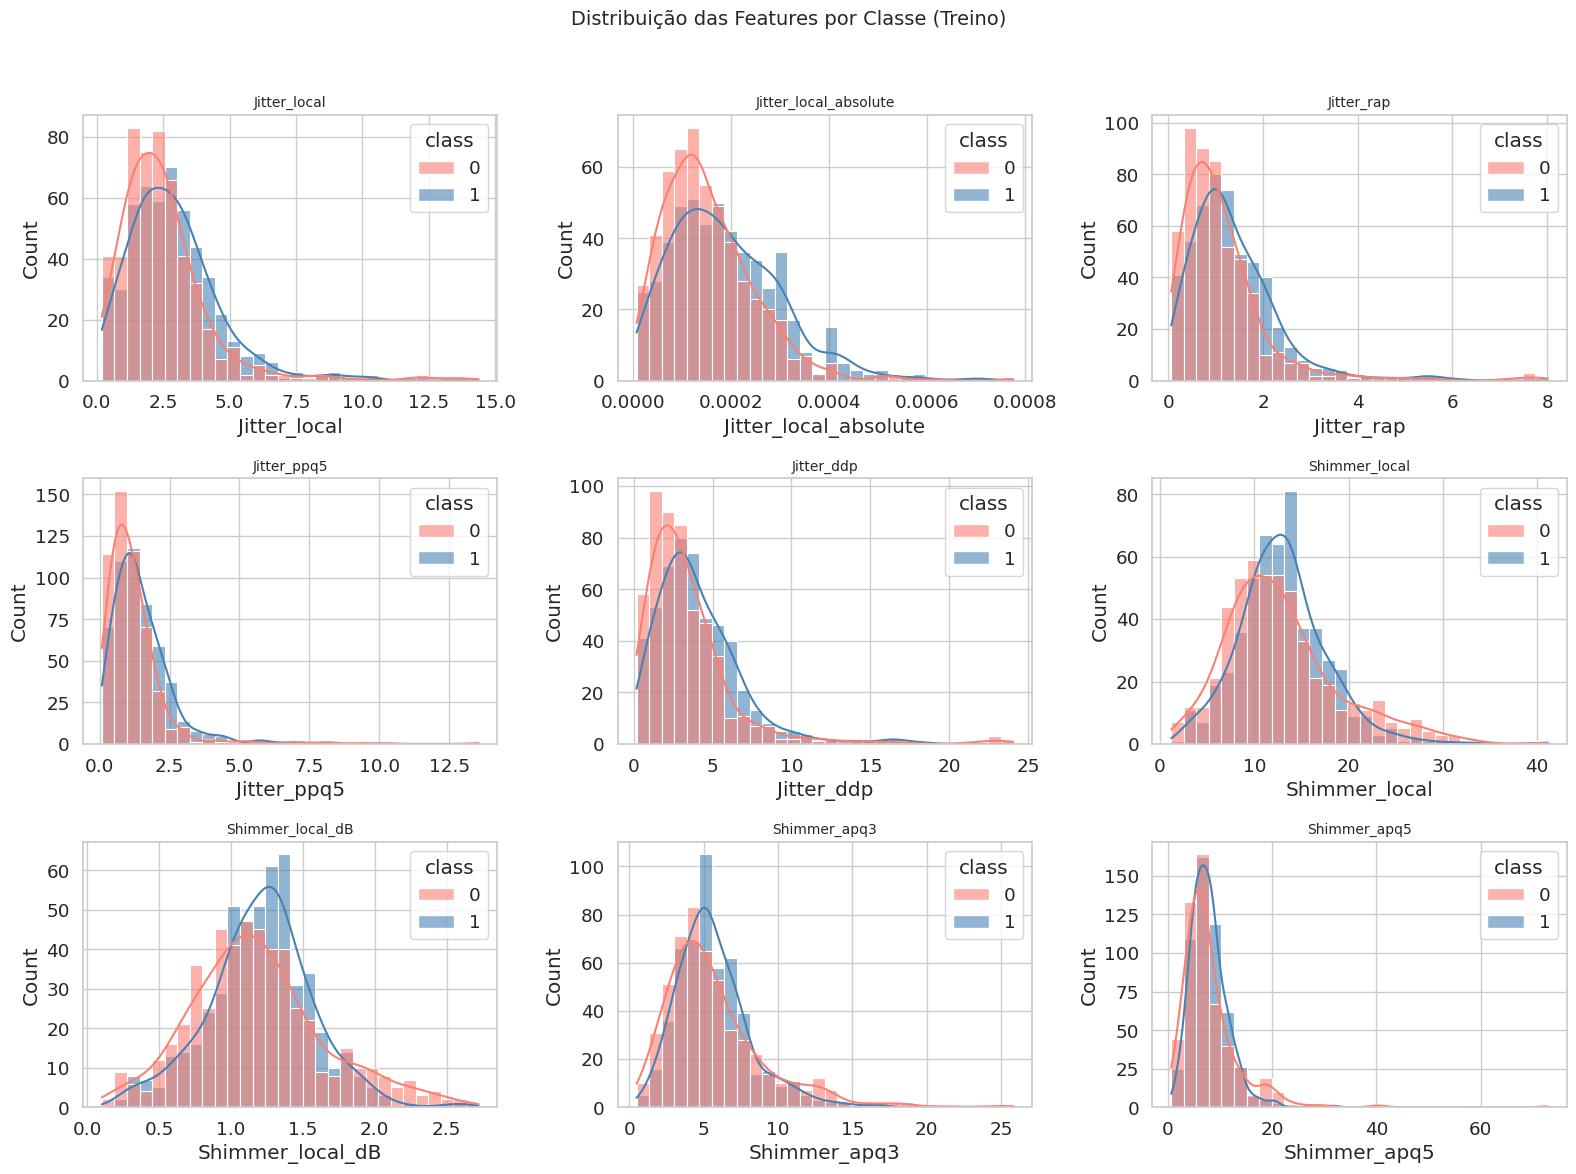

In [ ]:
# ============================================================
# 🧠 DISTRIBUIÇÃO POR CLASSE (PARKINSON VS CONTROLE)
# ============================================================

plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_cols[:9]):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=train, x=col, hue="class", bins=30, kde=True, palette=["salmon", "steelblue"], alpha=0.6)
    plt.title(col, fontsize=10)
plt.suptitle("Distribuição das Features por Classe (Treino)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

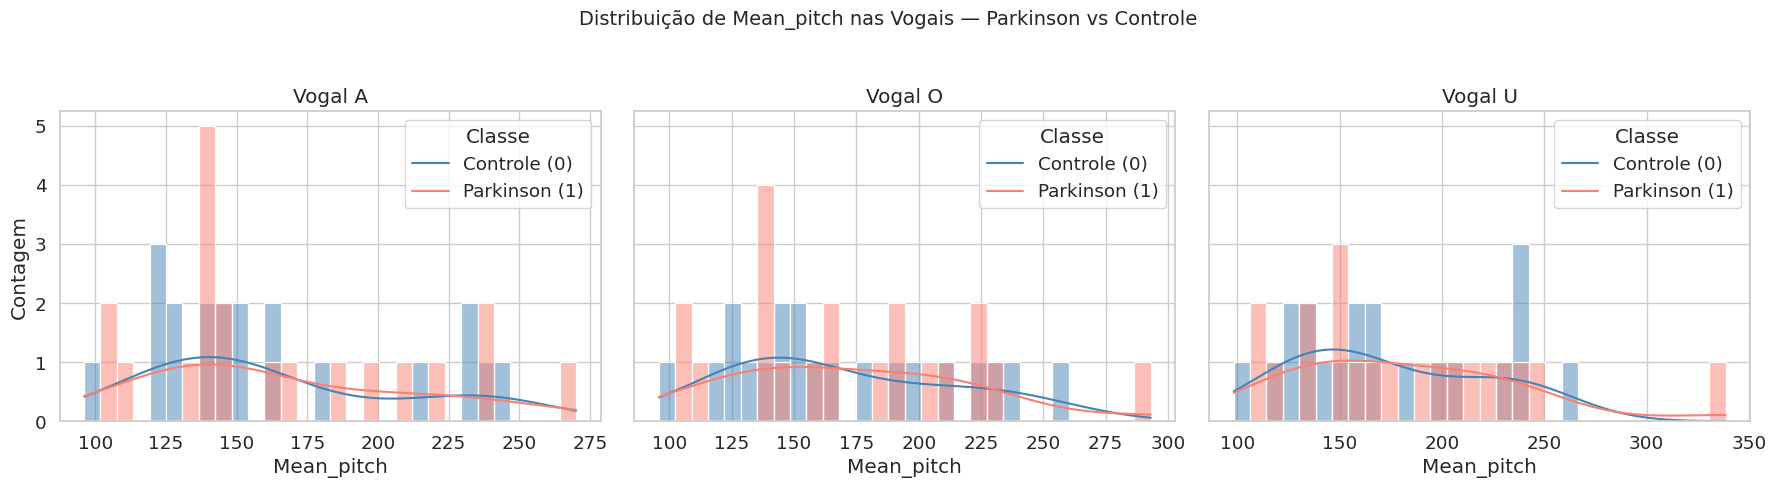

In [ ]:
# ============================================================
# 🔤 ANÁLISE ESPECÍFICA — VOGAIS (A, O, U)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Dicionário das vogais e datasets correspondentes
vogais_dict = {
    "Vogal A": vogal_a_train,
    "Vogal O": vogal_o_train,
    "Vogal U": vogal_u_train
}

# Feature alvo principal
feature_vogal = "Mean_pitch"

# Criar subplots separados para cada vogal
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (nome, df) in zip(axes, vogais_dict.items()):
    sns.histplot(
        data=df,
        x=feature_vogal,
        hue="class",
        bins=30,
        kde=True,
        alpha=0.5,
        palette=["salmon", "steelblue"],
        ax=ax
    )
    ax.set_title(nome)
    ax.set_xlabel("Mean_pitch")
    ax.set_ylabel("Contagem" if nome == "Vogal A" else "")
    ax.legend(title="Classe", labels=["Controle (0)", "Parkinson (1)"])

plt.suptitle("Distribuição de Mean_pitch nas Vogais — Parkinson vs Controle", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



6. Matriz de Correlação — Features Acústicas


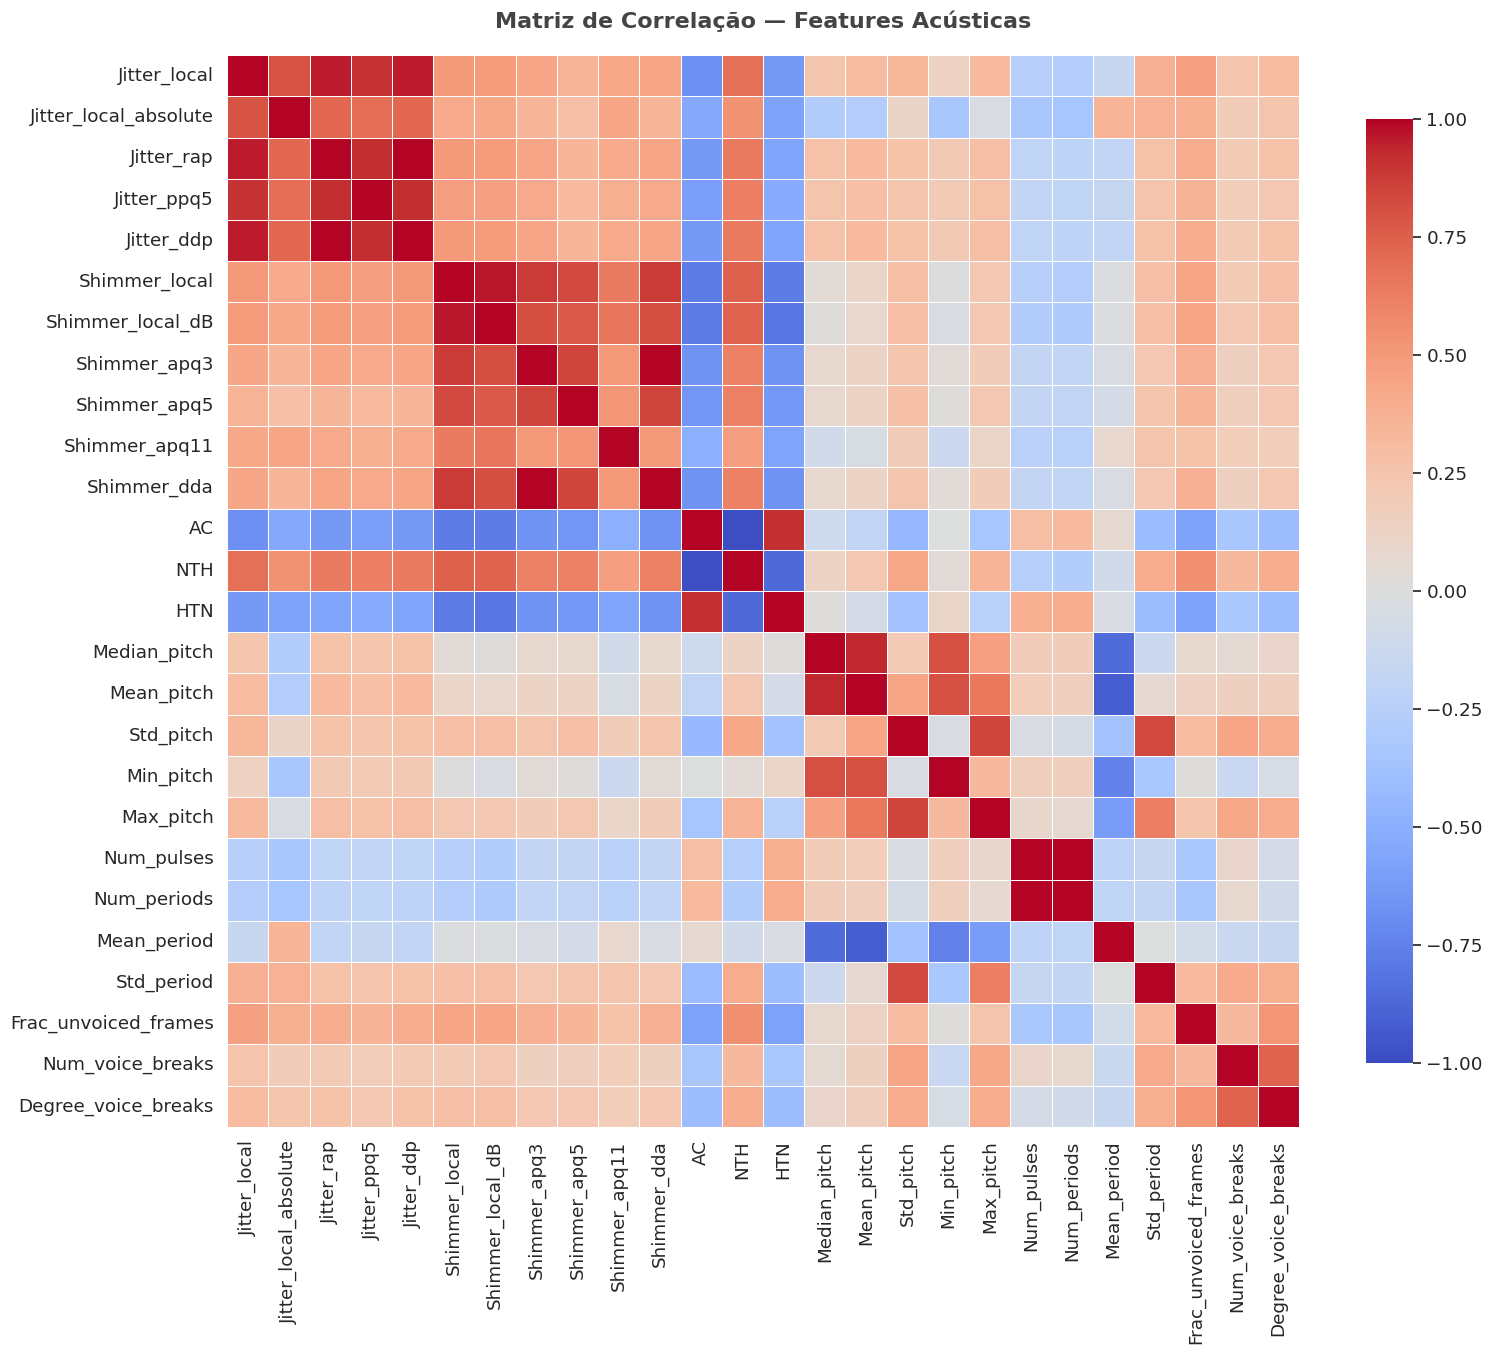


Correlação de cada feature com a classe (Parkinson):
Jitter_local_absolute    0.166999
Shimmer_apq11            0.146326
Jitter_rap               0.111144
Jitter_ddp               0.111138
Jitter_ppq5              0.110934
Jitter_local             0.097552
Mean_period              0.081763
AC                       0.081095
Num_periods              0.047103
Num_pulses               0.041038
HTN                      0.040507
Shimmer_local_dB         0.027190
Shimmer_local            0.009062
Shimmer_apq3            -0.018156
Shimmer_dda             -0.018158
Shimmer_apq5            -0.022581
Std_period              -0.058788
Min_pitch               -0.059104
NTH                     -0.076077
Num_voice_breaks        -0.079831
Median_pitch            -0.084222
Mean_pitch              -0.103270
Std_pitch               -0.121074
Frac_unvoiced_frames    -0.122044
Degree_voice_breaks     -0.126151
Max_pitch               -0.139398
Name: class, dtype: float64


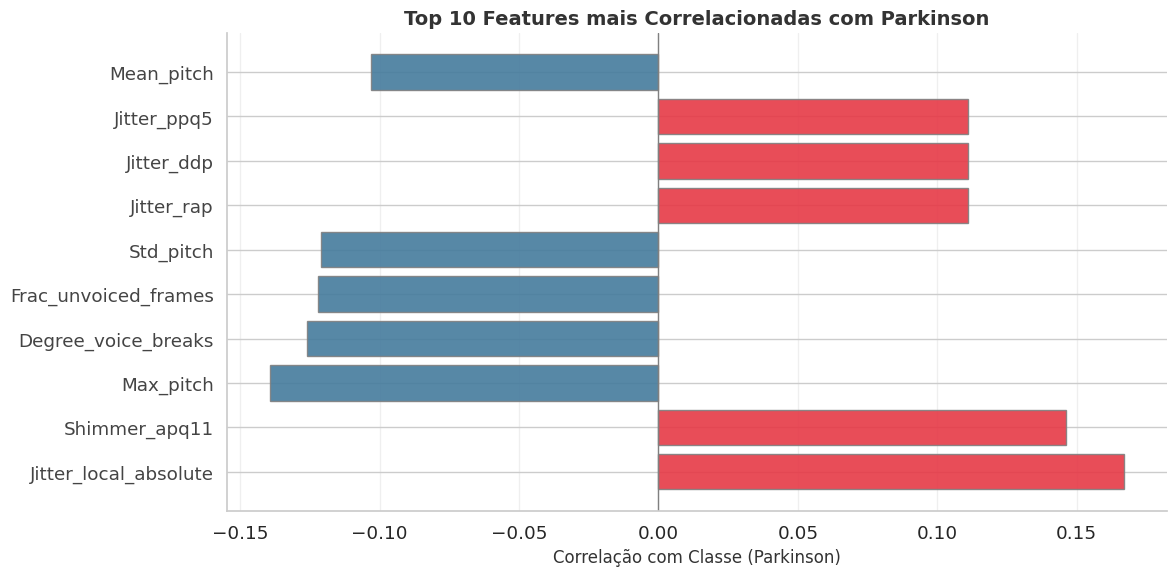

In [ ]:
# ============================================================
# 6️⃣ MATRIZ DE CORRELAÇÃO — FEATURES ACÚSTICAS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("\n6. Matriz de Correlação — Features Acústicas")

# Calcular matriz de correlação entre as features
correlation_matrix = train[feature_names].corr()

# Plotar heatmap da correlação
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)
plt.title(
    'Matriz de Correlação — Features Acústicas',
    fontsize=16,
    fontweight='bold',
    pad=20,
    color='#444'
)
plt.tight_layout()
plt.show()

# ============================================================
# 🔗 Correlação de cada feature com a classe (Parkinson)
# ============================================================

print("\nCorrelação de cada feature com a classe (Parkinson):")

correlation_with_class = (
    train[feature_names + ['class']]
    .corr()['class']
    .drop('class')
    .sort_values(ascending=False)
)

print(correlation_with_class)

# ============================================================
# 🎯 Top 10 features mais correlacionadas com a classe
# ============================================================

plt.figure(figsize=(12, 6))

# Selecionar as 10 mais correlacionadas (em valor absoluto)
top_10 = correlation_with_class.abs().sort_values(ascending=False).head(10)

# Cores personalizadas (opcional)
COLOR_PD = "#E63946"       # vermelho Parkinson
COLOR_HEALTHY = "#457B9D"  # azul saudável
colors_corr = [
    COLOR_PD if correlation_with_class[feature] > 0 else COLOR_HEALTHY
    for feature in top_10.index
]

# Plotar gráfico de barras horizontal
plt.barh(
    range(len(top_10)),
    correlation_with_class[top_10.index].values,
    color=colors_corr,
    edgecolor='gray',
    alpha=0.9
)
plt.yticks(range(len(top_10)), top_10.index, color='#444')
plt.xlabel('Correlação com Classe (Parkinson)', fontsize=12, color='#333')
plt.title(
    'Top 10 Features mais Correlacionadas com Parkinson',
    fontsize=14,
    fontweight='bold',
    color='#333'
)
plt.axvline(x=0, color='gray', linewidth=1)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

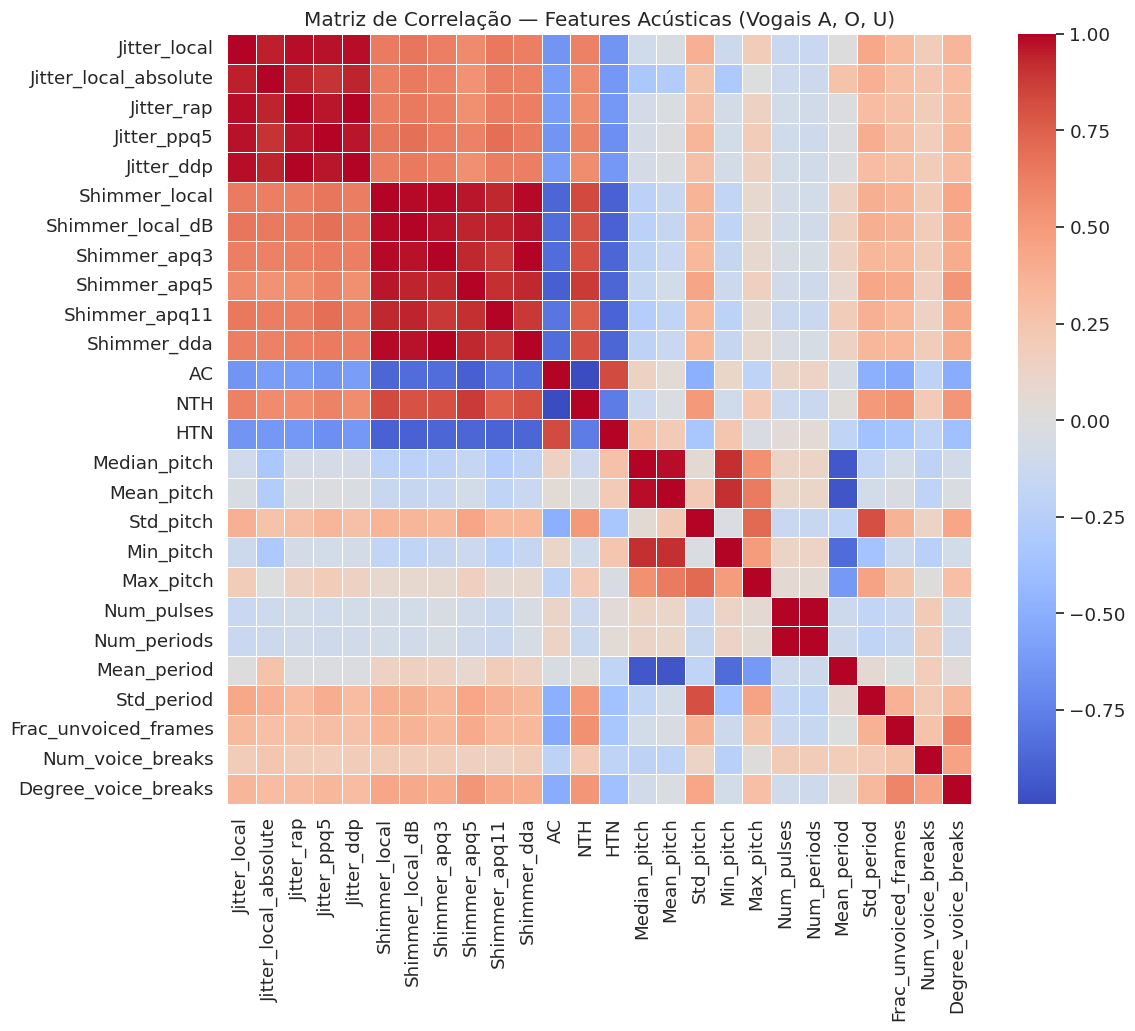

In [ ]:
# ============================================================
# 🔗 MATRIZ DE CORRELAÇÃO — FEATURES ACÚSTICAS (APENAS VOGAIS)
# ============================================================

# Combinar todas as vogais em um único DataFrame
vogais_comb = pd.concat([vogal_a_train, vogal_o_train, vogal_u_train], axis=0)

# Selecionar apenas as features acústicas
feature_cols_vogais = [
    col for col in vogais_comb.columns
    if col not in ["subject_id", "sample_number", "sample_type", "class"]
]

# Calcular correlação
corr_vogais = vogais_comb[feature_cols_vogais].corr()

# Plotar heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_vogais, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de Correlação — Features Acústicas (Vogais A, O, U)")
plt.show()

# 3) Análise de Distribuição Demográfica e Clínica

In [ ]:
# ============================================================
# 🧍‍♂️ Análise Demográfica e Clínica da Base
# (nível de paciente e nível de gravação)
# ============================================================

import pandas as pd

print("\n" + "="*70)
print("🧍‍♂️ 1. Construindo visão por PACIENTE (agregando por subject_id)")
print("="*70)

# Função auxiliar para gerar visão por paciente
def resumo_por_paciente(df, origem_label):
    """
    df: train ou test já padronizado (subject_id, class, sample_type, sample_number, etc.)
    origem_label: string só para identificação depois ("train" ou "test")
    """
    # total de gravações por paciente
    gravações_por_paciente = (
        df.groupby('subject_id')
          .agg(
              classe=('class', 'first'),  # rótulo clínico do paciente
              n_amostras=('sample_number', 'count')
          )
          .reset_index()
    )

    # quais tipos de amostra de voz cada paciente gravou
    cobertura_tipo_voz = (
        df.groupby(['subject_id', 'sample_type'])
          .size()
          .unstack(fill_value=0)
    )
    cobertura_tipo_voz = (cobertura_tipo_voz > 0).astype(int)  # 1 = gravou pelo menos uma vez

    # junta tudo
    resumo = gravações_por_paciente.merge(
        cobertura_tipo_voz,
        left_on='subject_id',
        right_index=True,
        how='left'
    )

    resumo['origem'] = origem_label
    return resumo

subject_level_train = resumo_por_paciente(train, "train")
subject_level_test  = resumo_por_paciente(test,  "test")

print("\n✅ Visão por paciente criada!")
print("subject_level_train (amostra):")
display(subject_level_train.head())

print("subject_level_test (amostra):")
display(subject_level_test.head())




🧍‍♂️ 1. Construindo visão por PACIENTE (agregando por subject_id)

✅ Visão por paciente criada!
subject_level_train (amostra):


,subject_id,classe,n_amostras,Number_1,Number_10,Number_2,Number_3,Number_4,Number_5,Number_6,Number_7,Number_8,Number_9,Sentence_1,Sentence_2,Sentence_3,Sentence_4,Vowel_A,Vowel_O,Vowel_U,Word_1,Word_2,Word_3,Word_4,Word_5,Word_6,Word_7,Word_8,Word_9,origem
0,1,1,26,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,train
1,2,1,26,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,train
2,3,1,26,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,train
3,4,1,26,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,train
4,5,1,26,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,train


subject_level_test (amostra):


,subject_id,classe,n_amostras,Vowel_A_1,Vowel_A_2,Vowel_A_3,Vowel_O_1,Vowel_O_2,Vowel_O_3,origem
0,1,1,6,1,1,1,1,1,1,test
1,2,1,6,1,1,1,1,1,1,test
2,3,1,6,1,1,1,1,1,1,test
3,4,1,6,1,1,1,1,1,1,test
4,5,1,6,1,1,1,1,1,1,test


In [ ]:
# ============================================================
# 📊 2. Quantos pacientes temos em cada grupo clínico?
# ============================================================

print("\n" + "="*70)
print("📊 2. Distribuição clínica (Parkinson vs Saudável)")
print("="*70)

# Classe: 1 = Parkinson, 0 = Saudável
dist_pacientes_train = (
    subject_level_train['classe']
    .value_counts()
    .rename(index={0: 'Saudável (0)', 1: 'Parkinson (1)'})
)
dist_pacientes_test = (
    subject_level_test['classe']
    .value_counts()
    .rename(index={0: 'Saudável (0)', 1: 'Parkinson (1)'})
)

print("\n👥 Pacientes por classe (TRAIN):")
print(dist_pacientes_train)

print("\n👥 Pacientes por classe (TEST):")
print(dist_pacientes_test)

# Também mostrar proporção
print("\n📈 Proporção de pacientes por classe (TRAIN):")
print((subject_level_train['classe'].value_counts(normalize=True) * 100).round(2)
      .rename(index={0: 'Saudável (%)', 1: 'Parkinson (%)'}))

print("\n📈 Proporção de pacientes por classe (TEST):")
print((subject_level_test['classe'].value_counts(normalize=True) * 100).round(2)
      .rename(index={0: 'Saudável (%)', 1: 'Parkinson (%)'}))


📊 2. Distribuição clínica (Parkinson vs Saudável)

👥 Pacientes por classe (TRAIN):
classe
Parkinson (1)    20
Saudável (0)     20
Name: count, dtype: int64

👥 Pacientes por classe (TEST):
classe
Parkinson (1)    28
Name: count, dtype: int64

📈 Proporção de pacientes por classe (TRAIN):
classe
Parkinson (%)    50.0
Saudável (%)     50.0
Name: proportion, dtype: float64

📈 Proporção de pacientes por classe (TEST):
classe
Parkinson (%)    100.0
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 🎙️ 3. Quantidade de gravações por classe
# (isso mostra se há viés de coleta entre os grupos)
# ============================================================

print("\n" + "="*70)
print("🎙️ 3. Carga de dados de voz por classe")
print("="*70)

gravações_por_classe_train = (
    train['class']
    .value_counts()
    .rename(index={0: 'Saudável (0)', 1: 'Parkinson (1)'})
)

gravações_por_classe_test = (
    test['class']
    .value_counts()
    .rename(index={0: 'Saudável (0)', 1: 'Parkinson (1)'})
)

print("\n🎤 Gravações totais por classe (TRAIN):")
print(gravações_por_classe_train)

print("\n🎤 Gravações totais por classe (TEST):")
print(gravações_por_classe_test)

# média de gravações por paciente em cada classe
media_gravacoes_por_paciente = (
    subject_level_train
    .groupby('classe')['n_amostras']
    .mean()
    .rename({0: 'Saudável (0)', 1: 'Parkinson (1)'})
    .round(2)
)

print("\n📊 Média de gravações por paciente (TRAIN):")
print(media_gravacoes_por_paciente)


🎙️ 3. Carga de dados de voz por classe

🎤 Gravações totais por classe (TRAIN):
class
Parkinson (1)    520
Saudável (0)     520
Name: count, dtype: int64

🎤 Gravações totais por classe (TEST):
class
Parkinson (1)    168
Name: count, dtype: int64

📊 Média de gravações por paciente (TRAIN):
classe
Saudável (0)     26.0
Parkinson (1)    26.0
Name: n_amostras, dtype: float64


In [ ]:
# ============================================================
# 🗣️ 4. Cobertura de protocolo de fala
# (quem falou vogal, número, frase, palavra etc.)
# ============================================================

print("\n" + "="*70)
print("🗣️ 4. Cobertura de tipos de fala por paciente")
print("="*70)

# Para cada sujeito: quantos tipos diferentes de amostras ele forneceu
tipos_distintos_train = (
    train.groupby('subject_id')['sample_type']
         .nunique()
         .rename('n_tipos_de_fala')
)

tmp = subject_level_train.merge(
    tipos_distintos_train,
    on='subject_id',
    how='left'
)

print("\n🔎 Amostra da cobertura de fala (TRAIN):")
display(tmp[['subject_id', 'classe', 'n_amostras', 'n_tipos_de_fala']].head())

print("\n📌 Estatísticas globais de cobertura de fala (TRAIN):")
print(tmp[['n_amostras', 'n_tipos_de_fala']].describe().round(2))

# cobertura média de fala por classe clínica
cobertura_por_classe = (
    tmp.groupby('classe')[['n_amostras', 'n_tipos_de_fala']]
       .mean()
       .rename(index={0: 'Saudável (0)', 1: 'Parkinson (1)'})
       .round(2)
)

print("\n📌 Cobertura média por classe clínica (TRAIN):")
print(cobertura_por_classe)



🗣️ 4. Cobertura de tipos de fala por paciente

🔎 Amostra da cobertura de fala (TRAIN):


,subject_id,classe,n_amostras,n_tipos_de_fala
0,1,1,26,26
1,2,1,26,26
2,3,1,26,26
3,4,1,26,26
4,5,1,26,26



📌 Estatísticas globais de cobertura de fala (TRAIN):
       n_amostras  n_tipos_de_fala
count        40.0             40.0
mean         26.0             26.0
std           0.0              0.0
min          26.0             26.0
25%          26.0             26.0
50%          26.0             26.0
75%          26.0             26.0
max          26.0             26.0

📌 Cobertura média por classe clínica (TRAIN):
               n_amostras  n_tipos_de_fala
classe                                    
Saudável (0)         26.0             26.0
Parkinson (1)        26.0             26.0


### **Distribuição de Gênero**
Observa-se uma distribuição levemente desbalanceada entre os gêneros na base de treinamento, com predominância masculina (60%) em relação ao público feminino (40%).
Esse padrão reflete a composição original da amostra descrita por Sakar et al. (2013), na qual o grupo de pacientes com Parkinson é majoritariamente composto por homens (14 de 20), enquanto o grupo controle apresenta distribuição equilibrada entre homens e mulheres (10 de cada).
O conjunto de teste não possui informações demográficas de gênero divulgadas.

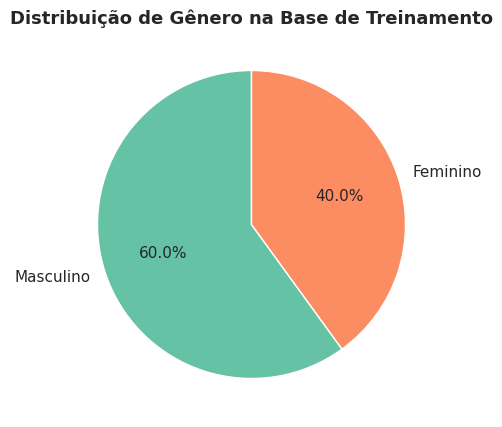

In [ ]:
# ============================================================
# 👩‍🦰👨‍🦱 Distribuição de Gênero (baseado na descrição do dataset)
# ============================================================

import matplotlib.pyplot as plt

# Proporções segundo o artigo (Sakar et al., 2013)
genero_labels = ['Masculino', 'Feminino']
genero_values = [24, 16]  # 14+10 homens, 6+10 mulheres = 24 e 16
genero_colors = ['#66c2a5', '#fc8d62']  # Paleta Set2 (mesma dos outros gráficos)

# Criação do gráfico
plt.figure(figsize=(5, 5))
plt.pie(
    genero_values,
    labels=genero_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=genero_colors,
    textprops={'fontsize': 11}
)
plt.title('Distribuição de Gênero na Base de Treinamento', fontsize=13, weight='bold')
plt.show()


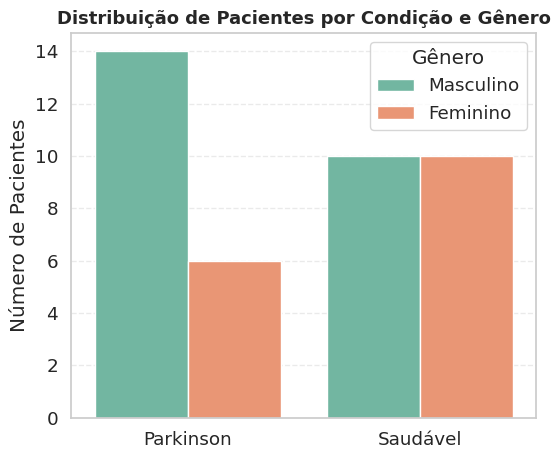

In [ ]:
# ============================================================
# 🧍‍♂️🧍‍♀️ Distribuição de Pacientes por Condição e Gênero
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estrutura dos dados conforme artigo
dados_genero_condicao = pd.DataFrame({
    'Condição': ['Parkinson', 'Parkinson', 'Saudável', 'Saudável'],
    'Gênero': ['Masculino', 'Feminino', 'Masculino', 'Feminino'],
    'Pacientes': [14, 6, 10, 10]
})

# Gráfico de barras agrupadas
plt.figure(figsize=(6,5))
sns.barplot(
    data=dados_genero_condicao,
    x='Condição',
    y='Pacientes',
    hue='Gênero',
    palette=['#66c2a5', '#fc8d62']  # Paleta Set2 (mesma usada nos outros gráficos)
)

plt.title('Distribuição de Pacientes por Condição e Gênero', fontsize=13, weight='bold')
plt.ylabel('Número de Pacientes')
plt.xlabel('')
plt.legend(title='Gênero')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


# 4) Análise Acústica Específica (Vogais e Sons)

Comparação PD x CO para cada feature

In [ ]:
# ============================================================
# ⚠️ ATENÇÃO: Esta seção contém código antigo com problemas.
# Os resultados CORRETOS estão na Seção 7 (Experimentação com Classificadores).
# Mantido apenas para referência histórica.
# ============================================================

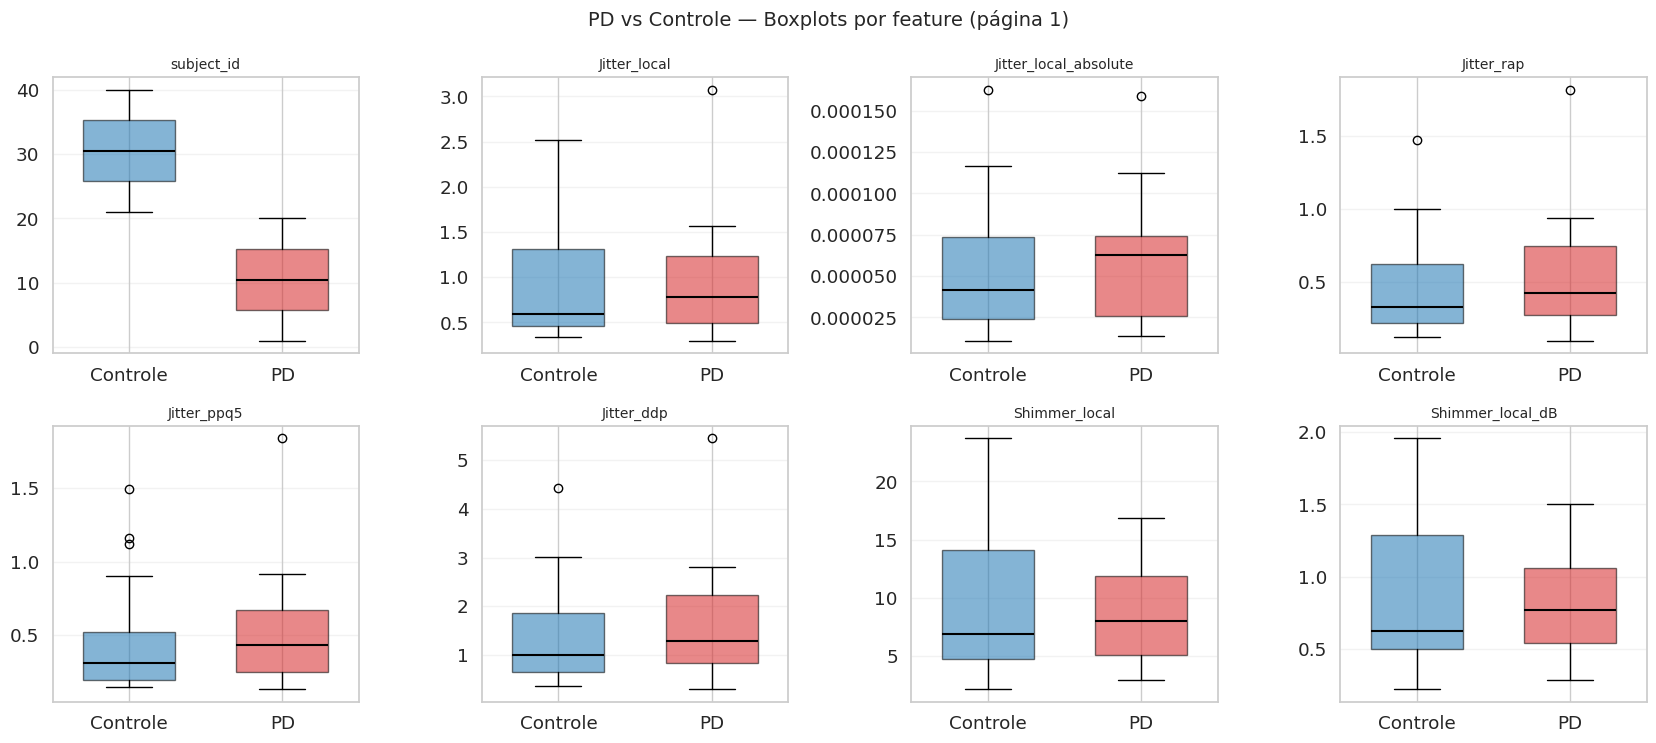

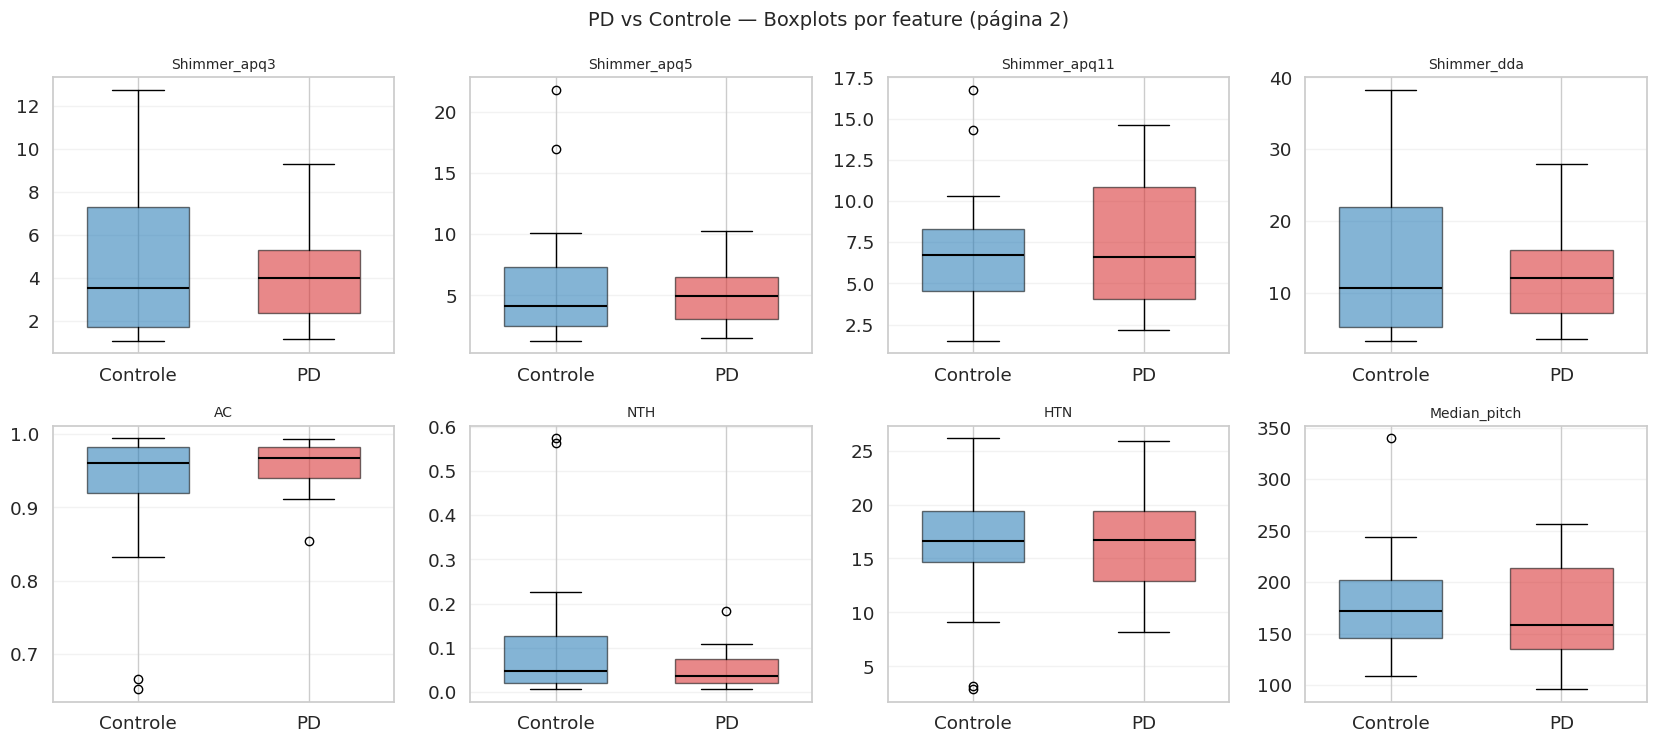

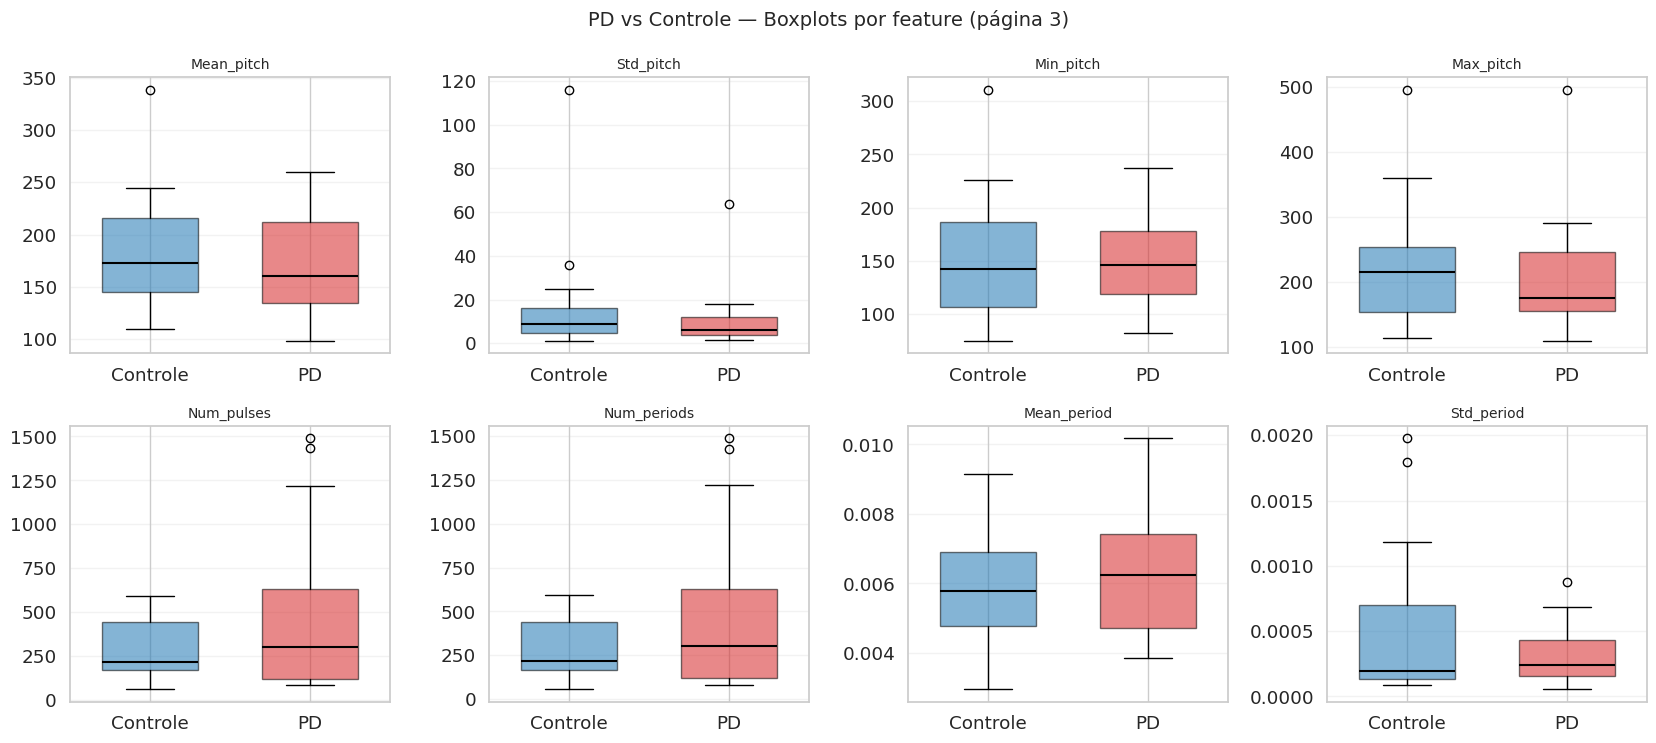

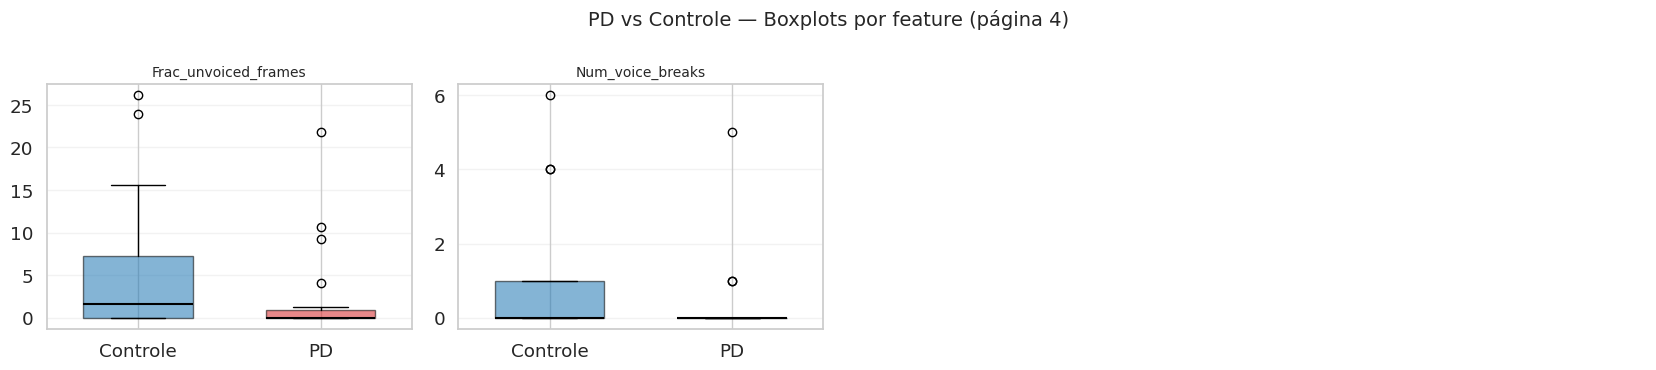

In [ ]:
# ==== PD vs Controle: Boxplots por feature ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Configurações de estilo/cores
# -----------------------------
COLOR_PD   = "#d62728"
COLOR_CTRL = "#1f77b4"
BOXPROPS_W = 0.6
FEATURES_N_PER_PAGE = 8

# -----------------------------
# Detecta coluna de classe e features
# -----------------------------
if 'class' in df.columns:
    classe_col = 'class'
elif 'class information' in df.columns:
    classe_col = 'class information'
else:
    raise ValueError("Não encontrei coluna de classe. Esperado: 'class' ou 'class information'.")

to_exclude = {
    classe_col,
    'class', 'class information',
    'UPDRS', 'UPDRS score',
    'Subject id', 'subject id', 'subject', 'id'
}

candidate_features = [c for c in df.columns
                      if c not in to_exclude and pd.api.types.is_numeric_dtype(df[c])]

FEATURES = candidate_features[:26] if len(candidate_features) >= 26 else candidate_features

# -----------------------------
# Função de plot por página
# -----------------------------
def plot_boxpage(features_subset, page_idx=1):
    n = len(features_subset)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.2*ncols, 3.8*nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    for i, feat in enumerate(features_subset):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        pd_vals = df.loc[df[classe_col] == 1, feat].dropna().values
        ct_vals = df.loc[df[classe_col] == 0, feat].dropna().values

        bp = ax.boxplot(
            [ct_vals, pd_vals],
            widths=BOXPROPS_W,
            patch_artist=True,
            showfliers=True,
            tick_labels=['Controle', 'PD']  # <- nome atualizado
        )

        for patch, color in zip(bp['boxes'], [COLOR_CTRL, COLOR_PD]):
            patch.set_facecolor(color)
            patch.set_alpha(0.55)
        for median in bp['medians']:
            median.set_color('black')
            median.set_linewidth(1.5)

        ax.set_title(feat, fontsize=10)
        ax.grid(True, axis='y', alpha=0.25)

    total_axes = nrows * ncols
    for k in range(n, total_axes):
        r, c = divmod(k, ncols)
        axes[r, c].axis('off')

    fig.suptitle(f"PD vs Controle — Boxplots por feature (página {page_idx})", fontsize=14)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Paginação e plot
# -----------------------------
pages = [FEATURES[i:i+FEATURES_N_PER_PAGE] for i in range(0, len(FEATURES), FEATURES_N_PER_PAGE)]
for p_idx, feats in enumerate(pages, start=1):
    plot_boxpage(feats, page_idx=p_idx)


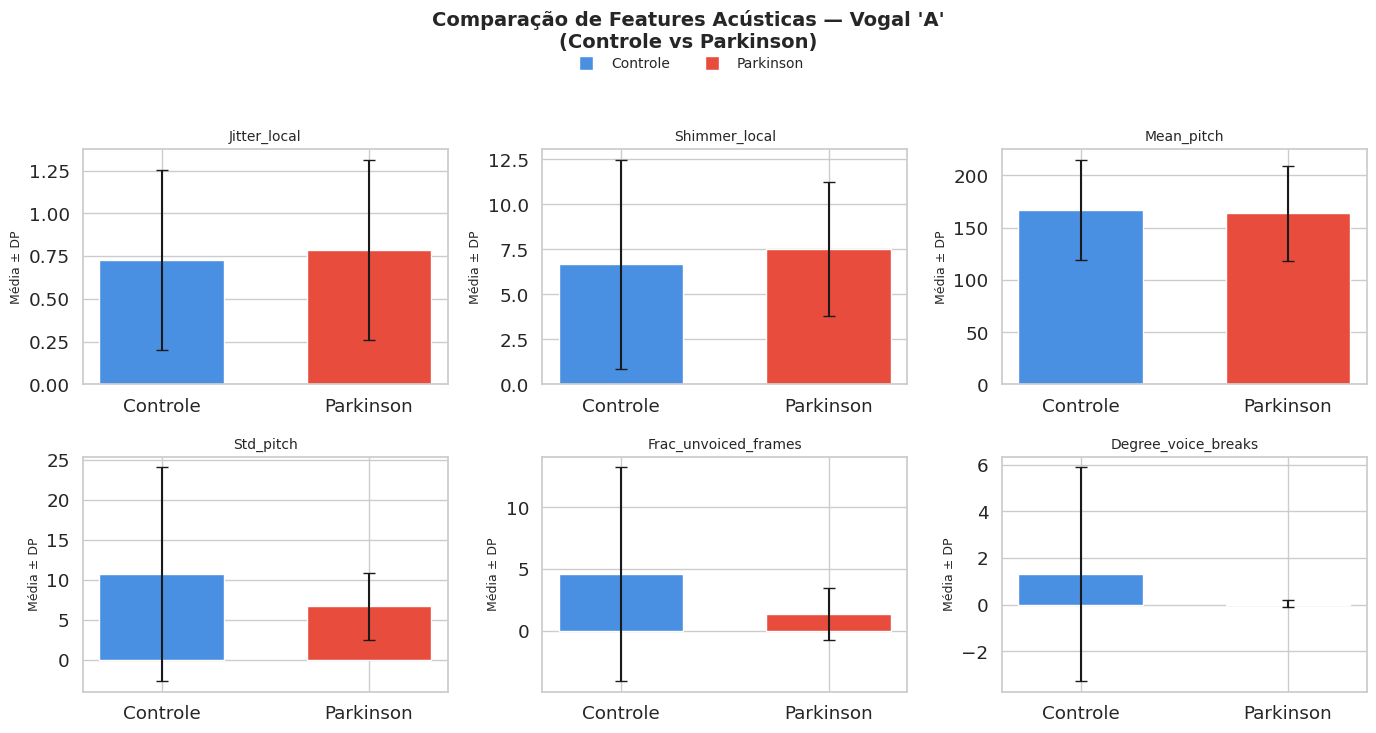

In [ ]:
# ============================================================
# 🎤 Comparação PD vs Controle — Vogal "A"
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar apenas as amostras da vogal "A"
vowel_a = train[train['sample_type'] == 'Vowel_A'].copy()

# Garantir que 'class' seja string e ordenar como 0->1
vowel_a['class'] = vowel_a['class'].astype(str)
class_order = ['0', '1']  # 0=Controle, 1=PD

# Paleta fixa
COLOR_CONTROLE = '#4A90E2'  # azul
COLOR_PD = '#E74C3C'        # vermelho
color_map = {'0': COLOR_CONTROLE, '1': COLOR_PD}

# Features principais
features_vowel = [
    'Jitter_local', 'Shimmer_local',
    'Mean_pitch', 'Std_pitch',
    'Frac_unvoiced_frames', 'Degree_voice_breaks'
]

# Layout
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(features_vowel):
    ax = axes[i]
    # Estatísticas por classe
    stats = (vowel_a.groupby('class')[feat]
             .agg(['mean', 'std'])
             .reindex(class_order))

    means = stats['mean'].values
    stds  = stats['std'].values

    # Barras com erro
    x = np.arange(len(class_order))
    colors = [color_map[c] for c in class_order]
    ax.bar(x, means, yerr=stds, capsize=4, width=0.6, color=colors)

    # Eixos e rótulos
    ax.set_xticks(x)
    ax.set_xticklabels(['Controle', 'Parkinson'])
    ax.set_ylabel('Média ± DP', fontsize=9)
    ax.set_title(feat, fontsize=10)

# Título principal
plt.suptitle("Comparação de Features Acústicas — Vogal 'A'\n(Controle vs Parkinson)",
             fontsize=14, fontweight='bold', y=1.05)

# Legenda abaixo do título (centralizada)
handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=COLOR_CONTROLE, markersize=10, label='Controle'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=COLOR_PD, markersize=10, label='Parkinson'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.00))

# Ajuste de espaçamento para não sobrepor o gráfico
plt.subplots_adjust(top=0.83)
plt.tight_layout()
plt.show()


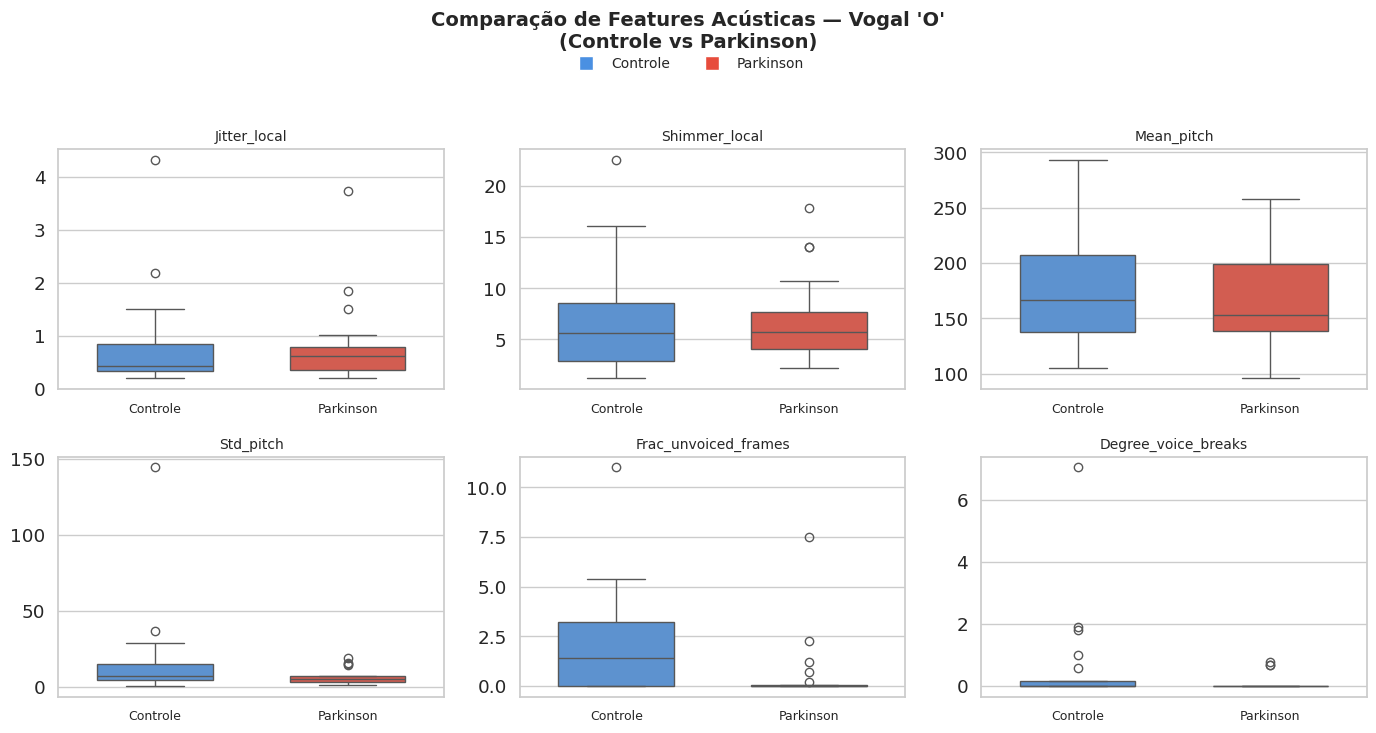

In [ ]:
# ============================================================
# 🎤 Boxplots PD vs Controle — Vogal "O" (sem warnings)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 🔇 Suprimir todos os warnings de bibliotecas
warnings.filterwarnings("ignore")

# 1️⃣ Filtrar apenas as amostras da vogal "O"
vowel_o = train[train['sample_type'] == 'Vowel_O'].copy()
vowel_o['class'] = vowel_o['class'].astype(int)  # garantir que é numérica

# 2️⃣ Cores e ordem das classes
COLOR_CONTROLE = '#4A90E2'  # azul
COLOR_PD       = '#E74C3C'  # vermelho
palette_num    = {0: COLOR_CONTROLE, 1: COLOR_PD}
ordem_classes  = [0, 1]  # 0=Controle, 1=PD

# 3️⃣ Features principais a comparar
features_vowel = [
    'Jitter_local', 'Shimmer_local',
    'Mean_pitch', 'Std_pitch',
    'Frac_unvoiced_frames', 'Degree_voice_breaks'
]

# 4️⃣ Subplots configurados
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(features_vowel):
    ax = axes[i]
    sns.boxplot(
        data=vowel_o,
        x='class', y=feat,
        order=ordem_classes, hue_order=ordem_classes,
        hue='class',
        palette=palette_num,
        dodge=False,
        legend=False,
        ax=ax,
        width=0.6
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Controle', 'Parkinson'], fontsize=9)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# 5️⃣ Título e legenda
plt.suptitle(
    "Comparação de Features Acústicas — Vogal 'O'\n(Controle vs Parkinson)",
    fontsize=14, fontweight='bold', y=1.05
)
handles = [
    plt.Line2D([0], [0], marker='s', color='w',
               markerfacecolor=COLOR_CONTROLE, markersize=10, label='Controle'),
    plt.Line2D([0], [0], marker='s', color='w',
               markerfacecolor=COLOR_PD, markersize=10, label='Parkinson'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False,
           fontsize=10, bbox_to_anchor=(0.5, 1.00))

# 6️⃣ Layout final
plt.subplots_adjust(top=0.83)
plt.tight_layout()
plt.show()


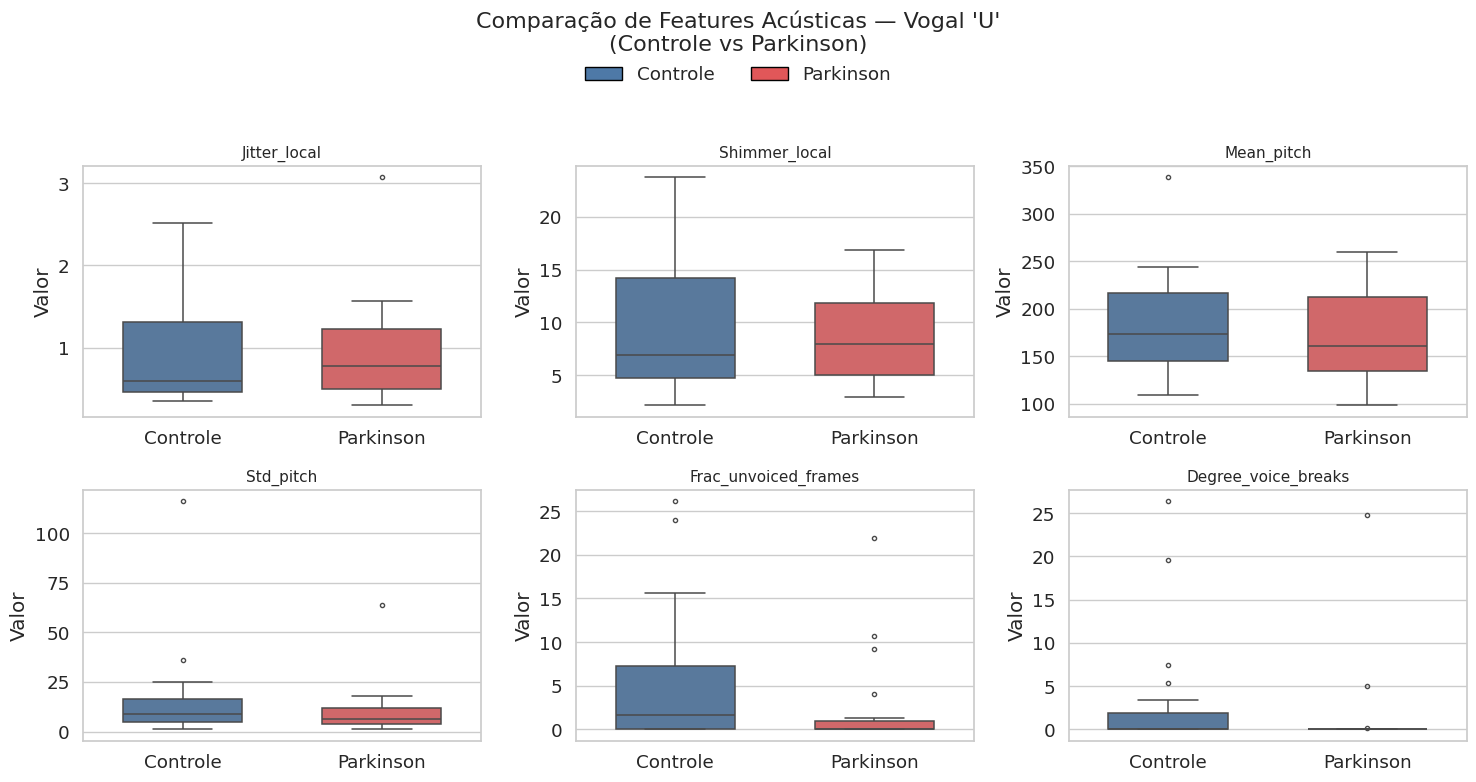

In [ ]:
# ============================================================
# 🎤 Boxplots PD vs Controle — Vogal "U"
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1️⃣ Filtrar apenas as amostras da vogal "U"
vowel_u = train[train['sample_type'] == 'Vowel_U'].copy()
vowel_u['class'] = vowel_u['class'].astype(int)

# 2️⃣ Cores padronizadas
AZUL = "#4E79A7"      # Controle
VERMELHO = "#E15759"  # Parkinson
palette = [AZUL, VERMELHO]

# 3️⃣ Features principais a comparar
features_vowel = [
    'Jitter_local',
    'Shimmer_local',
    'Mean_pitch',
    'Std_pitch',
    'Frac_unvoiced_frames',
    'Degree_voice_breaks'
]

# 4️⃣ Criar os subplots
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_vowel):
    ax = axes[i]
    sns.boxplot(
        data=vowel_u,
        x='class', y=feat,
        order=[0, 1],
        palette=palette,
        width=0.6,
        linewidth=1.1,
        fliersize=3,
        ax=ax
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Controle", "Parkinson"])
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Valor")

# 5️⃣ Legenda e título
fig.suptitle(
    "Comparação de Features Acústicas — Vogal 'U'\n(Controle vs Parkinson)",
    fontsize=16, y=0.98
)
legend_patches = [
    Patch(facecolor=AZUL, edgecolor='black', label='Controle'),
    Patch(facecolor=VERMELHO, edgecolor='black', label='Parkinson')
]
fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.93))

# 6️⃣ Layout final
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


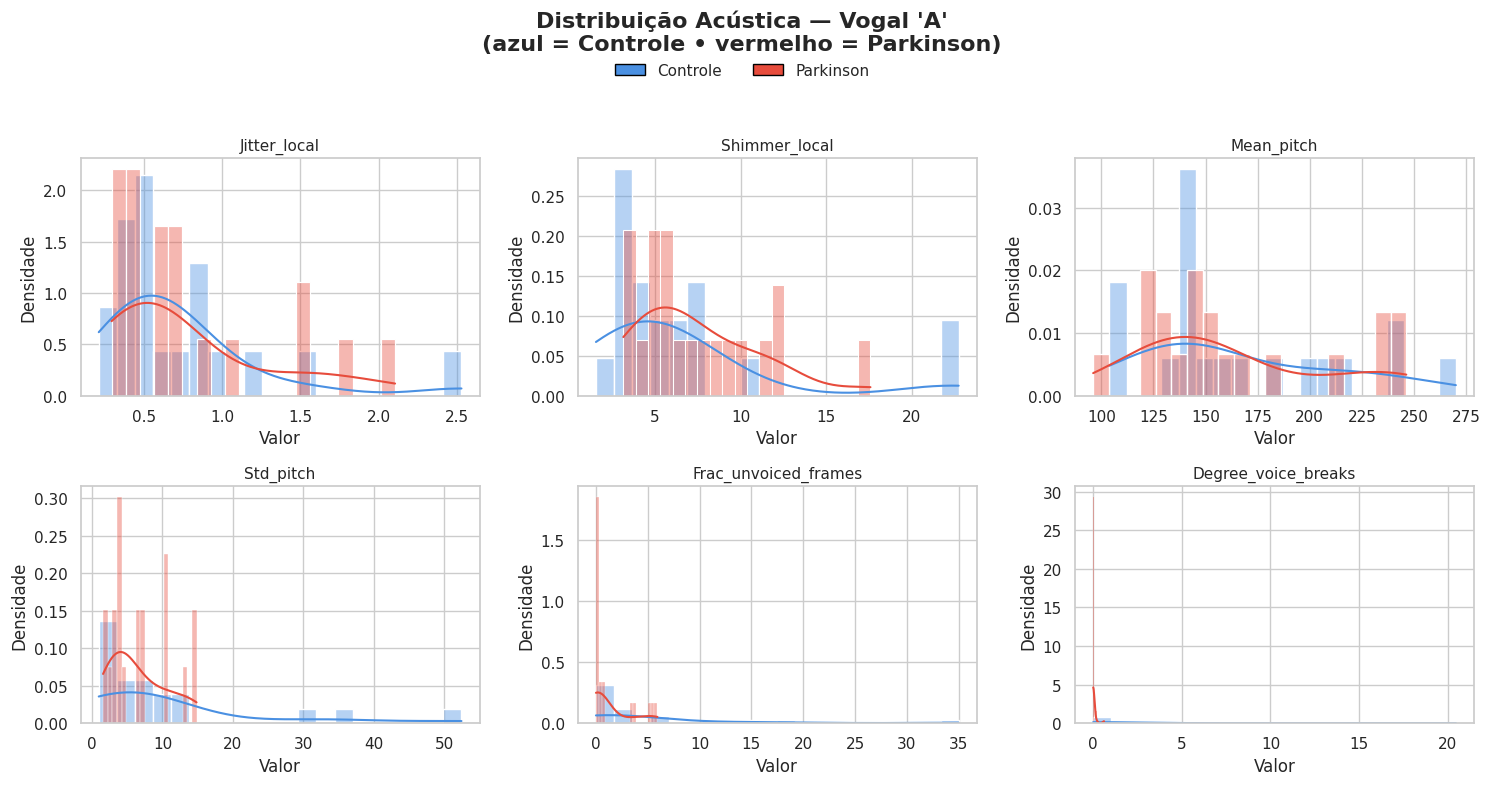

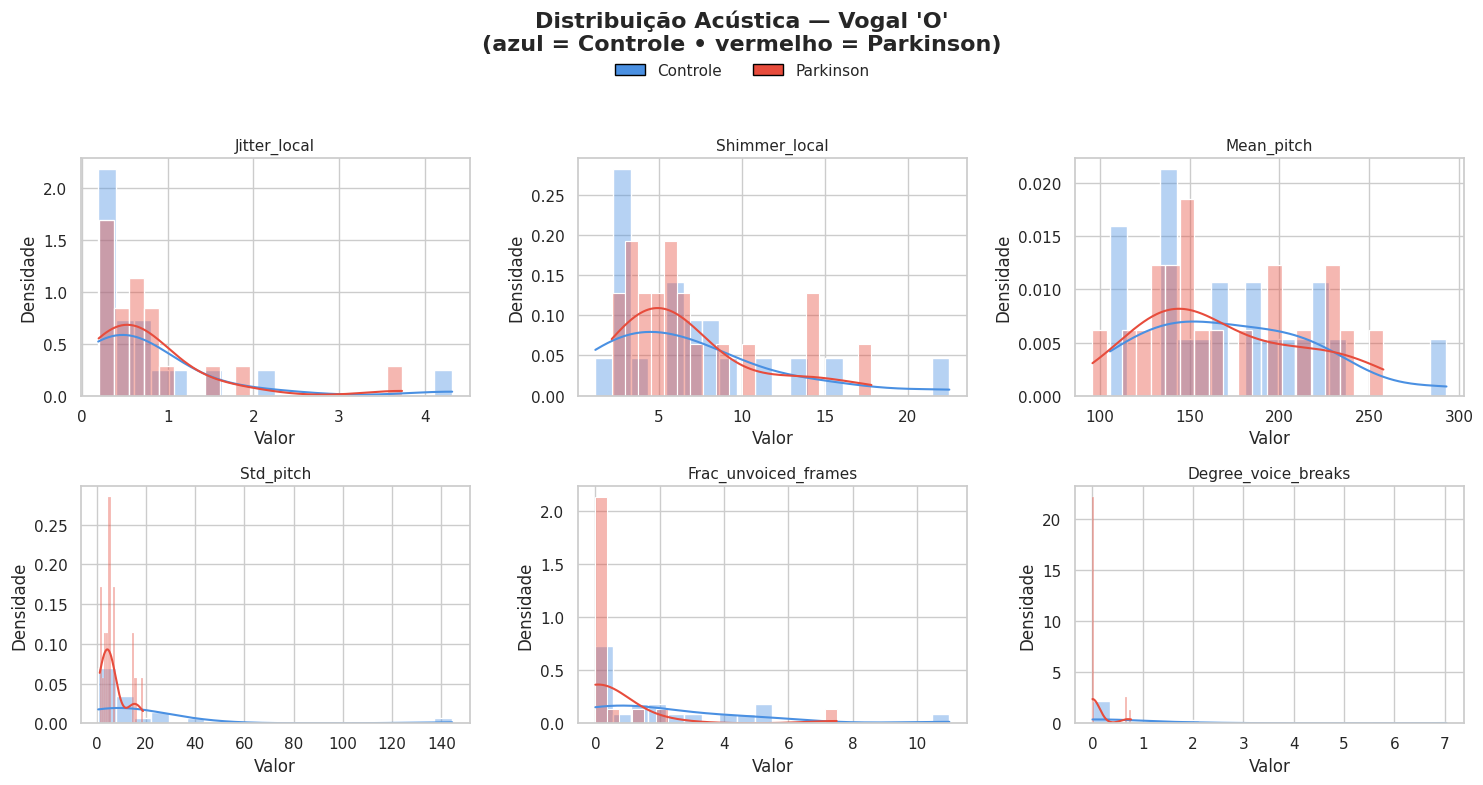

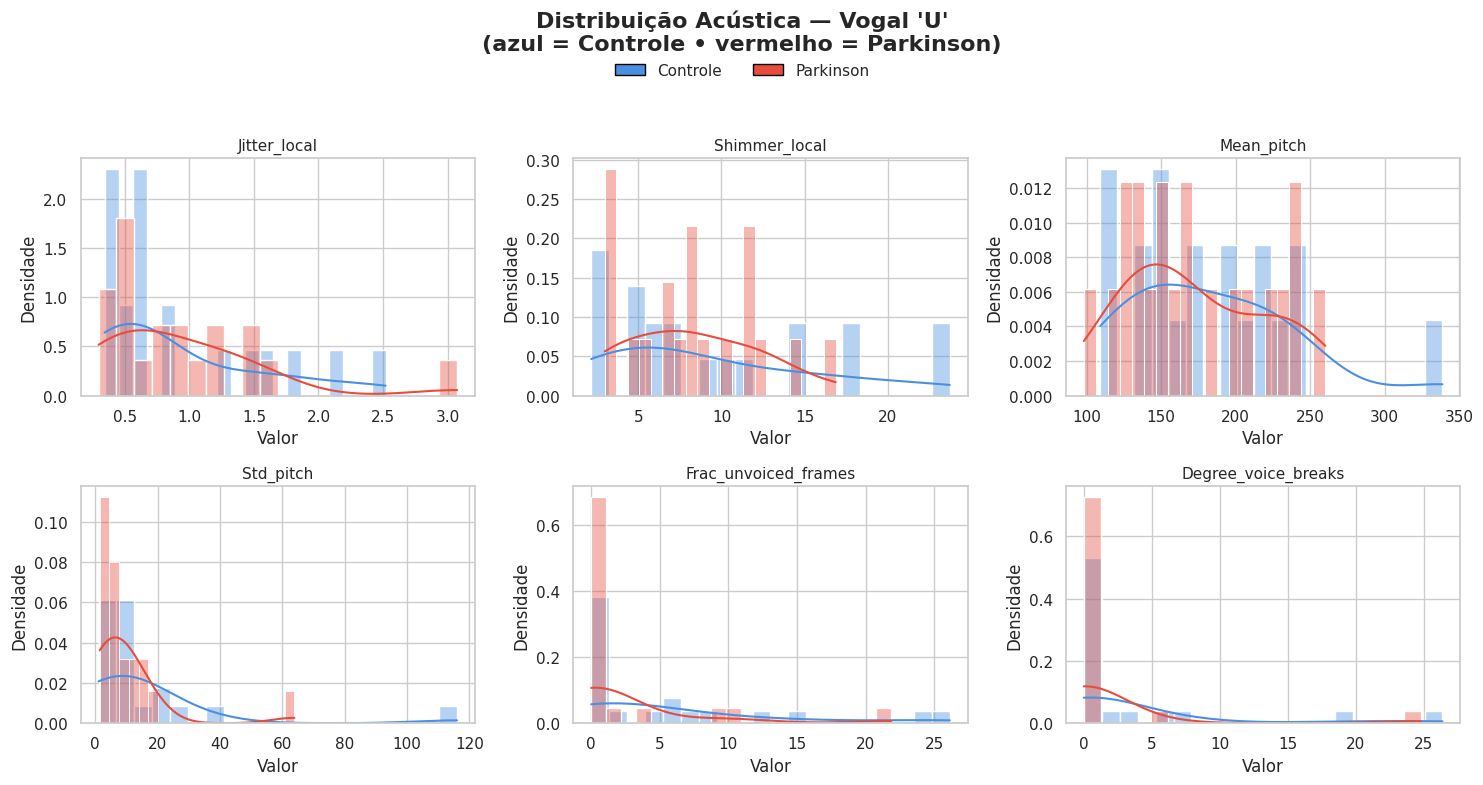

In [ ]:
# ============================================================
# HISTOGRAMAS — PD vs Controle por Vogal (A, O, U)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings

# ---- Configuração geral / estilo ----
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set(style="whitegrid")

# ---- Cores padronizadas ----
COLOR_CONTROLE = '#4A90E2'   # azul
COLOR_PD       = '#E74C3C'   # vermelho

# ---- Features principais ----
features_vowel = [
    'Jitter_local', 'Shimmer_local',
    'Mean_pitch', 'Std_pitch',
    'Frac_unvoiced_frames', 'Degree_voice_breaks'
]

# ---- Função genérica para plotar uma vogal ----
def plot_histograms_vowel(df, sample_type_value, titulo):
    # Filtra a vogal
    vdf = df[df['sample_type'] == sample_type_value].copy()

    # Garante que 'class' é 0/1 (numérico) mesmo se vier como string
    vdf['class'] = vdf['class'].astype(str).map({'0': 0, '1': 1}).astype(int)

    # Subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, feat in enumerate(features_vowel):
        ax = axes[i]

        # Controle (azul)
        sns.histplot(
            data=vdf[vdf['class'] == 0], x=feat, ax=ax,
            bins=20, stat='density', kde=True, alpha=0.40, color=COLOR_CONTROLE,
            edgecolor=None
        )

        # Parkinson (vermelho)
        sns.histplot(
            data=vdf[vdf['class'] == 1], x=feat, ax=ax,
            bins=20, stat='density', kde=True, alpha=0.40, color=COLOR_PD,
            edgecolor=None
        )

        ax.set_title(feat, fontsize=11)
        ax.set_xlabel("Valor")
        ax.set_ylabel("Densidade")

    # Título + legenda (sem sobreposição)
    fig.suptitle(
        f"Distribuição Acústica — {titulo}\n(azul = Controle • vermelho = Parkinson)",
        fontsize=16, fontweight='bold', y=0.98
    )
    legend_patches = [
        Patch(facecolor=COLOR_CONTROLE, edgecolor='black', label='Controle'),
        Patch(facecolor=COLOR_PD,       edgecolor='black', label='Parkinson')
    ]
    fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 0.93))

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

# ============================================================
# Executar para cada vogal
# ============================================================

# Vogal A
plot_histograms_vowel(train, 'Vowel_A', "Vogal 'A'")

# Vogal O
plot_histograms_vowel(train, 'Vowel_O', "Vogal 'O'")

# Vogal U
plot_histograms_vowel(train, 'Vowel_U', "Vogal 'U'")


In [ ]:
print(train.shape)
print(sorted(train['sample_number'].unique()))


(1040, 30)
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]


In [ ]:
# Filtrar apenas amostras 14–17 (frases)
phrases = train[train['sample_number'].between(14, 17)].copy()
print("Amostras de frases:", phrases.shape)
print(phrases['class'].value_counts())


Amostras de frases: (160, 30)
class
1    80
0    80
Name: count, dtype: int64


In [ ]:
features = [
    "Jitter_local", "Shimmer_local",
    "Mean_pitch", "Std_pitch",
    "Frac_unvoiced_frames", "Degree_voice_breaks"
]


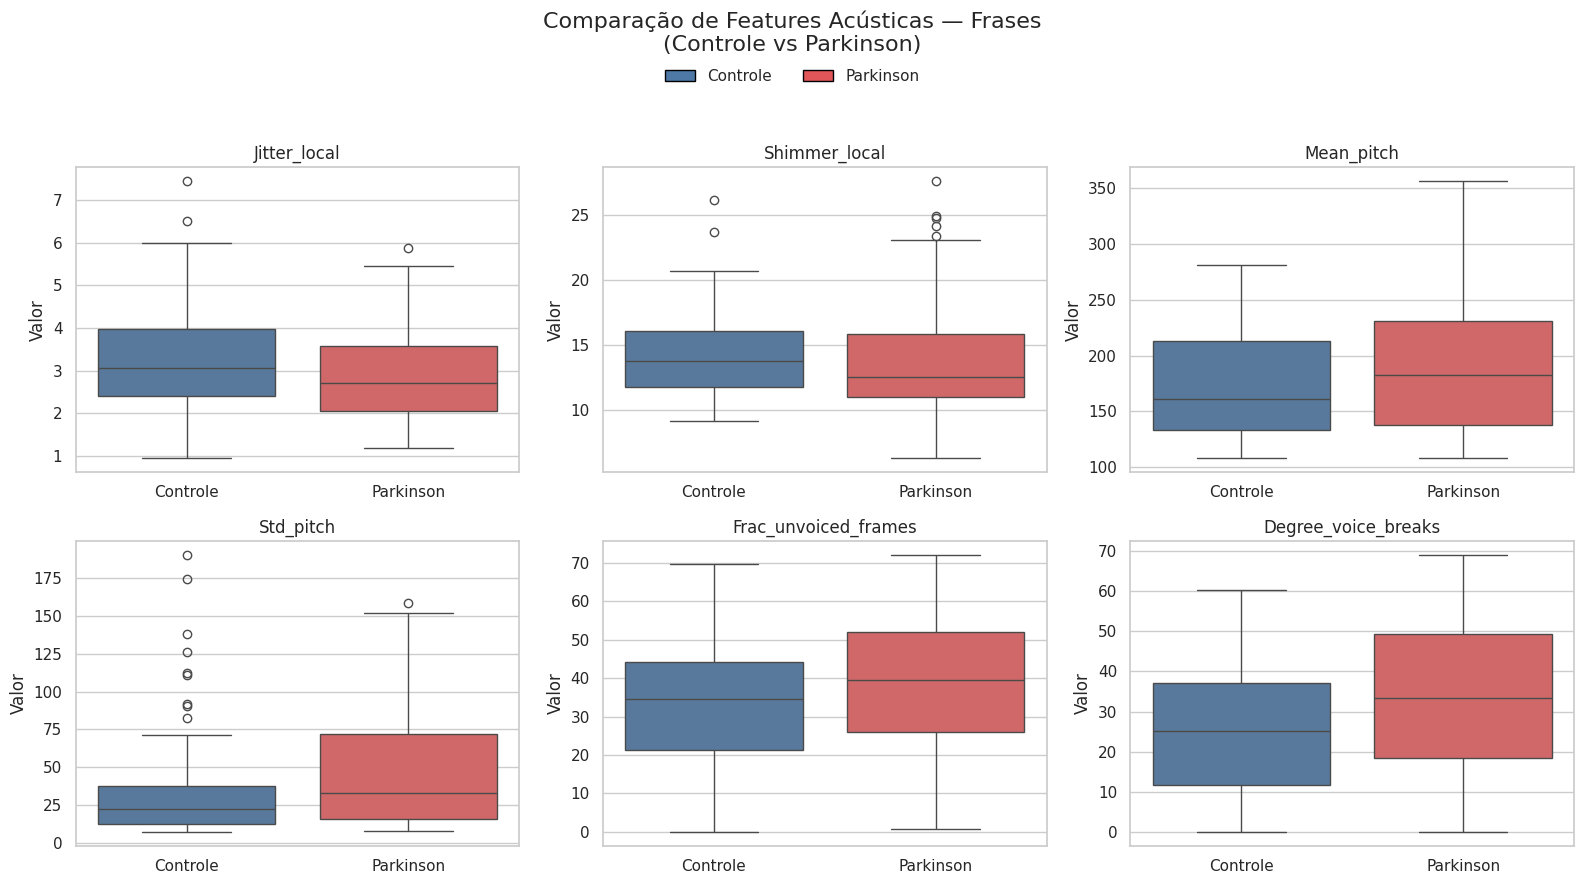

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# --------------------------------------------------
# Configurações gerais
# --------------------------------------------------
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set(style="whitegrid")

# ✅ Força a coluna de classe a ser string (garantindo compatibilidade)
phrases["class"] = phrases["class"].astype(str)

# Cores padronizadas
AZUL = "#4E79A7"      # Controle
VERMELHO = "#E15759"  # Parkinson
palette = [AZUL, VERMELHO]

# --------------------------------------------------
# Features principais
# --------------------------------------------------
features = [
    "Jitter_local", "Shimmer_local",
    "Mean_pitch", "Std_pitch",
    "Frac_unvoiced_frames", "Degree_voice_breaks"
]

# --------------------------------------------------
# Plotagem dos boxplots
# --------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    sns.boxplot(
        data=phrases, x="class", y=feat,
        palette=palette, ax=ax
    )
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Valor")
    ax.set_xticklabels(["Controle", "Parkinson"])

# Remove eixos vazios se existirem
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# --------------------------------------------------
# Título geral e ajustes
# --------------------------------------------------
fig.suptitle(
    "Comparação de Features Acústicas — Frases\n(Controle vs Parkinson)",
    fontsize=16, y=0.98
)
legend_patches = [
    Patch(facecolor=AZUL, edgecolor='black', label='Controle'),
    Patch(facecolor=VERMELHO, edgecolor='black', label='Parkinson')
]
fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.93))

# 6️⃣ Layout final
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


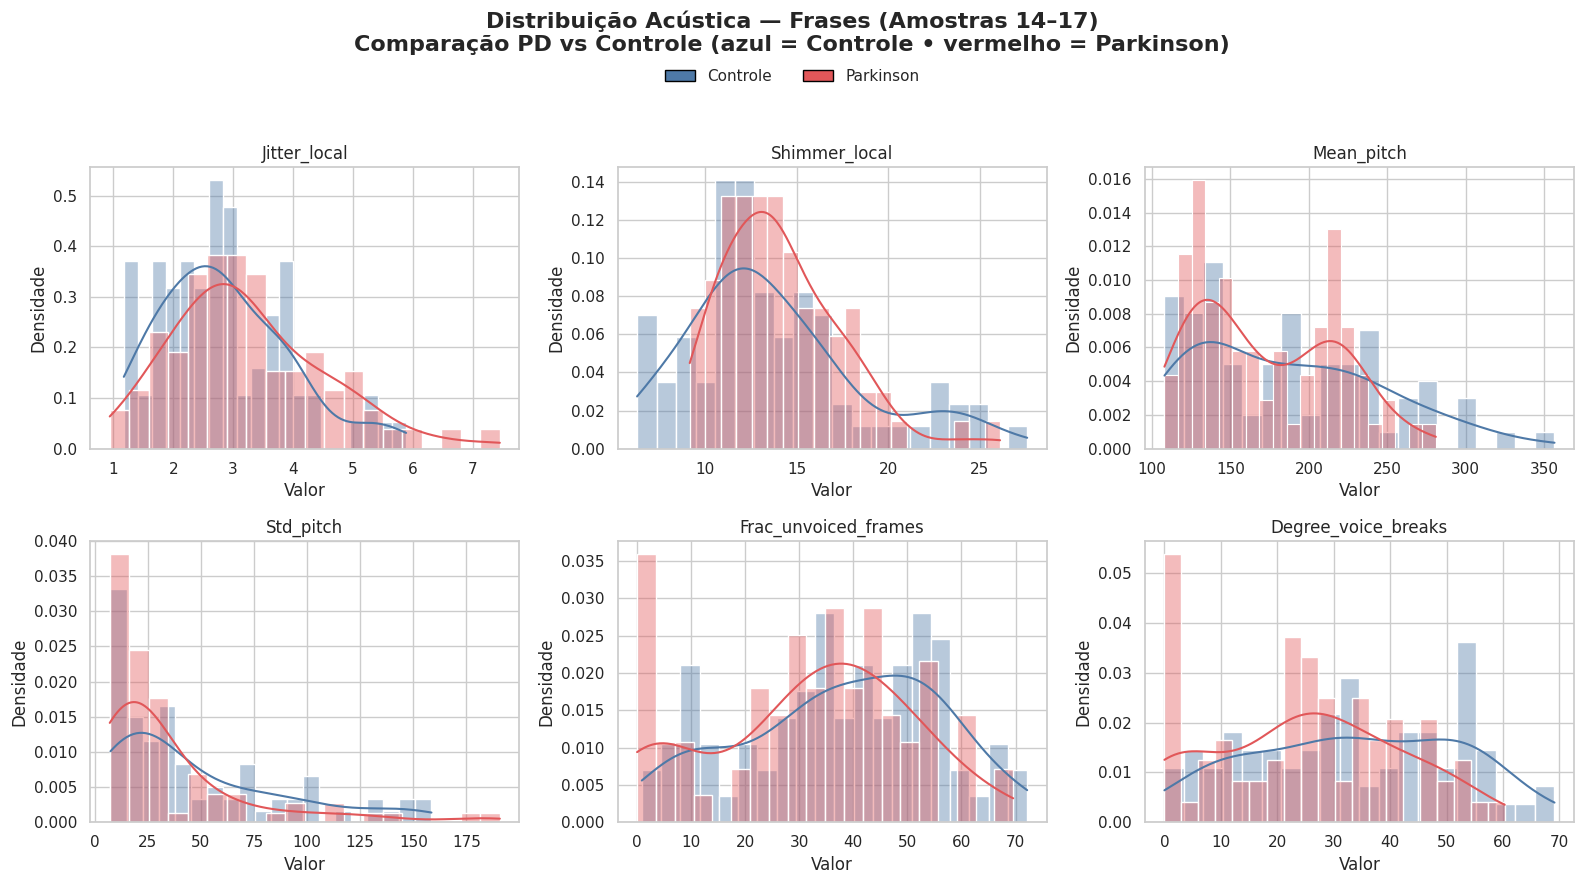

In [ ]:
# ============================================================
# HISTOGRAMAS — Comparação PD vs Controle (Frases 14–17)
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings

# --------------------------------------------------
# 1️⃣ Configurações gerais
# --------------------------------------------------
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set(style="whitegrid")

# Cores padronizadas
AZUL = "#4E79A7"      # Controle
VERMELHO = "#E15759"  # Parkinson
palette = {0: AZUL, 1: VERMELHO}

# --------------------------------------------------
# 2️⃣ Garantir que 'phrases' tenha a coluna 'class' no formato numérico
# --------------------------------------------------
phrases["class"] = phrases["class"].astype(str).map({"0": 0, "1": 1}).astype(int)

# --------------------------------------------------
# 3️⃣ Selecionar features principais
# --------------------------------------------------
features = [
    "Jitter_local", "Shimmer_local",
    "Mean_pitch", "Std_pitch",
    "Frac_unvoiced_frames", "Degree_voice_breaks"
]

# --------------------------------------------------
# 4️⃣ Criar os subplots
# --------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# --------------------------------------------------
# 5️⃣ Plotar histogramas sobrepostos
# --------------------------------------------------
for i, feat in enumerate(features):
    ax = axes[i]

    sns.histplot(
        data=phrases[phrases["class"] == 0],
        x=feat, color=AZUL, label="Controle",
        kde=True, stat="density", bins=20, alpha=0.4, ax=ax
    )

    sns.histplot(
        data=phrases[phrases["class"] == 1],
        x=feat, color=VERMELHO, label="Parkinson",
        kde=True, stat="density", bins=20, alpha=0.4, ax=ax
    )

    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidade")

# --------------------------------------------------
# 6️⃣ Legenda e título geral
# --------------------------------------------------
fig.suptitle(
    "Distribuição Acústica — Frases (Amostras 14–17)\n"
    "Comparação PD vs Controle (azul = Controle • vermelho = Parkinson)",
    fontsize=16, fontweight="bold", y=0.98
)

legend_patches = [
    Patch(facecolor=AZUL, edgecolor='black', label='Controle'),
    Patch(facecolor=VERMELHO, edgecolor='black', label='Parkinson')
]
fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.93))

# --------------------------------------------------
# 7️⃣ Ajustes finais e exibição
# --------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


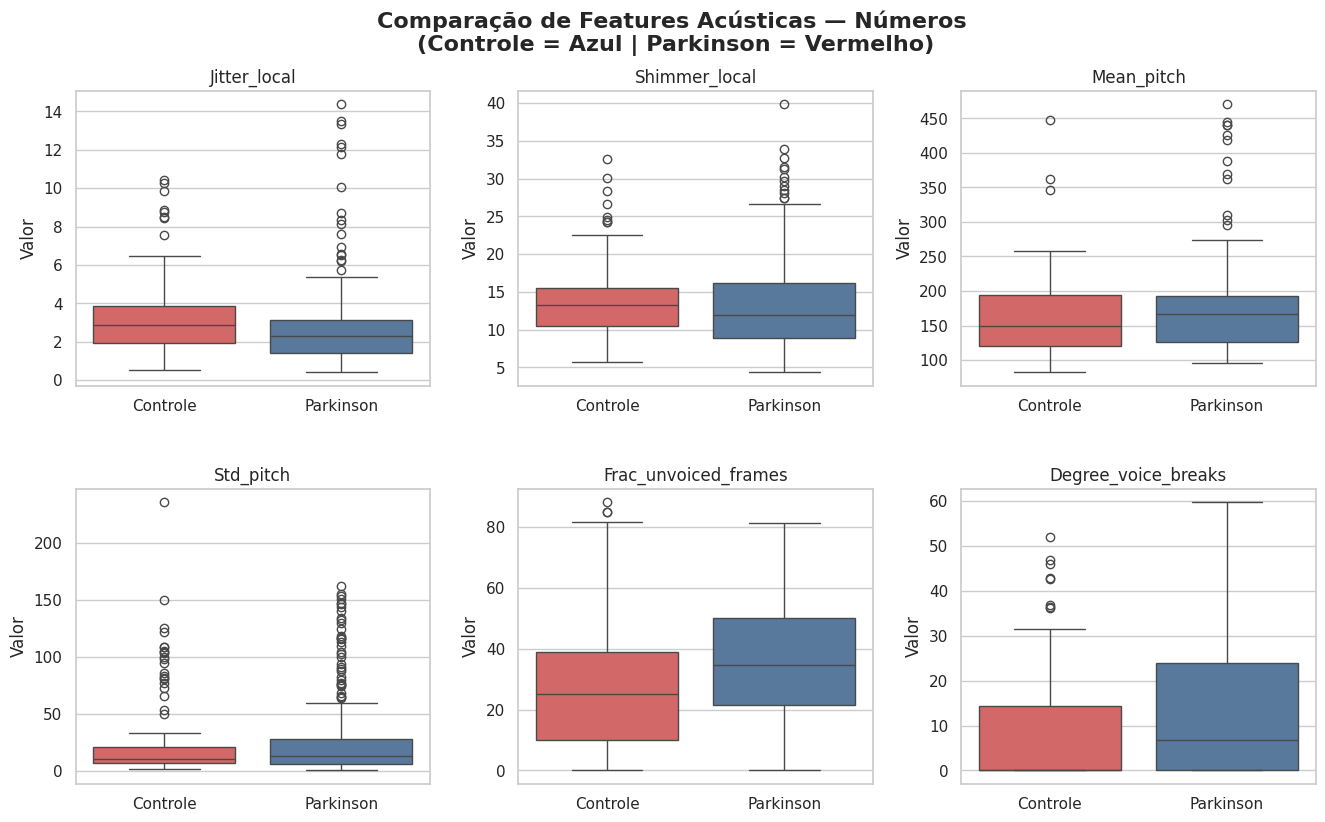

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# --------------------------------------------------
# Configurações gerais
# --------------------------------------------------
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set(style="whitegrid")

# --------------------------------------------------
# 1️⃣ Filtrar apenas as amostras correspondentes aos números (4–13)
# --------------------------------------------------
numbers = train[(train["sample_number"] >= 4) & (train["sample_number"] <= 13)].copy()

# Garantir consistência dos tipos de classe
numbers["class"] = numbers["class"].astype(str)

# Paleta de cores: 0 = Controle (azul), 1 = Parkinson (vermelho)
palette = {"0": "#4C78A8", "1": "#E45756"}

# --------------------------------------------------
# 2️⃣ Selecionar as mesmas 6 principais features acústicas
# --------------------------------------------------
features = [
    "Jitter_local", "Shimmer_local",
    "Mean_pitch", "Std_pitch",
    "Frac_unvoiced_frames", "Degree_voice_breaks"
]

# --------------------------------------------------
# 3️⃣ Criar os boxplots
# --------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    sns.boxplot(
        data=numbers, x="class", y=feat,
        palette=palette, ax=ax
    )
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Valor")
    ax.set_xticklabels(["Controle", "Parkinson"])

# Remover eixos extras, se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# --------------------------------------------------
# 4️⃣ Título geral
# --------------------------------------------------
plt.suptitle(
    "Comparação de Features Acústicas — Números \n"
    "(Controle = Azul | Parkinson = Vermelho)",
    fontsize=16, fontweight="bold", y=0.97
)
plt.subplots_adjust(hspace=0.35, wspace=0.25)
plt.show()


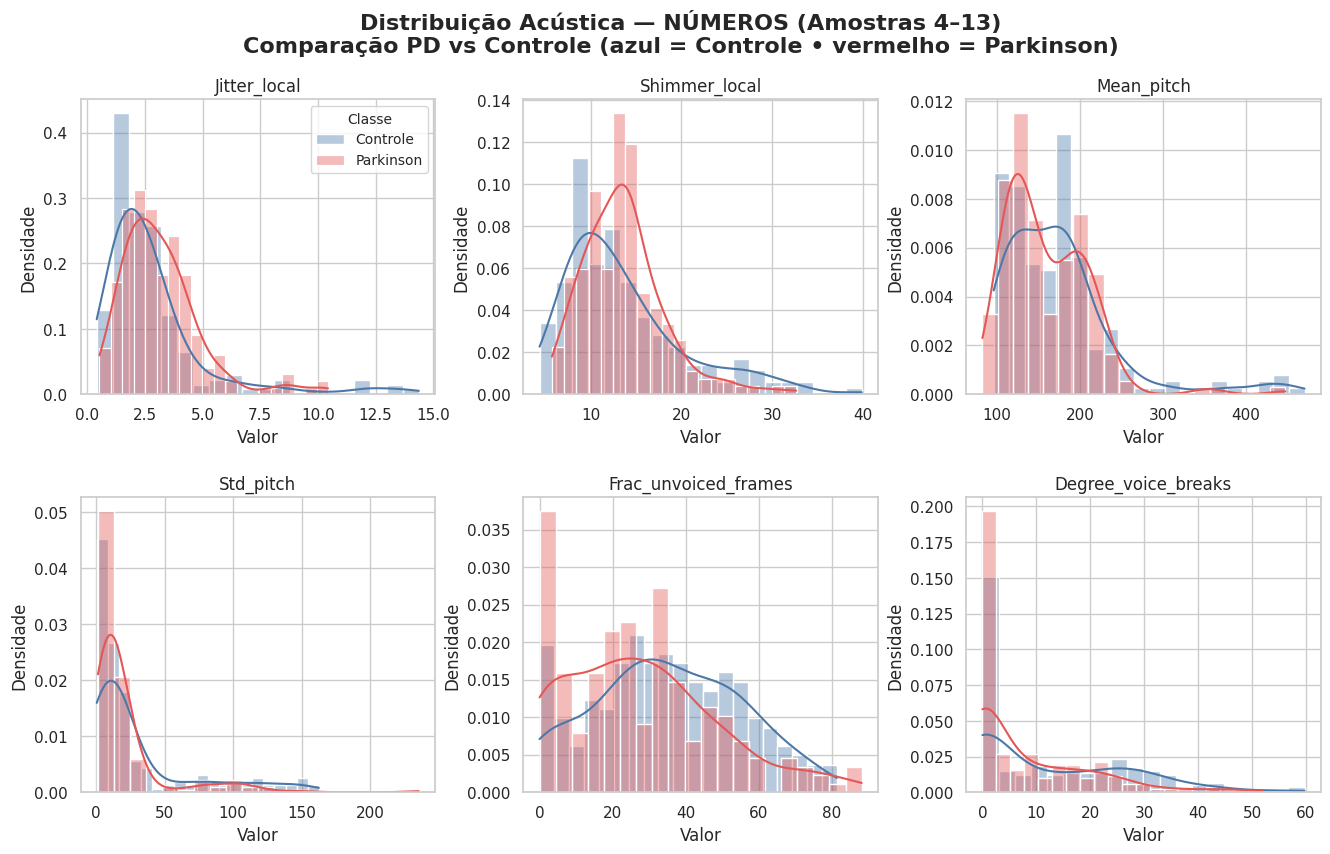

In [ ]:
# ==============================================
# HISTOGRAMAS — Comparação PD vs Controle
# Subgrupo: NÚMEROS (Amostras 4–13)
# ==============================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

# ---- Configurações
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set(style="whitegrid")

# ---- 1️⃣ Filtrar subconjunto das amostras de NÚMEROS (4–13)
if "sample_number" in train.columns:
    sample_col = "sample_number"
elif "sample" in train.columns:
    sample_col = "sample"
else:
    raise ValueError("Não encontrei coluna de amostra ('sample_number' ou 'sample') no DataFrame.")

numbers = train[(train[sample_col] >= 4) & (train[sample_col] <= 13)].copy()
numbers["class"] = numbers["class"].astype(str).map({"0": 0, "1": 1}).astype(int)

# ---- 2️⃣ Definir cores e features principais
palette = {0: "#4C78A8", 1: "#E45756"}  # Azul = Controle, Vermelho = Parkinson

features = [
    "Jitter_local", "Shimmer_local",
    "Mean_pitch", "Std_pitch",
    "Frac_unvoiced_frames", "Degree_voice_breaks"
]

# ---- 3️⃣ Criar subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# ---- 4️⃣ Plotar histogramas sobrepostos
for i, feat in enumerate(features):
    ax = axes[i]

    sns.histplot(
        data=numbers[numbers["class"] == 0], x=feat,
        color=palette[0], label="Controle", kde=True,
        stat="density", bins=20, alpha=0.4, ax=ax
    )

    sns.histplot(
        data=numbers[numbers["class"] == 1], x=feat,
        color=palette[1], label="Parkinson", kde=True,
        stat="density", bins=20, alpha=0.4, ax=ax
    )

    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidade")

    if i == 0:
        ax.legend(title="Classe", fontsize=10, title_fontsize=10)

# ---- 5️⃣ Ajustes visuais e título geral
plt.suptitle(
    "Distribuição Acústica — NÚMEROS (Amostras 4–13)\n"
    "Comparação PD vs Controle (azul = Controle • vermelho = Parkinson)",
    fontsize=16, fontweight="bold", y=0.98
)
plt.subplots_adjust(hspace=0.35, wspace=0.25)
plt.show()


Amostras de palavras por classe: {1: 180, 0: 180}


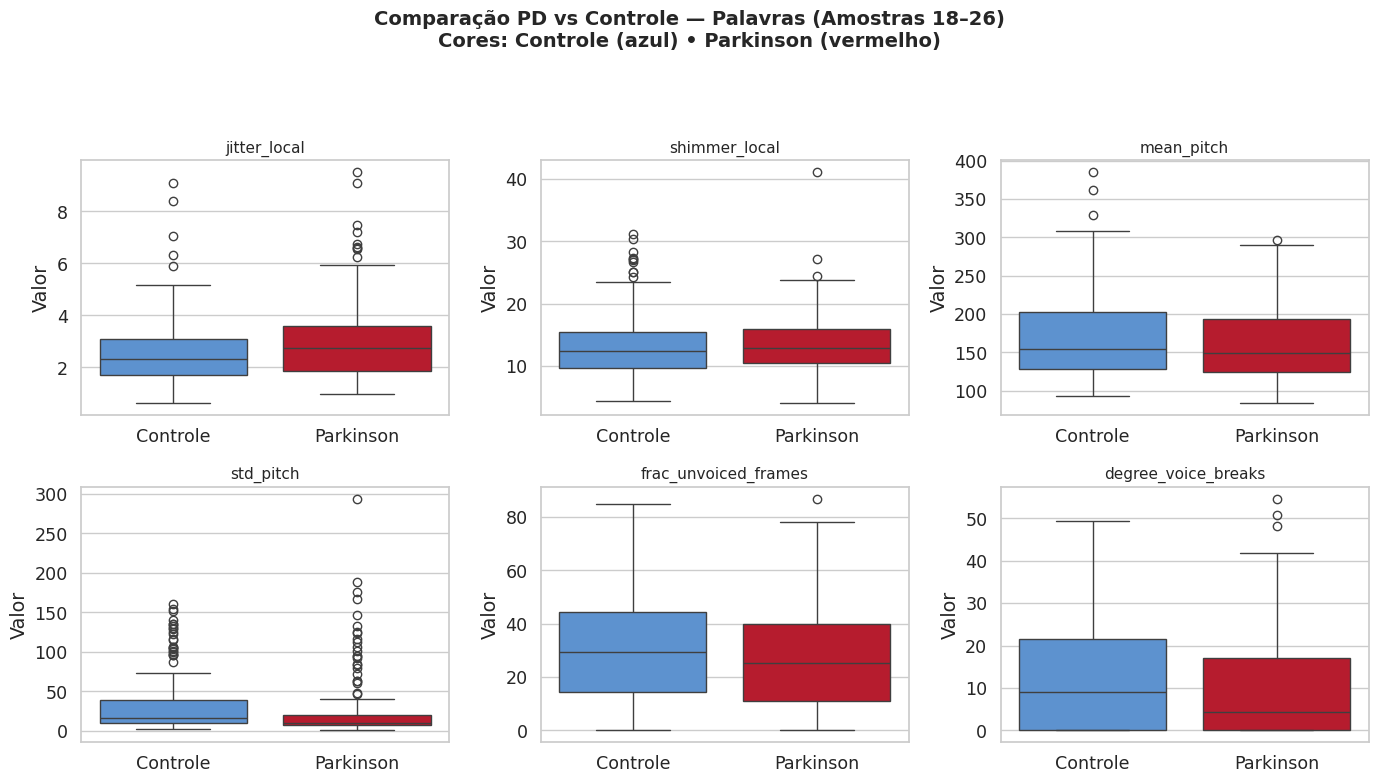

In [ ]:
# ============================================================
# 🎙️ Comparação Acústica — Palavras (Amostras 18–26)
# (Parkinson vs Controle)
# ============================================================

import re
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Filtrar apenas as amostras de PALAVRAS (18–26)
words = train[(train["sample_number"] >= 18) & (train["sample_number"] <= 26)].copy()

# Garantir classe como int e criar rótulo textual
words["class"] = words["class"].astype(int)
words["class_plot"] = words["class"].map({0: "Controle", 1: "Parkinson"}).astype("category")

print("Amostras de palavras por classe:", words["class"].value_counts().to_dict())

# --- 2️⃣ Normalizador para resolver nomes das colunas
def norm(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", s.lower())

canon = {norm(c): c for c in words.columns}

def find_col(possible_names):
    for name in possible_names:
        key = norm(name)
        if key in canon:
            return canon[key]
    return None

aliases = {
    "jitter_local": ["jitter (local)", "jitter_local", "jitter local", "jitterlocal"],
    "shimmer_local": ["shimmer (local)", "shimmer_local", "shimmer local", "shimmerlocal"],
    "mean_pitch": ["mean pitch", "mean_pitch", "f0 mean", "average pitch"],
    "std_pitch": ["std. deviation", "standard deviation", "std_pitch", "f0 std"],
    "frac_unvoiced_frames": [
        "fraction of locally unvoiced frames",
        "frac_unvoiced_frames", "unvoiced frames fraction"
    ],
    "degree_voice_breaks": [
        "degree of voice breaks", "degree_voice_breaks", "voice breaks degree"
    ],
}

resolved = {}
missing = []
for k, names in aliases.items():
    col = find_col(names)
    if col is None:
        missing.append(k)
    else:
        resolved[k] = col

if missing:
    raise ValueError(f"Não encontrei estas features no DF (ajuste aliases): {missing}\n"
                     f"Colunas disponíveis: {list(words.columns)}")

# --- 3️⃣ Plotagem dos boxplots
sns.set(style="whitegrid", font_scale=1.15)
palette = {"Controle": "#4A90E2", "Parkinson": "#D0021B"}  # Azul / Vermelho
order = ["Controle", "Parkinson"]

features_order = [
    "jitter_local",
    "shimmer_local",
    "mean_pitch",
    "std_pitch",
    "frac_unvoiced_frames",
    "degree_voice_breaks",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, key in enumerate(features_order):
    feat_col = resolved[key]
    ax = axes[i]
    sns.boxplot(
        data=words,
        x="class_plot", y=feat_col,
        order=order,
        palette=palette,
        ax=ax
    )
    ax.set_title(key, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Valor")

fig.suptitle(
    "Comparação PD vs Controle — Palavras (Amostras 18–26)\n"
    "Cores: Controle (azul) • Parkinson (vermelho)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


Amostras de palavras por classe: {1: 180, 0: 180}


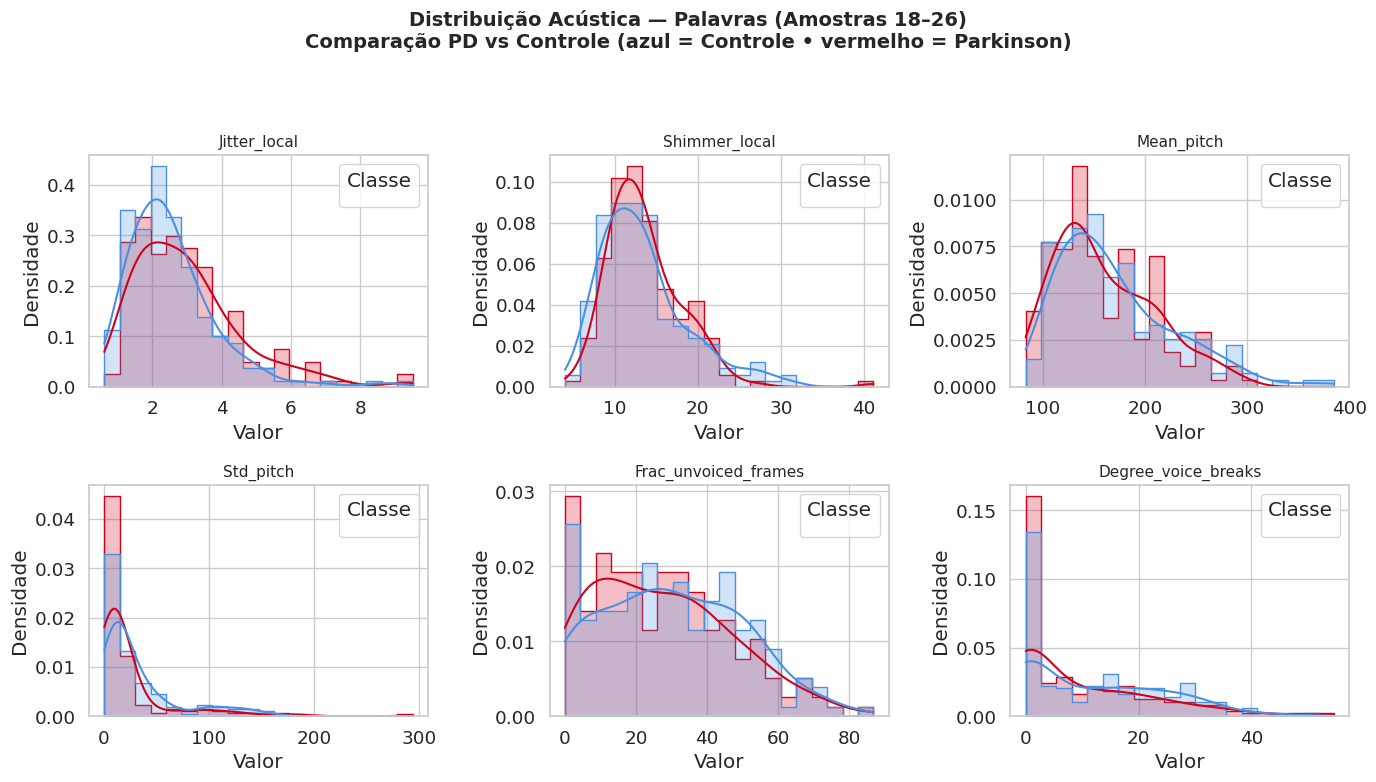

In [ ]:
# ============================================================
# 📊 Histogramas PD vs Controle — Palavras (Amostras 18–26)
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Filtrar as amostras de palavras (18–26)
words = train[(train["sample_number"] >= 18) & (train["sample_number"] <= 26)].copy()
words["class"] = words["class"].astype(int)
words["class_plot"] = words["class"].map({0: "Controle", 1: "Parkinson"}).astype("category")

print("Amostras de palavras por classe:", words["class"].value_counts().to_dict())

# --- 2️⃣ Definir features e paleta de cores
features = [
    "Jitter_local",
    "Shimmer_local",
    "Mean_pitch",
    "Std_pitch",
    "Frac_unvoiced_frames",
    "Degree_voice_breaks"
]

palette = {"Controle": "#4A90E2", "Parkinson": "#D0021B"}

# --- 3️⃣ Criar figura
sns.set(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

# --- 4️⃣ Gerar histogramas sobrepostos
for i, feat in enumerate(features):
    ax = axes[i]
    sns.histplot(
        data=words, x=feat, hue="class_plot",
        palette=palette, bins=20, kde=True,
        element="step", stat="density", common_norm=False, ax=ax
    )
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidade")
    ax.legend(title="Classe", loc="upper right")

fig.suptitle(
    "Distribuição Acústica — Palavras (Amostras 18–26)\n"
    "Comparação PD vs Controle (azul = Controle • vermelho = Parkinson)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


- PD mostra tendência a jitter maior (voz mais trêmula).
- PD mantém shimmer ligeiramente superior mas mais concentrado.
- PD - pitch médio menor (voz mais grave e sem modulação)
- PD - menor variação de frequência (fala "achatada")
- PD - menos pausas regulares, mas variabilidade entre pacientes.
- PD - fala mais contínua, mas menos natural (voz "presa")

# Validação Estatística e Avaliação de Modelos (Cross-Validation)

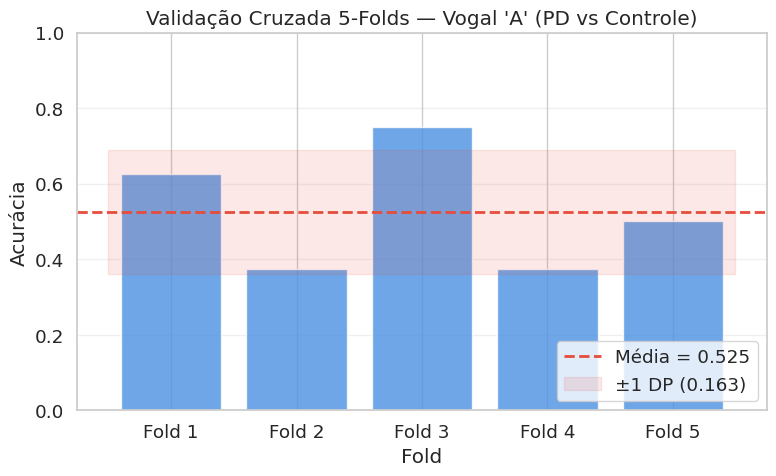

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Supondo que isso veio do cross_val_score:
accuracies = np.array([0.625, 0.375, 0.75, 0.375, 0.5])

mean_acc = accuracies.mean()
std_acc = accuracies.std(ddof=1)

folds = np.arange(1, len(accuracies) + 1)

plt.figure(figsize=(8, 5))

# Barras por fold
plt.bar(folds, accuracies, color="#4A90E2", alpha=0.8)
plt.axhline(mean_acc, color="#E74C3C", linestyle="--", linewidth=2,
            label=f"Média = {mean_acc:.3f}")

# Opcional: faixa de média ± desvio padrão
plt.fill_between(
    [0.5, len(accuracies) + 0.5],
    mean_acc - std_acc,
    mean_acc + std_acc,
    color="#E74C3C",
    alpha=0.12,
    label=f"±1 DP ({std_acc:.3f})"
)

plt.xticks(folds, [f"Fold {i}" for i in folds])
plt.ylim(0, 1)
plt.ylabel("Acurácia")
plt.xlabel("Fold")
plt.title("Validação Cruzada 5-Folds — Vogal 'A' (PD vs Controle)")
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1️⃣ Filtrar apenas as amostras da vogal "O"
# ============================================================
vowel_o = train[train["sample_type"] == "Vowel_O"].copy()

X = vowel_o.drop(columns=["class", "sample_type", "sample_number"])
y = vowel_o["class"].astype(int).values

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 2️⃣ Validação cruzada 5-folds
# ============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = SVC(kernel="linear")
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    accuracies.append(acc)

accuracies = np.array(accuracies)
mean_acc = accuracies.mean()
std_acc = accuracies.std()

print("Acurácias nos 5 folds:", accuracies)
print(f"Acurácia média: {mean_acc:.3f} ± {std_acc:.3f}")


Acurácias nos 5 folds: [0.875 1.    0.75  0.875 0.875]
Acurácia média: 0.875 ± 0.079


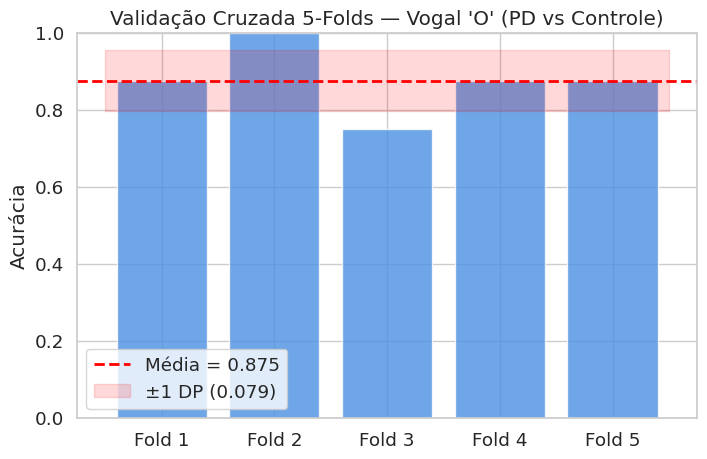

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar([f"Fold {i+1}" for i in range(5)], accuracies,
        color="#4A90E2", alpha=0.8)

# Linha da média
plt.axhline(mean_acc, color="red", linestyle="--", linewidth=2,
            label=f"Média = {mean_acc:.3f}")

# Faixa ±1 DP
plt.fill_between(
    [-0.5, 4.5],
    mean_acc - std_acc,
    mean_acc + std_acc,
    color="red",
    alpha=0.15,
    label=f"±1 DP ({std_acc:.3f})"
)

plt.ylim(0, 1)
plt.ylabel("Acurácia")
plt.title("Validação Cruzada 5-Folds — Vogal 'O' (PD vs Controle)")
plt.legend()
plt.show()


Acurácias (GroupKFold sem vazamento): [0.5   0.375 0.375 0.625 0.375]
Acurácia média: 0.450 ± 0.100


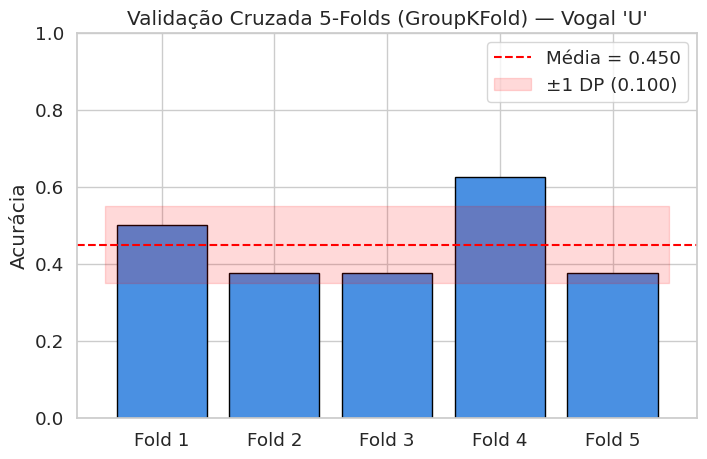

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1️⃣ Filtrar vogal U
# ==============================
vowel_u = train[train["sample_type"] == "Vowel_U"].copy()

# Garantir tipo da classe
vowel_u["class"] = vowel_u["class"].astype(int)

# Features que vamos usar
features_vowel = [
    'Jitter_local',
    'Shimmer_local',
    'Mean_pitch',
    'Std_pitch',
    'Frac_unvoiced_frames',
    'Degree_voice_breaks'
]

# Separar features e rótulos
X = vowel_u[features_vowel].values
y = vowel_u["class"].values

# AGRUPAMENTO — cada paciente é um grupo
groups = vowel_u["subject_id"].values

# ==============================
# 2️⃣ Configurar GroupKFold
# ==============================
gkf = GroupKFold(n_splits=5)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear"))
])

accuracies = []

# ==============================
# 3️⃣ Rodar validação sem vazamento
# ==============================
for train_idx, test_idx in gkf.split(X, y, groups):
    model.fit(X[train_idx], y[train_idx])
    acc = model.score(X[test_idx], y[test_idx])
    accuracies.append(acc)

accuracies = np.array(accuracies)
mean_acc = accuracies.mean()
std_acc = accuracies.std()

print("Acurácias (GroupKFold sem vazamento):", accuracies)
print(f"Acurácia média: {mean_acc:.3f} ± {std_acc:.3f}")

# ==============================
# 4️⃣ Gráfico de Barras
# ==============================
plt.figure(figsize=(8,5))
plt.bar(range(1,6), accuracies, color="#4A90E2", edgecolor="black")
plt.ylim(0,1)
plt.axhline(mean_acc, color="red", linestyle="--", label=f"Média = {mean_acc:.3f}")
plt.fill_between([0.5, 5.5], mean_acc - std_acc, mean_acc + std_acc,
                 color="red", alpha=0.15, label=f"±1 DP ({std_acc:.3f})")
plt.xticks(range(1,6), [f"Fold {i}" for i in range(1,6)])
plt.title("Validação Cruzada 5-Folds (GroupKFold) — Vogal 'U'")
plt.ylabel("Acurácia")
plt.legend()
plt.show()




# 5) EXPORTAÇÃO DOS DADOS FILTRADOS

In [ ]:
# ============================================================
# SALVAR FILTROS EM CSV
# ============================================================

# 1. Dataset completo (com as colunas já renomeadas)
train.to_csv("train_completo.csv", index=False)
test.to_csv("test_completo.csv", index=False)

# 2. Por categoria
vogais_train.to_csv("train_vogais.csv", index=False)
numeros_train.to_csv("train_numeros.csv", index=False)
frases_train.to_csv("train_frases.csv", index=False)
palavras_train.to_csv("train_palavras.csv", index=False)

# 3. Vogais individuais
vogal_a_train.to_csv("train_vogal_A.csv", index=False)
vogal_o_train.to_csv("train_vogal_O.csv", index=False)
vogal_u_train.to_csv("train_vogal_U.csv", index=False)

print("Arquivos CSV salvos")

Arquivos CSV salvos


In [ ]:
vogal_a_train

,subject_id,Jitter_local,Jitter_local_absolute,Jitter_rap,Jitter_ppq5,Jitter_ddp,Shimmer_local,Shimmer_local_dB,Shimmer_apq3,Shimmer_apq5,Shimmer_apq11,Shimmer_dda,AC,NTH,HTN,Median_pitch,Mean_pitch,Std_pitch,Min_pitch,Max_pitch,Num_pulses,Num_periods,Mean_period,Std_period,Frac_unvoiced_frames,Num_voice_breaks,Degree_voice_breaks,class,sample_number,sample_type
0,1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,6.802,13.551,0.905905,0.119116,11.130,166.533,164.781,10.421,142.229,187.576,160,159,0.006065,0.000416,0.000,0,0.000,1,1,Vowel_A
26,2,0.427,0.000034,0.243,0.249,0.728,7.428,0.694,4.205,4.311,5.250,12.616,0.966394,0.035275,15.267,124.171,123.883,2.179,118.461,129.205,345,344,0.008073,0.000143,0.000,0,0.000,1,1,Vowel_A
52,3,1.493,0.000064,0.912,0.822,2.735,11.521,1.068,5.552,7.495,10.720,16.657,0.913043,0.099982,10.744,240.722,234.117,14.841,212.176,260.570,102,101,0.004270,0.000279,0.000,0,0.000,1,1,Vowel_A
78,4,0.607,0.000025,0.357,0.378,1.071,9.491,0.887,5.349,5.733,6.450,16.047,0.949792,0.054203,13.452,245.445,246.303,3.191,240.788,254.963,354,353,0.004061,0.000060,0.000,0,0.000,1,1,Vowel_A
104,5,0.695,0.000057,0.386,0.394,1.159,17.582,1.593,9.968,11.287,15.725,29.905,0.864887,0.176638,9.041,121.641,121.347,4.351,112.758,129.860,163,162,0.008237,0.000299,0.752,0,0.000,1,1,Vowel_A
130,6,0.382,0.000027,0.177,0.238,0.532,5.219,0.468,2.589,2.890,4.646,7.768,0.974510,0.026475,16.685,141.319,141.279,1.565,137.269,145.152,671,670,0.007078,0.000081,0.000,0,0.000,1,1,Vowel_A
156,7,0.630,0.000042,0.192,0.251,0.576,5.659,0.547,2.546,3.454,5.046,7.637,0.981484,0.019481,18.186,146.808,149.804,10.282,139.211,184.867,88,87,0.006663,0.000478,0.000,0,0.000,1,1,Vowel_A
182,8,0.594,0.000043,0.325,0.303,0.976,5.300,0.516,2.833,3.100,4.236,8.499,0.961254,0.043428,15.321,140.395,139.585,6.718,123.556,154.411,219,218,0.007164,0.000344,0.000,0,0.000,1,1,Vowel_A
208,9,0.449,0.000035,0.165,0.198,0.495,3.616,0.320,1.401,2.298,4.359,4.202,0.982605,0.019794,20.476,128.534,128.787,4.106,120.885,142.468,197,196,0.007758,0.000272,0.000,0,0.000,1,1,Vowel_A
234,10,0.888,0.000092,0.352,0.435,1.057,5.995,0.604,2.757,3.522,5.367,8.270,0.948301,0.061915,14.438,96.258,96.067,7.303,76.987,113.597,99,98,0.010401,0.000781,5.455,0,0.000,1,1,Vowel_A


In [ ]:
numeros_train

,subject_id,Jitter_local,Jitter_local_absolute,Jitter_rap,Jitter_ppq5,Jitter_ddp,Shimmer_local,Shimmer_local_dB,Shimmer_apq3,Shimmer_apq5,Shimmer_apq11,Shimmer_dda,AC,NTH,HTN,Median_pitch,Mean_pitch,Std_pitch,Min_pitch,Max_pitch,Num_pulses,Num_periods,Mean_period,Std_period,Frac_unvoiced_frames,Num_voice_breaks,Degree_voice_breaks,class,sample_number,sample_type
3,1,2.502,0.000123,1.156,1.634,3.469,13.513,1.273,5.263,8.771,16.779,15.789,0.901302,0.121982,11.384,201.997,203.471,10.853,182.713,220.230,94,92,0.004910,0.000320,0.000,0,0.000,1,4,Number_1
4,1,3.509,0.000167,1.715,1.539,5.145,9.112,1.040,3.102,4.927,12.823,9.307,0.856907,0.236831,10.653,211.887,208.440,11.499,182.821,225.162,117,114,0.004757,0.000380,18.182,1,13.318,1,5,Number_2
5,1,2.470,0.000126,1.358,1.341,4.075,10.696,1.256,5.262,7.076,9.199,15.787,0.897708,0.152955,11.987,195.952,195.222,4.692,186.593,202.812,74,73,0.005118,0.000187,23.214,0,0.000,1,6,Number_3
6,1,1.583,0.000082,0.768,0.864,2.303,9.057,1.070,3.794,5.158,7.670,11.381,0.935717,0.078695,13.705,195.535,192.316,7.512,177.299,200.638,85,84,0.005199,0.000245,4.348,0,0.000,1,7,Number_4
7,1,1.920,0.000099,0.926,1.031,2.777,10.184,1.108,3.650,4.611,7.127,10.951,0.898598,0.147518,12.400,196.745,194.284,5.979,181.465,201.921,71,70,0.005137,0.000215,33.929,0,0.000,1,8,Number_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1022,40,3.602,0.000280,1.804,1.790,5.411,12.725,1.034,7.120,7.225,12.846,21.360,0.835268,0.251711,9.037,118.503,128.535,20.782,102.650,170.784,90,87,0.007768,0.001289,8.861,2,14.621,0,9,Number_6
1023,40,2.680,0.000207,1.010,1.057,3.029,15.145,1.501,5.717,10.919,18.244,17.152,0.888744,0.167500,11.830,124.106,129.827,21.883,95.651,167.166,104,103,0.007741,0.001363,1.266,0,0.000,0,10,Number_7
1024,40,1.927,0.000135,0.762,0.651,2.286,9.169,0.887,4.138,5.616,8.988,12.414,0.909017,0.119309,13.115,146.064,142.733,20.484,107.967,171.564,76,73,0.007004,0.001020,34.831,2,8.807,0,11,Number_8
1025,40,2.385,0.000163,1.048,1.098,3.143,10.006,0.967,3.718,5.792,11.143,11.153,0.893565,0.147745,12.414,145.354,146.307,24.690,111.416,183.454,96,93,0.006854,0.001216,18.072,2,9.706,0,12,Number_9


In [ ]:
train

,subject_id,Jitter_local,Jitter_local_absolute,Jitter_rap,Jitter_ppq5,Jitter_ddp,Shimmer_local,Shimmer_local_dB,Shimmer_apq3,Shimmer_apq5,Shimmer_apq11,Shimmer_dda,AC,NTH,HTN,Median_pitch,Mean_pitch,Std_pitch,Min_pitch,Max_pitch,Num_pulses,Num_periods,Mean_period,Std_period,Frac_unvoiced_frames,Num_voice_breaks,Degree_voice_breaks,class,sample_number,sample_type
0,1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,6.802,13.551,0.905905,0.119116,11.130,166.533,164.781,10.421,142.229,187.576,160,159,0.006065,0.000416,0.000,0,0.000,1,1,Vowel_A
1,1,0.728,0.000038,0.353,0.376,1.059,5.864,0.642,2.058,3.180,7.194,6.175,0.951285,0.066758,17.403,195.252,193.289,14.773,159.515,234.505,170,169,0.005181,0.000403,2.247,0,0.000,1,2,Vowel_O
2,1,1.220,0.000074,0.732,0.670,2.196,8.719,0.875,4.347,5.166,7.548,13.040,0.911508,0.109983,12.212,158.689,164.768,12.981,146.445,211.442,1431,1427,0.006071,0.000474,10.656,1,0.178,1,3,Vowel_U
3,1,2.502,0.000123,1.156,1.634,3.469,13.513,1.273,5.263,8.771,16.779,15.789,0.901302,0.121982,11.384,201.997,203.471,10.853,182.713,220.230,94,92,0.004910,0.000320,0.000,0,0.000,1,4,Number_1
4,1,3.509,0.000167,1.715,1.539,5.145,9.112,1.040,3.102,4.927,12.823,9.307,0.856907,0.236831,10.653,211.887,208.440,11.499,182.821,225.162,117,114,0.004757,0.000380,18.182,1,13.318,1,5,Number_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,40,5.127,0.000398,2.721,2.510,8.162,9.846,0.965,4.593,6.806,8.303,13.780,0.754472,0.430569,6.798,126.492,130.350,14.387,96.145,158.591,63,60,0.007766,0.001066,24.194,2,15.113,0,22,Word_5
1036,40,1.757,0.000133,0.808,0.690,2.425,7.571,0.740,2.720,3.927,11.928,8.160,0.880775,0.160787,11.216,128.142,132.244,7.140,121.490,143.797,47,44,0.007561,0.000430,46.053,1,25.792,0,23,Word_6
1037,40,2.912,0.000226,1.141,1.266,3.423,15.489,1.456,6.433,10.138,14.239,19.300,0.883146,0.161736,11.035,129.727,128.388,13.593,95.921,149.641,79,77,0.007767,0.000881,20.000,1,4.574,0,24,Word_7
1038,40,3.788,0.000275,1.786,1.484,5.359,15.702,1.367,6.374,11.094,18.818,19.123,0.765474,0.423034,6.583,126.131,135.943,46.764,90.051,451.366,75,70,0.007257,0.001714,16.667,3,19.575,0,25,Word_8


In [ ]:
# Baixar os arquivos
from google.colab import files

# Datasets completos
files.download("train_completo.csv")
files.download("test_completo.csv")

# Download por categoria
files.download("train_vogais.csv")
files.download("train_numeros.csv")
files.download("train_frases.csv")
files.download("train_palavras.csv")

# Download por vogal
files.download("train_vogal_A.csv")
files.download("train_vogal_O.csv")
files.download("train_vogal_U.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 6) Análises Avançadas e Preparação para ML

# 7) Experimentação com Classificadores

In [ ]:
# ============================================================
# FUNÇÃO PARA EXPERIMENTAÇÃO COM CLASSIFICADORES
# SVM - RBF, Regressão Logística, Random Forest, KNN e Gradient Boosting
# (retorna também o `scores` do cross_validate)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

FEATURES = [
    'Jitter_local', 'Jitter_local_absolute', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp',
    'Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5',
    'Shimmer_apq11', 'Shimmer_dda', 'AC', 'NTH', 'HTN',
    'Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch',
    'Num_pulses', 'Num_periods', 'Mean_period', 'Std_period',
    'Frac_unvoiced_frames', 'Num_voice_breaks', 'Degree_voice_breaks'
]



def executar_experimento(df, nome_experimento, n_splits=5):
    # Preparar dados
    X = df[FEATURES].values
    y = df["class"].astype(int).values
    groups = df["subject_id"].values

    # GroupKFold (evita vazamento por sujeito)
    n_groups = len(np.unique(groups))
    n_splits_efetivo = min(n_splits, n_groups)
    gkf = GroupKFold(n_splits=n_splits_efetivo)

    print(f"EXPERIMENTO: {nome_experimento}")
    print(f"Amostras: {len(df)} | Folds: {n_splits_efetivo}")
    print(f"Controle: {sum(y==0)} | Parkinson: {sum(y==1)}")


    # 1) Classificador: SVM RBF

    pipeline_svm = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="rbf", probability=True, random_state=42))
    ])

    scores_svm = cross_validate(
        pipeline_svm, X, y,
        cv=gkf,
        groups=groups,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=False
    )

    resultado_svm = {
        "Classificador": "SVM RBF",
        "Acurácia": scores_svm["test_accuracy"].mean(),
        "Acurácia_std": scores_svm["test_accuracy"].std(),
        "Precisão": scores_svm["test_precision"].mean(),
        "Precisão_std": scores_svm["test_precision"].std(),
        "Recall": scores_svm["test_recall"].mean(),
        "Recall_std": scores_svm["test_recall"].std(),
        "F1-Score": scores_svm["test_f1"].mean(),
        "F1-Score_std": scores_svm["test_f1"].std(),
        "AUC-ROC": scores_svm["test_roc_auc"].mean(),
        "AUC-ROC_std": scores_svm["test_roc_auc"].std(),
        "Acurácias_folds": scores_svm["test_accuracy"],
        "Precisões_folds": scores_svm["test_precision"],
        "Recall_folds": scores_svm["test_recall"],
        "F1_folds": scores_svm["test_f1"],
        "AUC_folds": scores_svm["test_roc_auc"],
    }

    print("\nSVM RBF")
    print(f"Acc média: {resultado_svm['Acurácia']:.3f} ± {resultado_svm['Acurácia_std']:.3f}")
    print(f"Precisão média: {resultado_svm['Precisão']:.3f} ± {resultado_svm['Precisão_std']:.3f}")
    print(f"Recall média: {resultado_svm['Recall']:.3f} ± {resultado_svm['Recall_std']:.3f}")
    print(f"F1-Score média: {resultado_svm['F1-Score']:.3f} ± {resultado_svm['F1-Score_std']:.3f}")
    print(f"AUC-ROC média: {resultado_svm['AUC-ROC']:.3f} ± {resultado_svm['AUC-ROC_std']:.3f}")


    # 2) Classificador: Regressão Logística

    pipeline_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])

    scores_lr = cross_validate(
        pipeline_lr, X, y,
        cv=gkf,
        groups=groups,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=False
    )

    resultado_lr = {
        "Classificador": "Regressão Logística",
        "Acurácia": scores_lr["test_accuracy"].mean(),
        "Acurácia_std": scores_lr["test_accuracy"].std(),
        "Precisão": scores_lr["test_precision"].mean(),
        "Precisão_std": scores_lr["test_precision"].std(),
        "Recall": scores_lr["test_recall"].mean(),
        "Recall_std": scores_lr["test_recall"].std(),
        "F1-Score": scores_lr["test_f1"].mean(),
        "F1-Score_std": scores_lr["test_f1"].std(),
        "AUC-ROC": scores_lr["test_roc_auc"].mean(),
        "AUC-ROC_std": scores_lr["test_roc_auc"].std(),
        "Acurácias_folds": scores_lr["test_accuracy"],
        "Precisões_folds": scores_lr["test_precision"],
        "Recall_folds": scores_lr["test_recall"],
        "F1_folds": scores_lr["test_f1"],
        "AUC_folds": scores_lr["test_roc_auc"],
    }

    print("\nRegressão Logística")
    print(f"Acc média: {resultado_lr['Acurácia']:.3f} ± {resultado_lr['Acurácia_std']:.3f}")
    print(f"Precisão média: {resultado_lr['Precisão']:.3f} ± {resultado_lr['Precisão_std']:.3f}")
    print(f"Recall média: {resultado_lr['Recall']:.3f} ± {resultado_lr['Recall_std']:.3f}")
    print(f"F1-Score média: {resultado_lr['F1-Score']:.3f} ± {resultado_lr['F1-Score_std']:.3f}")
    print(f"AUC-ROC média: {resultado_lr['AUC-ROC']:.3f} ± {resultado_lr['AUC-ROC_std']:.3f}")

    # 3) Classificador: Random Forest

    pipeline_rf = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    scores_rf = cross_validate(
        pipeline_rf, X, y,
        cv=gkf,
        groups=groups,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=False
    )

    resultado_rf = {
        "Classificador": "Random Forest",
        "Acurácia": scores_rf["test_accuracy"].mean(),
        "Acurácia_std": scores_rf["test_accuracy"].std(),
        "Precisão": scores_rf["test_precision"].mean(),
        "Precisão_std": scores_rf["test_precision"].std(),
        "Recall": scores_rf["test_recall"].mean(),
        "Recall_std": scores_rf["test_recall"].std(),
        "F1-Score": scores_rf["test_f1"].mean(),
        "F1-Score_std": scores_rf["test_f1"].std(),
        "AUC-ROC": scores_rf["test_roc_auc"].mean(),
        "AUC-ROC_std": scores_rf["test_roc_auc"].std(),
        "Acurácias_folds": scores_rf["test_accuracy"],
        "Precisões_folds": scores_rf["test_precision"],
        "Recall_folds": scores_rf["test_recall"],
        "F1_folds": scores_rf["test_f1"],
        "AUC_folds": scores_rf["test_roc_auc"],
    }

    print("\n Random Forest")
    print(f"Acc média: {resultado_rf['Acurácia']:.3f} ± {resultado_rf['Acurácia_std']:.3f}")
    print(f"Precisão média: {resultado_rf['Precisão']:.3f} ± {resultado_rf['Precisão_std']:.3f}")
    print(f"Recall média: {resultado_rf['Recall']:.3f} ± {resultado_rf['Recall_std']:.3f}")
    print(f"F1-Score média: {resultado_rf['F1-Score']:.3f} ± {resultado_rf['F1-Score_std']:.3f}")
    print(f"AUC-ROC média: {resultado_rf['AUC-ROC']:.3f} ± {resultado_rf['AUC-ROC_std']:.3f}")

    # 4) Clasificador: KNN

    pipeline_knn = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
        ])

    scores_knn = cross_validate(
        pipeline_knn, X, y,
        cv=gkf,
        groups=groups,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=False
    )

    resultado_knn = {
        "Classificador": "KNN",
        "Acurácia": scores_knn["test_accuracy"].mean(),
        "Acurácia_std": scores_knn["test_accuracy"].std(),
        "Precisão": scores_knn["test_precision"].mean(),
        "Precisão_std": scores_knn["test_precision"].std(),
        "Recall": scores_knn["test_recall"].mean(),
        "Recall_std": scores_knn["test_recall"].std(),
        "F1-Score": scores_knn["test_f1"].mean(),
        "F1-Score_std": scores_knn["test_f1"].std(),
        "AUC-ROC": scores_knn["test_roc_auc"].mean(),
        "AUC-ROC_std": scores_knn["test_roc_auc"].std(),
        "Acurácias_folds": scores_knn["test_accuracy"],
        "Precisões_folds": scores_knn["test_precision"],
        "Recall_folds": scores_knn["test_recall"],
        "F1_folds": scores_knn["test_f1"],
        "AUC_folds": scores_knn["test_roc_auc"],
    }

    print("\n KNN")
    print(f"Acc média: {resultado_knn['Acurácia']:.3f} ± {resultado_knn['Acurácia_std']:.3f}")
    print(f"Precisão média: {resultado_knn['Precisão']:.3f} ± {resultado_knn['Precisão_std']:.3f}")
    print(f"Recall média: {resultado_knn['Recall']:.3f} ± {resultado_knn['Recall_std']:.3f}")
    print(f"F1-Score média: {resultado_knn['F1-Score']:.3f} ± {resultado_knn['F1-Score_std']:.3f}")
    print(f"AUC-ROC média: {resultado_knn['AUC-ROC']:.3f} ± {resultado_knn['AUC-ROC_std']:.3f}")

    # 5) Gradient Boosting(XGBoost, LightGBM, CatBoost)

    pipeline_gb = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])

    scores_gb = cross_validate(
        pipeline_gb, X, y,
        cv=gkf,
        groups=groups,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=False
    )

    resultado_gb = {
        "Classificador": "Gradient Boosting",
        "Acurácia": scores_gb["test_accuracy"].mean(),
        "Acurácia_std": scores_gb["test_accuracy"].std(),
        "Precisão": scores_gb["test_precision"].mean(),
        "Precisão_std": scores_gb["test_precision"].std(),
        "Recall": scores_gb["test_recall"].mean(),
        "Recall_std": scores_gb["test_recall"].std(),
        "F1-Score": scores_gb["test_f1"].mean(),
        "F1-Score_std": scores_gb["test_f1"].std(),
        "AUC-ROC": scores_gb["test_roc_auc"].mean(),
        "AUC-ROC_std": scores_gb["test_roc_auc"].std(),
        "Acurácias_folds": scores_gb["test_accuracy"],
        "Precisões_folds": scores_gb["test_precision"],
        "Recall_folds": scores_gb["test_recall"],
        "F1_folds": scores_gb["test_f1"],
        "AUC_folds": scores_gb["test_roc_auc"],
    }

    print("\n Gradient Boosting")
    print(f"Acc média: {resultado_gb['Acurácia']:.3f} ± {resultado_gb['Acurácia_std']:.3f}")
    print(f"Precisão média: {resultado_gb['Precisão']:.3f} ± {resultado_gb['Precisão_std']:.3f}")
    print(f"Recall média: {resultado_gb['Recall']:.3f} ± {resultado_gb['Recall_std']:.3f}")
    print(f"F1-Score média: {resultado_gb['F1-Score']:.3f} ± {resultado_gb['F1-Score_std']:.3f}")
    print(f"AUC-ROC média: {resultado_gb['AUC-ROC']:.3f} ± {resultado_gb['AUC-ROC_std']:.3f}")




    df_resultados = pd.DataFrame([resultado_svm, resultado_lr, resultado_rf, resultado_knn, resultado_gb])
    scores_dict = {"SVM RBF": scores_svm, "Regressao Logística": scores_lr, "Random Forest": scores_rf, "KNN": scores_knn, "Gradient Boost": scores_gb}
    return df_resultados, scores_dict

In [ ]:
df_resultados, scores_dict = executar_experimento(
    train,
    "treinamento com todos os classificadores"
)
df_resultados

EXPERIMENTO: treinamento com todos os classificadores
Amostras: 1040 | Folds: 5
Controle: 520 | Parkinson: 520

SVM RBF
Acc média: 0.557 ± 0.079
Precisão média: 0.562 ± 0.083
Recall média: 0.577 ± 0.115
F1-Score média: 0.563 ± 0.078
AUC-ROC média: 0.591 ± 0.089

Regressão Logística
Acc média: 0.567 ± 0.074
Precisão média: 0.570 ± 0.078
Recall média: 0.563 ± 0.120
F1-Score média: 0.562 ± 0.087
AUC-ROC média: 0.592 ± 0.101

 Random Forest
Acc média: 0.525 ± 0.066
Precisão média: 0.529 ± 0.072
Recall média: 0.460 ± 0.083
F1-Score média: 0.490 ± 0.075
AUC-ROC média: 0.556 ± 0.107

 KNN
Acc média: 0.537 ± 0.071
Precisão média: 0.542 ± 0.076
Recall média: 0.523 ± 0.070
F1-Score média: 0.531 ± 0.067
AUC-ROC média: 0.556 ± 0.086

 Gradient Boosting
Acc média: 0.518 ± 0.075
Precisão média: 0.517 ± 0.084
Recall média: 0.454 ± 0.117
F1-Score média: 0.480 ± 0.101
AUC-ROC média: 0.551 ± 0.111


,Classificador,Acurácia,Acurácia_std,Precisão,Precisão_std,Recall,Recall_std,F1-Score,F1-Score_std,AUC-ROC,AUC-ROC_std,Acurácias_folds,Precisões_folds,Recall_folds,F1_folds,AUC_folds
0,SVM RBF,0.556731,0.079139,0.562338,0.083038,0.576923,0.115224,0.563022,0.078058,0.591476,0.088786,"[0.44711538461538464, 0.4855769230769231, 0.58...","[0.44329896907216493, 0.49019607843137253, 0.5...","[0.41346153846153844, 0.7211538461538461, 0.59...","[0.42786069651741293, 0.5836575875486382, 0.59...","[0.4734652366863905, 0.5054548816568047, 0.650..."
1,Regressão Logística,0.567308,0.073544,0.569959,0.077832,0.563462,0.119880,0.561725,0.086502,0.592030,0.101287,"[0.47115384615384615, 0.5096153846153846, 0.55...","[0.46511627906976744, 0.5070422535211268, 0.56...","[0.38461538461538464, 0.6923076923076923, 0.47...","[0.42105263157894735, 0.5853658536585366, 0.51...","[0.4493343195266272, 0.5054548816568047, 0.606..."
2,Random Forest,0.525000,0.065878,0.529346,0.071614,0.459615,0.083249,0.490009,0.075387,0.556407,0.106865,"[0.5, 0.4375, 0.5721153846153846, 0.4903846153...","[0.5, 0.44036697247706424, 0.5789473684210527,...","[0.40384615384615385, 0.46153846153846156, 0.5...","[0.44680851063829785, 0.4507042253521127, 0.55...","[0.5297707100591716, 0.40047152366863903, 0.64..."
3,KNN,0.537500,0.071141,0.542315,0.075864,0.523077,0.070027,0.530837,0.067040,0.556453,0.086434,"[0.4951923076923077, 0.4567307692307692, 0.610...","[0.49504950495049505, 0.4628099173553719, 0.60...","[0.4807692307692308, 0.5384615384615384, 0.615...","[0.4878048780487805, 0.49777777777777776, 0.61...","[0.5081360946745562, 0.4322762573964497, 0.629..."
4,Gradient Boosting,0.518269,0.074815,0.517003,0.084034,0.453846,0.116881,0.479826,0.100967,0.550758,0.111071,"[0.5048076923076923, 0.4326923076923077, 0.581...","[0.5058823529411764, 0.43859649122807015, 0.59...","[0.41346153846153844, 0.4807692307692308, 0.5,...","[0.455026455026455, 0.45871559633027525, 0.544...","[0.5261649408284024, 0.3720414201183432, 0.649..."


In [ ]:
# Vogal A
df_a, scores_a = executar_experimento(train[train["sample_type"] == "Vowel_A"], "Vogal A")


EXPERIMENTO: Vogal A
Amostras: 40 | Folds: 5
Controle: 20 | Parkinson: 20

SVM RBF
Acc média: 0.550 ± 0.100
Precisão média: 0.652 ± 0.197
Recall média: 0.550 ± 0.187
F1-Score média: 0.538 ± 0.071
AUC-ROC média: 0.463 ± 0.166

Regressão Logística
Acc média: 0.650 ± 0.094
Precisão média: 0.637 ± 0.083
Recall média: 0.700 ± 0.187
F1-Score média: 0.658 ± 0.111
AUC-ROC média: 0.700 ± 0.133

 Random Forest
Acc média: 0.550 ± 0.150
Precisão média: 0.514 ± 0.126
Recall média: 0.700 ± 0.292
F1-Score média: 0.585 ± 0.191
AUC-ROC média: 0.588 ± 0.124

 KNN
Acc média: 0.500 ± 0.112
Precisão média: 0.494 ± 0.084
Recall média: 0.650 ± 0.200
F1-Score média: 0.557 ± 0.118
AUC-ROC média: 0.512 ± 0.184

 Gradient Boosting
Acc média: 0.625 ± 0.079
Precisão média: 0.607 ± 0.061
Recall média: 0.650 ± 0.255
F1-Score média: 0.608 ± 0.155
AUC-ROC média: 0.613 ± 0.145


In [ ]:
# Vogal O
df_o, scores_o = executar_experimento(train[train["sample_type"] == "Vowel_O"], "Vogal O")


EXPERIMENTO: Vogal O
Amostras: 40 | Folds: 5
Controle: 20 | Parkinson: 20

SVM RBF
Acc média: 0.550 ± 0.061
Precisão média: 0.553 ± 0.069
Recall média: 0.600 ± 0.122
F1-Score média: 0.568 ± 0.063
AUC-ROC média: 0.487 ± 0.083

Regressão Logística
Acc média: 0.625 ± 0.079
Precisão média: 0.673 ± 0.172
Recall média: 0.650 ± 0.255
F1-Score média: 0.607 ± 0.140
AUC-ROC média: 0.713 ± 0.161

 Random Forest
Acc média: 0.425 ± 0.127
Precisão média: 0.497 ± 0.265
Recall média: 0.350 ± 0.122
F1-Score média: 0.376 ± 0.095
AUC-ROC média: 0.450 ± 0.133

 KNN
Acc média: 0.425 ± 0.100
Precisão média: 0.430 ± 0.098
Recall média: 0.600 ± 0.200
F1-Score média: 0.499 ± 0.138
AUC-ROC média: 0.506 ± 0.160

 Gradient Boosting
Acc média: 0.475 ± 0.094
Precisão média: 0.493 ± 0.098
Recall média: 0.500 ± 0.158
F1-Score média: 0.479 ± 0.097
AUC-ROC média: 0.575 ± 0.061


In [ ]:
# Vogal U
df_u, scores_u = executar_experimento(train[train["sample_type"] == "Vowel_U"], "Vogal U")


EXPERIMENTO: Vogal U
Amostras: 40 | Folds: 5
Controle: 20 | Parkinson: 20

SVM RBF
Acc média: 0.525 ± 0.050
Precisão média: 0.520 ± 0.040
Recall média: 0.500 ± 0.158
F1-Score média: 0.500 ± 0.105
AUC-ROC média: 0.487 ± 0.108

Regressão Logística
Acc média: 0.575 ± 0.187
Precisão média: 0.553 ± 0.172
Recall média: 0.650 ± 0.255
F1-Score média: 0.593 ± 0.200
AUC-ROC média: 0.613 ± 0.165

 Random Forest
Acc média: 0.475 ± 0.094
Precisão média: 0.453 ± 0.105
Recall média: 0.400 ± 0.200
F1-Score média: 0.414 ± 0.149
AUC-ROC média: 0.419 ± 0.127

 KNN
Acc média: 0.450 ± 0.170
Precisão média: 0.510 ± 0.258
Recall média: 0.450 ± 0.100
F1-Score média: 0.461 ± 0.133
AUC-ROC média: 0.487 ± 0.173

 Gradient Boosting
Acc média: 0.550 ± 0.061
Precisão média: 0.567 ± 0.082
Recall média: 0.600 ± 0.122
F1-Score média: 0.569 ± 0.037
AUC-ROC média: 0.438 ± 0.068


In [ ]:
# Ver todos os tipos de amostras disponíveis
print(train["sample_type"].unique())

['Vowel_A' 'Vowel_O' 'Vowel_U' 'Number_1' 'Number_2' 'Number_3' 'Number_4'
 'Number_5' 'Number_6' 'Number_7' 'Number_8' 'Number_9' 'Number_10'
 'Sentence_1' 'Sentence_2' 'Sentence_3' 'Sentence_4' 'Word_1' 'Word_2'
 'Word_3' 'Word_4' 'Word_5' 'Word_6' 'Word_7' 'Word_8' 'Word_9']


In [ ]:
# Teste com classificadores para o conjunto de dados: frases
df_frases, scores_frases = executar_experimento(train[train["sample_type"].str.startswith("Sentence")], "Todas as Frases")

EXPERIMENTO: Todas as Frases
Amostras: 160 | Folds: 5
Controle: 80 | Parkinson: 80

SVM RBF
Acc média: 0.581 ± 0.100
Precisão média: 0.597 ± 0.140
Recall média: 0.575 ± 0.211
F1-Score média: 0.567 ± 0.127
AUC-ROC média: 0.610 ± 0.081

Regressão Logística
Acc média: 0.581 ± 0.116
Precisão média: 0.579 ± 0.105
Recall média: 0.575 ± 0.195
F1-Score média: 0.567 ± 0.140
AUC-ROC média: 0.647 ± 0.085

 Random Forest
Acc média: 0.569 ± 0.067
Precisão média: 0.576 ± 0.073
Recall média: 0.525 ± 0.146
F1-Score média: 0.540 ± 0.100
AUC-ROC média: 0.596 ± 0.097

 KNN
Acc média: 0.506 ± 0.087
Precisão média: 0.504 ± 0.099
Recall média: 0.512 ± 0.155
F1-Score média: 0.501 ± 0.117
AUC-ROC média: 0.512 ± 0.069

 Gradient Boosting
Acc média: 0.525 ± 0.082
Precisão média: 0.519 ± 0.087
Recall média: 0.475 ± 0.161
F1-Score média: 0.489 ± 0.125
AUC-ROC média: 0.560 ± 0.058


In [ ]:
# Teste com classificadores para o conjunto de dados: numeros
df_numeros, scores_numeros = executar_experimento(train[train["sample_type"].str.startswith("Number")], "Todos os números")

EXPERIMENTO: Todos os números
Amostras: 400 | Folds: 5
Controle: 200 | Parkinson: 200

SVM RBF
Acc média: 0.630 ± 0.048
Precisão média: 0.642 ± 0.061
Recall média: 0.610 ± 0.119
F1-Score média: 0.618 ± 0.062
AUC-ROC média: 0.656 ± 0.046

Regressão Logística
Acc média: 0.600 ± 0.070
Precisão média: 0.603 ± 0.067
Recall média: 0.605 ± 0.108
F1-Score média: 0.599 ± 0.075
AUC-ROC média: 0.638 ± 0.068

 Random Forest
Acc média: 0.545 ± 0.049
Precisão média: 0.557 ± 0.069
Recall média: 0.500 ± 0.057
F1-Score média: 0.523 ± 0.040
AUC-ROC média: 0.580 ± 0.079

 KNN
Acc média: 0.585 ± 0.064
Precisão média: 0.591 ± 0.075
Recall média: 0.590 ± 0.051
F1-Score média: 0.588 ± 0.050
AUC-ROC média: 0.600 ± 0.088

 Gradient Boosting
Acc média: 0.545 ± 0.071
Precisão média: 0.555 ± 0.087
Recall média: 0.515 ± 0.056
F1-Score média: 0.532 ± 0.062
AUC-ROC média: 0.587 ± 0.093


In [ ]:
# Teste com classificadores para o conjunto de dados: palavras
df_palavras, score_palavras = executar_experimento(train[train["sample_type"].str.startswith("Word")], "Todas as palavras")

EXPERIMENTO: Todas as palavras
Amostras: 360 | Folds: 5
Controle: 180 | Parkinson: 180

SVM RBF
Acc média: 0.525 ± 0.068
Precisão média: 0.536 ± 0.083
Recall média: 0.556 ± 0.095
F1-Score média: 0.538 ± 0.054
AUC-ROC média: 0.513 ± 0.092

Regressão Logística
Acc média: 0.522 ± 0.081
Precisão média: 0.526 ± 0.084
Recall média: 0.544 ± 0.096
F1-Score média: 0.532 ± 0.078
AUC-ROC média: 0.520 ± 0.124

 Random Forest
Acc média: 0.472 ± 0.089
Precisão média: 0.468 ± 0.088
Recall média: 0.433 ± 0.131
F1-Score média: 0.445 ± 0.108
AUC-ROC média: 0.483 ± 0.124

 KNN
Acc média: 0.483 ± 0.049
Precisão média: 0.491 ± 0.037
Recall média: 0.528 ± 0.075
F1-Score média: 0.504 ± 0.031
AUC-ROC média: 0.497 ± 0.051

 Gradient Boosting
Acc média: 0.458 ± 0.067
Precisão média: 0.449 ± 0.073
Recall média: 0.433 ± 0.127
F1-Score média: 0.437 ± 0.103
AUC-ROC média: 0.437 ± 0.115


In [ ]:
# Teste com classificadores para o conjunto de dados: todas as vogais (a, o, u)
df_vogais, score_vogais = executar_experimento(train[train["sample_type"].str.startswith("Vowel")], "Todas as 3 vogais")

EXPERIMENTO: Todas as 3 vogais
Amostras: 120 | Folds: 5
Controle: 60 | Parkinson: 60

SVM RBF
Acc média: 0.475 ± 0.150
Precisão média: 0.459 ± 0.163
Recall média: 0.483 ± 0.232
F1-Score média: 0.464 ± 0.189
AUC-ROC média: 0.474 ± 0.181

Regressão Logística
Acc média: 0.558 ± 0.057
Precisão média: 0.548 ± 0.044
Recall média: 0.667 ± 0.105
F1-Score média: 0.599 ± 0.061
AUC-ROC média: 0.568 ± 0.111

 Random Forest
Acc média: 0.525 ± 0.073
Precisão média: 0.529 ± 0.088
Recall média: 0.517 ± 0.111
F1-Score média: 0.518 ± 0.085
AUC-ROC média: 0.531 ± 0.108

 KNN
Acc média: 0.450 ± 0.170
Precisão média: 0.425 ± 0.182
Recall média: 0.533 ± 0.267
F1-Score média: 0.470 ± 0.220
AUC-ROC média: 0.441 ± 0.222

 Gradient Boosting
Acc média: 0.575 ± 0.122
Precisão média: 0.588 ± 0.136
Recall média: 0.517 ± 0.122
F1-Score média: 0.549 ± 0.126
AUC-ROC média: 0.619 ± 0.136


In [ ]:
# Teste com classificadores para o conjunto de dados: as 3 vogais + números
df_vogal_num, scores_vogal_num = executar_experimento(
    train[train["sample_type"].str.startswith("Vowel") | train["sample_type"].str.startswith("Number")],
    "Vogais + Números"
)

EXPERIMENTO: Vogais + Números
Amostras: 520 | Folds: 5
Controle: 260 | Parkinson: 260

SVM RBF
Acc média: 0.587 ± 0.041
Precisão média: 0.597 ± 0.054
Recall média: 0.581 ± 0.105
F1-Score média: 0.581 ± 0.044
AUC-ROC média: 0.625 ± 0.050

Regressão Logística
Acc média: 0.577 ± 0.071
Precisão média: 0.582 ± 0.074
Recall média: 0.562 ± 0.095
F1-Score média: 0.569 ± 0.076
AUC-ROC média: 0.618 ± 0.063

 Random Forest
Acc média: 0.567 ± 0.058
Precisão média: 0.578 ± 0.070
Recall média: 0.535 ± 0.060
F1-Score média: 0.553 ± 0.051
AUC-ROC média: 0.595 ± 0.073

 KNN
Acc média: 0.560 ± 0.046
Precisão média: 0.566 ± 0.051
Recall média: 0.546 ± 0.068
F1-Score média: 0.553 ± 0.044
AUC-ROC média: 0.571 ± 0.082

 Gradient Boosting
Acc média: 0.542 ± 0.055
Precisão média: 0.549 ± 0.065
Recall média: 0.527 ± 0.076
F1-Score média: 0.534 ± 0.052
AUC-ROC média: 0.598 ± 0.067


In [ ]:
# Ver todas as colunas do dataset
print(train.columns.tolist())

['subject_id', 'Jitter_local', 'Jitter_local_absolute', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp', 'Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5', 'Shimmer_apq11', 'Shimmer_dda', 'AC', 'NTH', 'HTN', 'Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch', 'Num_pulses', 'Num_periods', 'Mean_period', 'Std_period', 'Frac_unvoiced_frames', 'Num_voice_breaks', 'Degree_voice_breaks', 'class', 'sample_number', 'sample_type']


In [ ]:
# Conjuntos de features

# Teste apenas com os jitters:

FEATURES = ['Jitter_local', 'Jitter_local_absolute', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp']
df_jitter, scores_jitter = executar_experimento(train, "Jitters")


EXPERIMENTO: Jitters
Amostras: 1040 | Folds: 5
Controle: 520 | Parkinson: 520

SVM RBF
Acc média: 0.544 ± 0.033
Precisão média: 0.555 ± 0.040
Recall média: 0.467 ± 0.101
F1-Score média: 0.501 ± 0.065
AUC-ROC média: 0.588 ± 0.048

Regressão Logística
Acc média: 0.558 ± 0.067
Precisão média: 0.575 ± 0.067
Recall média: 0.458 ± 0.138
F1-Score média: 0.499 ± 0.101
AUC-ROC média: 0.603 ± 0.100

 Random Forest
Acc média: 0.532 ± 0.024
Precisão média: 0.534 ± 0.025
Recall média: 0.523 ± 0.047
F1-Score média: 0.527 ± 0.028
AUC-ROC média: 0.529 ± 0.033

 KNN
Acc média: 0.507 ± 0.047
Precisão média: 0.504 ± 0.044
Recall média: 0.537 ± 0.082
F1-Score média: 0.519 ± 0.060
AUC-ROC média: 0.485 ± 0.057

 Gradient Boosting
Acc média: 0.537 ± 0.032
Precisão média: 0.542 ± 0.037
Recall média: 0.496 ± 0.039
F1-Score média: 0.517 ± 0.028
AUC-ROC média: 0.550 ± 0.038


In [ ]:
# Conjuntos de features

# Teste apenas com os shimmers:

FEATURES = ['Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5', 'Shimmer_apq11', 'Shimmer_dda']
df_shimmer, scores_shimmer = executar_experimento(train, "Shimmers")

EXPERIMENTO: Shimmers
Amostras: 1040 | Folds: 5
Controle: 520 | Parkinson: 520

SVM RBF
Acc média: 0.567 ± 0.050
Precisão média: 0.568 ± 0.053
Recall média: 0.579 ± 0.036
F1-Score média: 0.573 ± 0.042
AUC-ROC média: 0.578 ± 0.032

Regressão Logística
Acc média: 0.551 ± 0.073
Precisão média: 0.564 ± 0.083
Recall média: 0.487 ± 0.052
F1-Score média: 0.521 ± 0.063
AUC-ROC média: 0.575 ± 0.075

 Random Forest
Acc média: 0.542 ± 0.038
Precisão média: 0.545 ± 0.038
Recall média: 0.550 ± 0.060
F1-Score média: 0.545 ± 0.035
AUC-ROC média: 0.541 ± 0.039

 KNN
Acc média: 0.542 ± 0.043
Precisão média: 0.543 ± 0.049
Recall média: 0.563 ± 0.060
F1-Score média: 0.551 ± 0.043
AUC-ROC média: 0.544 ± 0.048

 Gradient Boosting
Acc média: 0.521 ± 0.050
Precisão média: 0.522 ± 0.048
Recall média: 0.540 ± 0.046
F1-Score média: 0.530 ± 0.043
AUC-ROC média: 0.548 ± 0.050


In [ ]:
# Conjuntos de features

# Teste apenas com jitters e shimmers:

FEATURES = ['Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5', 'Shimmer_apq11', 'Shimmer_dda', 'Jitter_local', 'Jitter_local_absolute', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp']
df_shimmer_jitter, scores_shimmer_jitter = executar_experimento(train, "Shimmers + Jitters")

EXPERIMENTO: Shimmers + Jitters
Amostras: 1040 | Folds: 5
Controle: 520 | Parkinson: 520

SVM RBF
Acc média: 0.555 ± 0.056
Precisão média: 0.560 ± 0.056
Recall média: 0.556 ± 0.051
F1-Score média: 0.556 ± 0.043
AUC-ROC média: 0.585 ± 0.050

Regressão Logística
Acc média: 0.562 ± 0.082
Precisão média: 0.573 ± 0.082
Recall média: 0.485 ± 0.128
F1-Score média: 0.519 ± 0.105
AUC-ROC média: 0.603 ± 0.105

 Random Forest
Acc média: 0.550 ± 0.017
Precisão média: 0.553 ± 0.018
Recall média: 0.531 ± 0.089
F1-Score média: 0.537 ± 0.047
AUC-ROC média: 0.568 ± 0.021

 KNN
Acc média: 0.523 ± 0.022
Precisão média: 0.522 ± 0.023
Recall média: 0.548 ± 0.093
F1-Score média: 0.531 ± 0.049
AUC-ROC média: 0.564 ± 0.022

 Gradient Boosting
Acc média: 0.537 ± 0.034
Precisão média: 0.539 ± 0.031
Recall média: 0.542 ± 0.065
F1-Score média: 0.538 ± 0.038
AUC-ROC média: 0.572 ± 0.040


In [ ]:
# Conjuntos de features

# Teste apenas com pitch's

FEATURES = ['Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch']
df_pitch, scores_pitch = executar_experimento(train, "Pitch")


EXPERIMENTO: Pitch
Amostras: 1040 | Folds: 5
Controle: 520 | Parkinson: 520

SVM RBF
Acc média: 0.441 ± 0.100
Precisão média: 0.396 ± 0.184
Recall média: 0.479 ± 0.234
F1-Score média: 0.431 ± 0.208
AUC-ROC média: 0.387 ± 0.141

Regressão Logística
Acc média: 0.533 ± 0.093
Precisão média: 0.524 ± 0.064
Recall média: 0.708 ± 0.145
F1-Score média: 0.598 ± 0.089
AUC-ROC média: 0.521 ± 0.116

 Random Forest
Acc média: 0.495 ± 0.092
Precisão média: 0.484 ± 0.119
Recall média: 0.398 ± 0.129
F1-Score média: 0.435 ± 0.127
AUC-ROC média: 0.467 ± 0.137

 KNN
Acc média: 0.478 ± 0.084
Precisão média: 0.470 ± 0.102
Recall média: 0.425 ± 0.113
F1-Score média: 0.445 ± 0.108
AUC-ROC média: 0.466 ± 0.117

 Gradient Boosting
Acc média: 0.460 ± 0.098
Precisão média: 0.431 ± 0.142
Recall média: 0.412 ± 0.174
F1-Score média: 0.418 ± 0.162
AUC-ROC média: 0.458 ± 0.120


In [ ]:
# Conjuntos de features

# Teste apenas com pitch's e voice breacks (frequencia e qualidade vocal)

FEATURES = ['Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch', 'Num_voice_breaks', 'Degree_voice_breaks']
df_pitch_voicebreaks, scores_pitch_voicebreaks = executar_experimento(train, "Pitch + Voice Breaks")

EXPERIMENTO: Pitch + Voice Breaks
Amostras: 1040 | Folds: 5
Controle: 520 | Parkinson: 520

SVM RBF
Acc média: 0.506 ± 0.071
Precisão média: 0.504 ± 0.056
Recall média: 0.637 ± 0.105
F1-Score média: 0.561 ± 0.071
AUC-ROC média: 0.457 ± 0.105

Regressão Logística
Acc média: 0.560 ± 0.081
Precisão média: 0.550 ± 0.061
Recall média: 0.685 ± 0.099
F1-Score média: 0.608 ± 0.070
AUC-ROC média: 0.530 ± 0.118

 Random Forest
Acc média: 0.475 ± 0.099
Precisão média: 0.458 ± 0.136
Recall média: 0.377 ± 0.133
F1-Score média: 0.412 ± 0.136
AUC-ROC média: 0.464 ± 0.138

 KNN
Acc média: 0.480 ± 0.071
Precisão média: 0.476 ± 0.078
Recall média: 0.454 ± 0.088
F1-Score média: 0.464 ± 0.083
AUC-ROC média: 0.466 ± 0.087

 Gradient Boosting
Acc média: 0.467 ± 0.095
Precisão média: 0.444 ± 0.129
Recall média: 0.404 ± 0.160
F1-Score média: 0.420 ± 0.148
AUC-ROC média: 0.460 ± 0.124


# 8) CLASSIFICAÇÃO COM SUMMARIZED LEAVE-ONE-OUT (s-LOO)

In [ ]:
# Passo 1: Sumarização das gravações por sujieto usando média e desvio padrão

import numpy as np
import pandas as pd

# lista completa das 26 features acústicas
FEATURES = [
    'Jitter_local', 'Jitter_local_absolute', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp',
    'Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5',
    'Shimmer_apq11', 'Shimmer_dda', 'AC', 'NTH', 'HTN',
    'Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch',
    'Num_pulses', 'Num_periods', 'Mean_period', 'Std_period',
    'Frac_unvoiced_frames', 'Num_voice_breaks', 'Degree_voice_breaks'
]

registros = [] # lista para armazenar resumo de cada pessoa

for subject_id, grupo in train.groupby('subject_id'):

    row = {
        'subject_id': subject_id,
        'class': grupo['class'].iloc[0]
    }

    # percorre cada umas das features e pega as 26 para aquela pessoa
    for feat in FEATURES:
        valores = grupo[feat].values

        # media dos 26 valores
        row[f'{feat}_mean'] = np.mean(valores)
        # desvio padrão dos 26 valores
        row[f'{feat}_std']  = np.std(valores)

    # lista de 26 medias e 26 desvios
    registros.append(row)

# lista de fichas se transforma em um dataFrame -> sumarizadas
train_summarized = pd.DataFrame(registros)

print(f"Antes:  {train.shape[0]} linhas (26 gravações por sujeito)")
print(f"Depois: {train_summarized.shape[0]} linhas (1 por sujeito)")
print(f"Features: {len(FEATURES)} originais → {len(FEATURES) * 2} sumarizadas (mean + std)")
print(f"\nControle: {sum(train_summarized['class']==0)} | Parkinson: {sum(train_summarized['class']==1)}")

# ilustra 5 primeiras linhas da nova tabela sumarizada
train_summarized.head()

Antes:  1040 linhas (26 gravações por sujeito)
Depois: 40 linhas (1 por sujeito)
Features: 26 originais → 52 sumarizadas (mean + std)

Controle: 20 | Parkinson: 20


,subject_id,class,Jitter_local_mean,Jitter_local_std,Jitter_local_absolute_mean,Jitter_local_absolute_std,Jitter_rap_mean,Jitter_rap_std,Jitter_ppq5_mean,Jitter_ppq5_std,Jitter_ddp_mean,Jitter_ddp_std,Shimmer_local_mean,Shimmer_local_std,Shimmer_local_dB_mean,Shimmer_local_dB_std,Shimmer_apq3_mean,Shimmer_apq3_std,Shimmer_apq5_mean,Shimmer_apq5_std,Shimmer_apq11_mean,Shimmer_apq11_std,Shimmer_dda_mean,Shimmer_dda_std,AC_mean,AC_std,NTH_mean,NTH_std,HTN_mean,HTN_std,Median_pitch_mean,Median_pitch_std,Mean_pitch_mean,Mean_pitch_std,Std_pitch_mean,Std_pitch_std,Min_pitch_mean,Min_pitch_std,Max_pitch_mean,Max_pitch_std,Num_pulses_mean,Num_pulses_std,Num_periods_mean,Num_periods_std,Mean_period_mean,Mean_period_std,Std_period_mean,Std_period_std,Frac_unvoiced_frames_mean,Frac_unvoiced_frames_std,Num_voice_breaks_mean,Num_voice_breaks_std,Degree_voice_breaks_mean,Degree_voice_breaks_std
0,1,1,2.319462,0.990699,0.000115,0.000044,1.108269,0.445521,1.262692,0.583316,3.324808,1.336597,10.548308,2.624542,1.067231,0.228610,4.189692,1.277459,6.317538,2.227828,11.896231,4.492325,12.569077,3.832481,0.870611,0.055845,0.197430,0.104394,11.250731,2.791313,200.590500,14.169230,200.326192,14.727050,15.164538,6.332559,163.319038,22.663511,226.728654,21.190886,171.500000,257.471768,169.384615,256.996869,0.005020,0.000396,0.000427,0.000135,17.318192,13.217113,0.730769,0.901183,6.825923,9.419214
1,2,1,2.688038,1.116820,0.000215,0.000088,1.274769,0.521134,1.453346,0.701521,3.824231,1.563342,12.371192,3.019127,1.182192,0.249471,5.537654,1.912209,7.136808,2.267483,12.699423,5.795309,16.613000,5.736824,0.866723,0.057834,0.207762,0.109508,10.958885,2.670570,125.995538,5.822189,125.475077,5.597995,10.228615,12.266660,106.156192,11.602013,163.935231,94.721889,121.346154,144.633474,119.038462,144.410867,0.008001,0.000360,0.000629,0.000331,9.720462,9.367478,0.884615,1.339544,5.673423,9.128874
2,3,1,3.006423,1.756868,0.000131,0.000065,1.631077,1.008453,1.689115,1.231319,4.892885,3.025229,17.155731,6.065521,1.494769,0.322567,8.115385,2.280810,10.962200,4.658111,15.306125,4.379090,24.346346,6.842487,0.853524,0.067212,0.203292,0.117032,9.085462,2.395857,208.477231,28.283533,225.412654,27.825482,44.450769,48.646281,173.730962,33.342651,308.129154,110.162948,105.769231,43.228648,101.846154,42.980042,0.004544,0.000463,0.000763,0.000716,35.108115,21.431165,1.115385,1.395788,13.966962,15.225023
3,4,1,1.545038,0.766406,0.000063,0.000029,0.806769,0.398808,0.828808,0.433703,2.419923,1.196238,10.647423,2.241025,1.015308,0.209970,5.114423,1.022507,6.672269,1.450358,9.102962,2.519081,15.343500,3.067784,0.916075,0.031991,0.110485,0.051190,12.421538,2.072649,244.141962,16.279387,244.141154,15.727078,15.350615,9.415070,215.458115,23.096170,272.957500,27.269175,173.230769,108.570540,170.846154,108.252089,0.004114,0.000268,0.000283,0.000146,11.514115,12.866837,0.884615,1.310517,10.894308,13.702756
4,5,1,2.749600,1.452487,0.000250,0.000143,1.234960,0.659928,1.275200,0.639141,3.704840,1.979366,14.945240,2.499567,1.369040,0.242798,7.246840,1.731497,9.553240,2.526848,15.491000,7.121934,21.740360,5.194810,0.808786,0.057809,0.284840,0.105423,7.450360,2.090819,109.126000,9.069079,111.916400,10.647471,15.994480,24.508011,96.887840,9.606405,163.005480,100.018095,55.884615,40.800007,53.769231,40.401169,0.009014,0.000878,0.000966,0.000799,23.878000,20.632598,1.038462,1.480145,11.456154,14.780685


In [ ]:
# Verificar os 26 valores originais de Jitter_local do sujeito 1
sujeito_1 = train[train['subject_id'] == 1]['Jitter_local']
print(sujeito_1.values)
print(f"\nMédia:  {sujeito_1.mean():.6f}")
print(f"Std:    {sujeito_1.std(ddof=0):.6f}")

[1.488 0.728 1.22  2.502 3.509 2.47  1.583 1.92  2.257 1.594 2.286 1.728
 2.105 3.343 2.025 2.517 3.29  5.534 1.137 2.162 1.533 2.783 3.999 2.227
 1.728 2.638]

Média:  2.319462
Std:    0.990699


In [ ]:
# Passo 2: aplicar LOO normalmente depois de sumarizado.

# importar LOO, SVM, Regressão Logística, KNN
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, recall_score
from sklearn.base import clone


# nome das 52 features sumarizadas (26 mean e 26 std)
feat_cols = [c for c in train_summarized.columns if c.endswith('_mean') or c.endswith('_std')]

# matriz de features
X = train_summarized[feat_cols].values
# vetor de classes
y = train_summarized['class'].astype(int).values

# objeto LOO - 40 divisões (39 indices pra treino e 1 pra teste)
loo = LeaveOneOut()

# Dicionario de classificadores
classificadores = {
    'SVM Linear': Pipeline([('scaler', StandardScaler()),
                            ('clf', SVC(kernel='linear', C=10))]),
    'SVM RBF':    Pipeline([('scaler', StandardScaler()),
                            ('clf', SVC(kernel='rbf', C=10, gamma=0.005))]),
    'KNN (k=1)':  Pipeline([('scaler', StandardScaler()),
                            ('clf', KNeighborsClassifier(n_neighbors=1))]),
    'KNN (k=3)':  Pipeline([('scaler', StandardScaler()),
                            ('clf', KNeighborsClassifier(n_neighbors=3))]),
    'KNN (k=5)':  Pipeline([('scaler', StandardScaler()),
                            ('clf', KNeighborsClassifier(n_neighbors=5))]),
    'KNN (k=7)':  Pipeline([('scaler', StandardScaler()),
                            ('clf', KNeighborsClassifier(n_neighbors=7))]),
    'Reg. Logística': Pipeline([('scaler', StandardScaler()),
                                ('clf', LogisticRegression(max_iter=1000))]),
}

resultados = []

for nome, pipeline in classificadores.items():
    preds = []
    for train_idx, test_idx in loo.split(X): # loop que roda 40x (39 pra treino e 1 pra teste)
        modelo = clone(pipeline)

        # treina modelo com os 39 sujeitos
        modelo.fit(X[train_idx], y[train_idx])
        # testa no sujeito q ficou de fora
        pred = modelo.predict(X[test_idx])[0]

        preds.append(pred)

    # comparação das predições
    acc  = accuracy_score(y, preds)

    # calcula MCC ( Matthews Correlation Coefficient)
    mcc  = matthews_corrcoef(y, preds)

    # sensibilidade (quantos o modelo acertou?)
    sens = recall_score(y, preds)

    # especificidade
    spec = recall_score(y, preds, pos_label=0)

    print(f"{nome:20s} | Acc: {acc*100:.2f}% | MCC: {mcc:.4f} | Sens: {sens*100:.2f}% | Spec: {spec*100:.2f}%")

    resultados.append({
        'Classificador': nome,
        'Accuracy (%)': round(acc * 100, 2),
        'MCC': round(mcc, 4),
        'Sensitivity (%)': round(sens * 100, 2),
        'Specificity (%)': round(spec * 100, 2),
    })

# transforma lista em dataFrame
df_resultados_sloo = pd.DataFrame(resultados)
df_resultados_sloo

SVM Linear           | Acc: 77.50% | MCC: 0.5507 | Sens: 80.00% | Spec: 75.00%
SVM RBF              | Acc: 65.00% | MCC: 0.3015 | Sens: 60.00% | Spec: 70.00%
KNN (k=1)            | Acc: 42.50% | MCC: -0.1549 | Sens: 30.00% | Spec: 55.00%
KNN (k=3)            | Acc: 55.00% | MCC: 0.1021 | Sens: 45.00% | Spec: 65.00%
KNN (k=5)            | Acc: 55.00% | MCC: 0.1021 | Sens: 45.00% | Spec: 65.00%
KNN (k=7)            | Acc: 65.00% | MCC: 0.3062 | Sens: 55.00% | Spec: 75.00%
Reg. Logística       | Acc: 70.00% | MCC: 0.4020 | Sens: 75.00% | Spec: 65.00%


,Classificador,Accuracy (%),MCC,Sensitivity (%),Specificity (%)
0,SVM Linear,77.5,0.5507,80.0,75.0
1,SVM RBF,65.0,0.3015,60.0,70.0
2,KNN (k=1),42.5,-0.1549,30.0,55.0
3,KNN (k=3),55.0,0.1021,45.0,65.0
4,KNN (k=5),55.0,0.1021,45.0,65.0
5,KNN (k=7),65.0,0.3062,55.0,75.0
6,Reg. Logística,70.0,0.4020,75.0,65.0


# 9) CLASSIFICAÇÃO COM LEAVE-ONE-SUBJECT-OUT (LOSO)

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# usar train completo (40 sujeitos e 1040 amostras) -> 1 sujeito = 26 gravações

features = [col for col in train.columns
            if col not in ['subject_id', 'class', 'sample_number', 'sample_type']]


X = train[features].values
y = train['class'].values
groups = train['subject_id'].values

#	incializar listas para guardar os resultados:

y_true_sujeitos = []
y_pred_sujeitos = []

# configurar o loso (40 folds sendo 1 p cada sujeito)
logo = LeaveOneGroupOut()

# 1. loop principal do loso: 1 sujeito fica de fora a cada vez
for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # identificar qual sujeito esta sendo testado
    sujeito_id = groups[test_idx][0]

    # 2. padronização dos dados train com standard scaler

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # 3. treinar knn com train(dados) - aplicação de classificador (semelhante a seção 7)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

   # 4. votação majoritária -> > 13: PD, < 13: CO

    votos_parkinson = np.sum(y_pred)
    total_gravacoes = len(y_pred)

    if votos_parkinson > total_gravacoes / 2:
      veredito_final = 1 # PD
    else:
      veredito_final = 0 # CO

    # 5. comparar classe real do sujeito e guardar resultado
    # pegar classe real do sujeito atraves do valor da primeira linha
    classe_real = y_test[0]

    #guardar resultados para calcular metricas globais posteriormente
    y_true_sujeitos.append(classe_real)
    y_pred_sujeitos.append(veredito_final)

    print(f"Fold {fold:2d} | Sujeito {sujeito_id:2d} | Votos DP: {votos_parkinson:2d}/{total_gravacoes} | Veredito: {veredito_final} | Real: {classe_real}")

# 6. calcular acuracia, mcc, sensibilidade e especificidade

print("Resultados finais: LOSO")

acc_final = accuracy_score(y_true_sujeitos, y_pred_sujeitos)
mcc_final = matthews_corrcoef(y_true_sujeitos, y_pred_sujeitos)

# matriz de confusao para extrair sensibilidade e especificidade
# vn : verdadeiros negativos, fn : falsos negativos, fp: falsos positivos, vp: verdadeiros positivos
cm = confusion_matrix(y_true_sujeitos,y_pred_sujeitos)
vn, fp, fn, vp = cm.ravel()

sens_final = vp / (vp + fn) if (vp + fn) > 0 else 0
spec_final = vn / (vn + fp) if (vn + fp) > 0 else 0

print(f"Acurácia final: {acc_final*100:.2f}%")
print(f"MCC final: {mcc_final:.4f}")
print(f"Sensibilidade final: {sens_final*100:.2f}%")
print(f"Especificidade final: {spec_final*100:.2f}%")
print(f"\nMatriz de Confusao:")
print(f" VN={vn} | FP={fp}")
print(f" FN={fn} | VP={vp}")


Fold  0 | Sujeito  1 | Votos DP: 16/26 | Veredito: 1 | Real: 1
Fold  1 | Sujeito  2 | Votos DP: 20/26 | Veredito: 1 | Real: 1
Fold  2 | Sujeito  3 | Votos DP: 15/26 | Veredito: 1 | Real: 1
Fold  3 | Sujeito  4 | Votos DP:  9/26 | Veredito: 0 | Real: 1
Fold  4 | Sujeito  5 | Votos DP: 16/26 | Veredito: 1 | Real: 1
Fold  5 | Sujeito  6 | Votos DP: 16/26 | Veredito: 1 | Real: 1
Fold  6 | Sujeito  7 | Votos DP: 16/26 | Veredito: 1 | Real: 1
Fold  7 | Sujeito  8 | Votos DP: 12/26 | Veredito: 0 | Real: 1
Fold  8 | Sujeito  9 | Votos DP: 14/26 | Veredito: 1 | Real: 1
Fold  9 | Sujeito 10 | Votos DP:  8/26 | Veredito: 0 | Real: 1
Fold 10 | Sujeito 11 | Votos DP: 16/26 | Veredito: 1 | Real: 1
Fold 11 | Sujeito 12 | Votos DP: 16/26 | Veredito: 1 | Real: 1
Fold 12 | Sujeito 13 | Votos DP: 14/26 | Veredito: 1 | Real: 1
Fold 13 | Sujeito 14 | Votos DP: 19/26 | Veredito: 1 | Real: 1
Fold 14 | Sujeito 15 | Votos DP: 12/26 | Veredito: 0 | Real: 1
Fold 15 | Sujeito 16 | Votos DP: 11/26 | Veredito: 0 | 

# TESTES

Estatísticas Descritivas das variaveis do conjunto de dados

In [ ]:
print("\nEstatísticas descritivas – CONJUNTO DE TESTE\n")

# Selecionar apenas colunas numéricas
test_numeric = test.select_dtypes(include=[np.number])

test_desc = test_numeric.describe().T
test_desc["data_type"] = test_numeric.dtypes.astype(str)
test_desc["median"] = test_numeric.median()
test_desc["mode"] = [test_numeric[col].mode().iloc[0] if not test_numeric[col].mode().empty else np.nan
                      for col in test_numeric.columns]
test_desc["unique_values"] = test_numeric.nunique()

test_desc = test_desc.rename(columns={
    "count": "Non-null Count",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "25%": "Q1 (25%)",
    "50%": "Q2 (Median)",
    "75%": "Q3 (75%)",
    "max": "Max"
})

test_desc = test_desc[[
    "data_type", "Non-null Count", "unique_values",
    "Mean", "median", "mode", "Std. Dev.", "Min", "Max"
]]

display(test_desc.round(4))


Estatísticas descritivas – CONJUNTO DE TESTE



,data_type,Non-null Count,unique_values,Mean,median,mode,Std. Dev.,Min,Max
subject_id,int64,168.0,28,14.5000,14.5000,1.0000,8.1019,1.0000,28.0000
Jitter_local,float64,168.0,149,0.6407,0.4050,0.2450,0.8244,0.1190,5.2380
Jitter_local_absolute,float64,168.0,146,0.0000,0.0000,0.0000,0.0001,0.0000,0.0004
Jitter_rap,float64,168.0,142,0.3354,0.1800,0.0920,0.4501,0.0480,2.6980
Jitter_ppq5,float64,168.0,147,0.3749,0.2185,0.1090,0.5284,0.0620,3.1880
Jitter_ddp,float64,168.0,158,1.0062,0.5400,0.4180,1.3504,0.1430,8.0940
Shimmer_local,float64,168.0,166,5.1627,4.7915,2.7240,3.0695,0.8130,23.6080
Shimmer_local_dB,float64,168.0,150,0.4743,0.4420,0.0890,0.2665,0.0720,1.9440
Shimmer_apq3,float64,168.0,165,2.6794,2.3705,2.6720,1.7996,0.3810,13.0030
Shimmer_apq5,float64,168.0,167,3.0448,2.9350,4.7120,1.6801,0.4850,11.4710


In [ ]:
print("Estatísticas descritivas – CONJUNTO DE TREINO\n")

# Selecionar apenas colunas numéricas
train_numeric = train.select_dtypes(include=[np.number])

# Estatísticas básicas
train_desc = train_numeric.describe().T

# Adiciona colunas adicionais e tipos de dados
train_desc["data_type"] = train_numeric.dtypes.astype(str)
train_desc["median"] = train_numeric.median()
train_desc["mode"] = [train_numeric[col].mode().iloc[0] if not train_numeric[col].mode().empty else np.nan
                       for col in train_numeric.columns]
train_desc["unique_values"] = train_numeric.nunique()

# Renomeia as colunas para apresentação
train_desc = train_desc.rename(columns={
    "count": "Non-null Count",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "25%": "Q1 (25%)",
    "50%": "Q2 (Median)",
    "75%": "Q3 (75%)",
    "max": "Max"
})

# Reorganiza ordem das colunas
train_desc = train_desc[[
    "data_type", "Non-null Count", "unique_values",
    "Mean", "median", "mode", "Std. Dev.", "Min", "Max"
]]

display(train_desc.round(4))

Estatísticas descritivas – CONJUNTO DE TREINO



,data_type,Non-null Count,unique_values,Mean,median,mode,Std. Dev.,Min,Max
subject_id,int64,1040.0,40,20.5000,20.5000,1.0000,11.5490,1.0000,40.0000
Jitter_local,float64,1040.0,944,2.6795,2.3960,1.3440,1.7651,0.1900,14.3760
Jitter_local_absolute,float64,1040.0,1037,0.0002,0.0002,0.0002,0.0001,0.0000,0.0008
Jitter_rap,float64,1040.0,839,1.2471,1.0355,0.6510,0.9795,0.0620,8.0160
Jitter_ppq5,float64,1040.0,874,1.3483,1.1265,0.9990,1.1387,0.0810,13.5420
Jitter_ddp,float64,1040.0,961,3.7412,3.1070,2.4220,2.9384,0.1850,24.0480
Shimmer_local,float64,1040.0,1007,12.9184,12.3485,2.1710,5.4522,1.1850,41.1370
Shimmer_local_dB,float64,1040.0,723,1.1949,1.1815,0.9880,0.4201,0.1030,2.7210
Shimmer_apq3,float64,1040.0,980,5.6996,5.1345,3.5590,3.0152,0.4960,25.8200
Shimmer_apq5,float64,1040.0,980,7.9836,7.0505,18.5137,4.8409,0.7080,72.8600


In [ ]:
# -------------------------------
# SEPARAÇÃO POR CATEGORIAS
# -------------------------------

print("\n" + "="*70)
print("SEPARAÇÃO POR CATEGORIAS - TRAIN")
print("="*70)

# Separar por tipo de som
vogais_train = train[train['sample_type'].str.contains('Vowel', na=False)]
numeros_train = train[train['sample_type'].str.contains('Number', na=False)]
frases_train = train[train['sample_type'].str.contains('Sentence', na=False)]
palavras_train = train[train['sample_type'].str.contains('Word', na=False)]

print(f"\nVogais: {len(vogais_train)} amostras ({len(vogais_train)/len(train)*100:.1f}%)")
print(f"   - Vogal A: {len(train[train['sample_type'] == 'Vowel_A'])} amostras")
print(f"   - Vogal O: {len(train[train['sample_type'] == 'Vowel_O'])} amostras")
print(f"   - Vogal U: {len(train[train['sample_type'] == 'Vowel_U'])} amostras")

print(f"\nNúmeros: {len(numeros_train)} amostras ({len(numeros_train)/len(train)*100:.1f}%)")
print(f"Frases: {len(frases_train)} amostras ({len(frases_train)/len(train)*100:.1f}%)")
print(f"Palavras: {len(palavras_train)} amostras ({len(palavras_train)/len(train)*100:.1f}%)")
print(f"Total: {len(train)} amostras")

print(f"\n{'='*70}")
print("SEPARAÇÃO POR CATEGORIAS - TEST")
print("="*70)

print(f"\nVogais A: {len(test[test['sample_type'].str.contains('Vowel_A')])} amostras")
print(f"Vogais O: {len(test[test['sample_type'].str.contains('Vowel_O')])} amostras")
print(f"Total: {len(test)} amostras")

# Criar DataFrames separados para cada categoria (opcional)
vogal_a_train = train[train['sample_type'] == 'Vowel_A'].copy()
vogal_o_train = train[train['sample_type'] == 'Vowel_O'].copy()
vogal_u_train = train[train['sample_type'] == 'Vowel_U'].copy()

print(f"\nDataFrames separados criados:")
print(f"   - vogais_train: {vogais_train.shape}")
print(f"   - numeros_train: {numeros_train.shape}")
print(f"   - frases_train: {frases_train.shape}")
print(f"   - palavras_train: {palavras_train.shape}")
print(f"   - vogal_a_train: {vogal_a_train.shape}")
print(f"   - vogal_o_train: {vogal_o_train.shape}")
print(f"   - vogal_u_train: {vogal_u_train.shape}")

print("\n" + "="*70)
print("PROCESSAMENTO COMPLETO!")
print("="*70)



SEPARAÇÃO POR CATEGORIAS - TRAIN

Vogais: 120 amostras (11.5%)
   - Vogal A: 40 amostras
   - Vogal O: 40 amostras
   - Vogal U: 40 amostras

Números: 400 amostras (38.5%)
Frases: 160 amostras (15.4%)
Palavras: 360 amostras (34.6%)
Total: 1040 amostras

SEPARAÇÃO POR CATEGORIAS - TEST

Vogais A: 84 amostras
Vogais O: 84 amostras
Total: 168 amostras

DataFrames separados criados:
   - vogais_train: (120, 31)
   - numeros_train: (400, 31)
   - frases_train: (160, 31)
   - palavras_train: (360, 31)
   - vogal_a_train: (40, 31)
   - vogal_o_train: (40, 31)
   - vogal_u_train: (40, 31)

PROCESSAMENTO COMPLETO!


In [ ]:
# ============================================================
# ANÁLISE COMPARATIVA ENTRE CATEGORIAS
# ============================================================

print("\n" + "="*70)
print("ANÁLISE ESTATÍSTICA COMPARATIVA ENTRE CATEGORIAS")
print("="*70)

categorias = {
    'Vogais': vogais_train,
    'Números': numeros_train,
    'Frases': frases_train,
    'Palavras': palavras_train
}

# -------------------------------
# 1. Estatísticas descritivas por categoria
# -------------------------------

print("\nESTATÍSTICAS DESCRITIVAS - VOGAIS:")
display(vogais_train[feature_names].describe().T.round(4))

print("\nESTATÍSTICAS DESCRITIVAS - NÚMEROS:")
display(numeros_train[feature_names].describe().T.round(4))

print("\nESTATÍSTICAS DESCRITIVAS - FRASES:")
display(frases_train[feature_names].describe().T.round(4))

print("\ESTATÍSTICAS DESCRITIVAS - PALAVRAS:")
display(palavras_train[feature_names].describe().T.round(4))

# -------------------------------
# 2. Comparação de médias entre categorias
# -------------------------------

print("\n" + "="*70)
print("COMPARAÇÃO DE MÉDIAS ENTRE CATEGORIAS")
print("="*70)

features_importantes = ['Jitter_local', 'Shimmer_local', 'NTH', 'HTN', 'Mean_pitch']

for feature in features_importantes:
    print(f"\n {feature}:")
    for nome, df in categorias.items():
        media = df[feature].mean()
        std = df[feature].std()
        print(f"   {nome:12s}: {media:8.4f} (±{std:.4f})")

# -------------------------------
# 3. PD vs Saudáveis por categoria
# -------------------------------

print("\n" + "="*70)
print("COMPARAÇÃO: PD vs SAUDÁVEIS POR CATEGORIA")
print("="*70)

for nome, df in categorias.items():
    print(f"\n {nome.upper()}:")
    pd_samples = len(df[df['class'] == 1])
    healthy_samples = len(df[df['class'] == 0])

    print(f"   Total: {len(df)} amostras")
    print(f"   PD: {pd_samples} ({pd_samples/len(df)*100:.1f}%)")
    print(f"   Saudáveis: {healthy_samples} ({healthy_samples/len(df)*100:.1f}%)")

    # Comparar Jitter_local
    jitter_pd = df[df['class'] == 1]['Jitter_local'].mean()
    jitter_healthy = df[df['class'] == 0]['Jitter_local'].mean()

    print(f"   Jitter_local (PD): {jitter_pd:.4f}")
    print(f"   Jitter_local (Saudável): {jitter_healthy:.4f}")
    print(f"   Diferença: {abs(jitter_pd - jitter_healthy):.4f} ({abs(jitter_pd - jitter_healthy)/jitter_healthy*100:.1f}%)")



ANÁLISE ESTATÍSTICA COMPARATIVA ENTRE CATEGORIAS

ESTATÍSTICAS DESCRITIVAS - VOGAIS:


<>:29: SyntaxWarning: invalid escape sequence '\E'
<>:29: SyntaxWarning: invalid escape sequence '\E'
/tmp/ipython-input-3396306357.py:29: SyntaxWarning: invalid escape sequence '\E'
  print("\ESTATÍSTICAS DESCRITIVAS - PALAVRAS:")


,count,mean,std,min,25%,50%,75%,max
Jitter_local,120.0,0.8313,0.6927,0.1900,0.3940,0.6020,0.9790,4.3190
Jitter_local_absolute,120.0,0.0001,0.0000,0.0000,0.0000,0.0000,0.0001,0.0003
Jitter_rap,120.0,0.4382,0.4253,0.0620,0.1760,0.2965,0.5365,2.7740
Jitter_ppq5,120.0,0.4320,0.3706,0.0810,0.1978,0.2985,0.4695,2.0680
Jitter_ddp,120.0,1.3146,1.2761,0.1850,0.5285,0.8885,1.6105,8.3220
Shimmer_local,120.0,7.6612,5.0787,1.1850,3.6665,6.1665,10.2195,23.7230
Shimmer_local_dB,120.0,0.7136,0.4319,0.1030,0.3948,0.6005,0.9348,1.9590
Shimmer_apq3,120.0,3.8582,2.8138,0.4960,1.7408,2.9900,5.0792,12.8480
Shimmer_apq5,120.0,4.7544,3.6989,0.7080,2.2192,3.7575,6.2130,21.8040
Shimmer_apq11,120.0,6.2196,3.7573,1.2520,3.4955,5.1845,7.9512,17.3840



ESTATÍSTICAS DESCRITIVAS - NÚMEROS:


,count,mean,std,min,25%,50%,75%,max
Jitter_local,400.0,3.0048,2.0801,0.4100,1.6808,2.5245,3.5872,14.3760
Jitter_local_absolute,400.0,0.0002,0.0001,0.0000,0.0001,0.0002,0.0002,0.0008
Jitter_rap,400.0,1.4103,1.2177,0.1270,0.6568,1.0915,1.6968,8.0160
Jitter_ppq5,400.0,1.5242,1.4604,0.1470,0.7170,1.1880,1.7485,13.5420
Jitter_ddp,400.0,4.2309,3.6533,0.3810,1.9710,3.2745,5.0908,24.0480
Shimmer_local,400.0,13.5698,5.6511,4.3520,9.5498,12.7520,15.9390,39.8740
Shimmer_local_dB,400.0,1.2496,0.4143,0.4670,0.9528,1.2145,1.4420,2.7210
Shimmer_apq3,400.0,5.8771,3.1187,1.2660,3.7362,5.2745,7.0848,25.8200
Shimmer_apq5,400.0,8.0726,5.0315,1.1110,5.2063,7.1015,9.7250,72.8600
Shimmer_apq11,400.0,12.5120,5.7738,1.8010,8.5560,11.5695,15.4910,41.2800



ESTATÍSTICAS DESCRITIVAS - FRASES:


,count,mean,std,min,25%,50%,75%,max
Jitter_local,160.0,3.0413,1.1929,0.9390,2.1852,2.8675,3.7540,7.4560
Jitter_local_absolute,160.0,0.0002,0.0001,0.0001,0.0001,0.0002,0.0002,0.0004
Jitter_rap,160.0,1.3917,0.6400,0.3580,0.9562,1.2845,1.7418,3.5490
Jitter_ppq5,160.0,1.5490,0.7251,0.3840,1.0187,1.4230,1.9432,4.3000
Jitter_ddp,160.0,4.1753,1.9200,1.0730,2.8697,3.8535,5.2243,10.6480
Shimmer_local,160.0,13.9329,4.0723,6.2740,11.1360,13.2725,15.9752,27.5860
Shimmer_local_dB,160.0,1.2936,0.2895,0.6790,1.0998,1.2805,1.4152,2.2670
Shimmer_apq3,160.0,5.9172,2.4185,2.2160,4.3612,5.3465,6.7615,16.2230
Shimmer_apq5,160.0,8.7409,3.7981,3.0890,6.4318,7.8905,10.4808,24.1410
Shimmer_apq11,160.0,14.1069,5.3118,0.8270,10.6898,13.1690,17.3392,35.3670


\ESTATÍSTICAS DESCRITIVAS - PALAVRAS:


,count,mean,std,min,25%,50%,75%,max
Jitter_local,360.0,2.7734,1.4462,0.6080,1.7900,2.4620,3.4115,9.5200
Jitter_local_absolute,360.0,0.0002,0.0001,0.0000,0.0001,0.0002,0.0002,0.0007
Jitter_rap,360.0,1.2710,0.7929,0.1760,0.7495,1.0775,1.5935,5.5160
Jitter_ppq5,360.0,1.3691,0.8778,0.2540,0.8068,1.1575,1.7318,7.3080
Jitter_ddp,360.0,3.8129,2.3787,0.5270,2.2495,3.2330,4.7802,16.5470
Shimmer_local,360.0,13.4961,4.9133,3.9950,10.0188,12.6410,15.7732,41.1370
Shimmer_local_dB,360.0,1.2507,0.3643,0.4140,0.9962,1.2050,1.4452,2.5630
Shimmer_apq3,360.0,6.0194,2.9991,1.4290,4.0078,5.2485,7.2432,24.3170
Shimmer_apq5,360.0,8.6244,4.9598,2.1570,5.6158,7.3725,10.0720,40.3420
Shimmer_apq11,360.0,13.0435,6.0109,0.5170,9.2275,11.7720,15.3072,44.7640



COMPARAÇÃO DE MÉDIAS ENTRE CATEGORIAS

 Jitter_local:
   Vogais      :   0.8313 (±0.6927)
   Números     :   3.0048 (±2.0801)
   Frases      :   3.0413 (±1.1929)
   Palavras    :   2.7734 (±1.4462)

 Shimmer_local:
   Vogais      :   7.6612 (±5.0787)
   Números     :  13.5698 (±5.6511)
   Frases      :  13.9329 (±4.0723)
   Palavras    :  13.4961 (±4.9133)

 NTH:
   Vogais      :   0.0817 (±0.1225)
   Números     :   0.2502 (±0.1613)
   Frases      :   0.2736 (±0.1168)
   Palavras    :   0.2416 (±0.1324)

 HTN:
   Vogais      :  16.8349 (±5.5700)
   Números     :   9.3237 (±3.2547)
   Frases      :   8.5580 (±2.5937)
   Palavras    :   9.1127 (±3.2277)

 Mean_pitch:
   Vogais      : 171.4650 (±48.1304)
   Números     : 166.2436 (±61.1438)
   Frases      : 179.9342 (±53.2269)
   Palavras    : 165.5944 (±53.0409)

COMPARAÇÃO: PD vs SAUDÁVEIS POR CATEGORIA

 VOGAIS:
   Total: 120 amostras
   PD: 60 (50.0%)
   Saudáveis: 60 (50.0%)
   Jitter_local (PD): 0.8422
   Jitter_local (Saudável): 

Configuração visual das imagens

In [ ]:
# ============================================================
# ANÁLISE VISUAL COMPLETA - PALETA PASTEL COM AZUL
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ============================================================
#  CONFIGURAÇÃO DE CORES PASTEL COM AZUL
# ============================================================

# Paleta de cores pastel personalizada
PASTEL_BLUE = '#A8D8EA'      # Azul pastel
PASTEL_PINK = '#FFB6C1'      # Rosa pastel
PASTEL_GREEN = '#B4E7CE'     # Verde pastel
PASTEL_PURPLE = '#D4A5D4'    # Roxo pastel
PASTEL_YELLOW = '#FFF5BA'    # Amarelo pastel
PASTEL_ORANGE = '#FFCBA4'    # Laranja pastel
PASTEL_MINT = '#C9E4CA'      # Menta pastel
PASTEL_LAVENDER = '#E0BBE4'  # Lavanda pastel

# Para PD vs Saudável
COLOR_HEALTHY = PASTEL_GREEN  # Verde pastel para saudável
COLOR_PD = PASTEL_PINK        # Rosa pastel para Parkinson

# Para categorias
COLORS_CATEGORIES = [PASTEL_BLUE, PASTEL_PINK, PASTEL_MINT, PASTEL_LAVENDER]

# Configurações de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['figure.facecolor'] = 'white'



 1. Distribuição de Classes


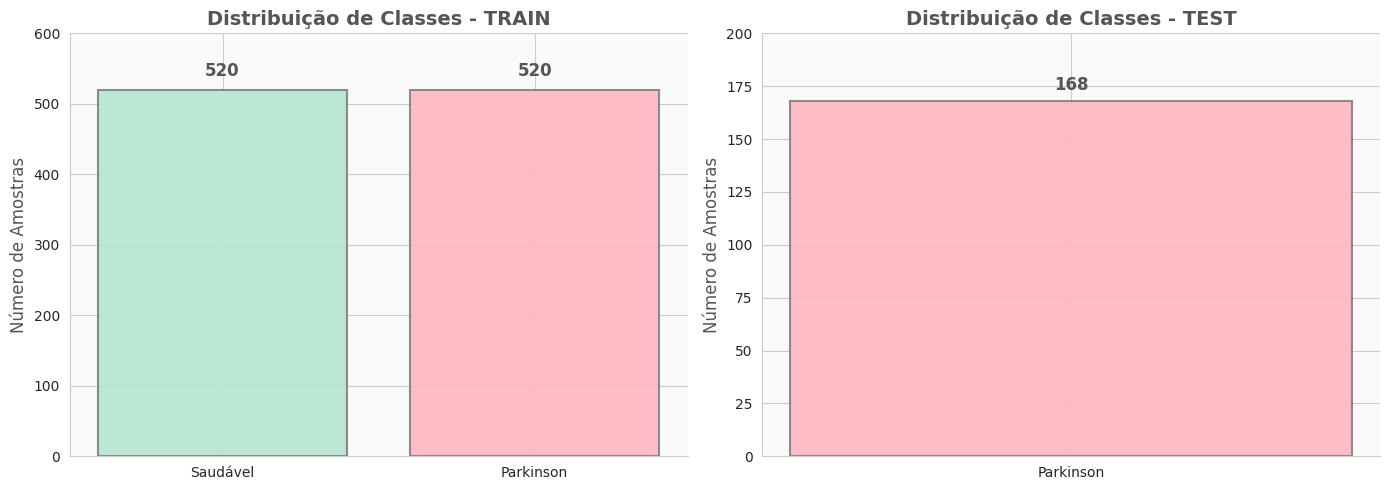

In [ ]:
# REMOVER
# ============================================================
# 1 DISTRIBUIÇÃO DE CLASSES
# ============================================================


print("\n 1. Distribuição de Classes")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TRAIN
class_counts_train = train['class'].value_counts()
colors_class = [COLOR_HEALTHY, COLOR_PD]
axes[0].bar(['Saudável', 'Parkinson'], class_counts_train.values,
            color=colors_class, edgecolor='gray', linewidth=1.5, alpha=0.9)
axes[0].set_title('Distribuição de Classes - TRAIN', fontsize=14, fontweight='bold', color='#555')
axes[0].set_ylabel('Número de Amostras', fontsize=12, color='#555')
axes[0].set_ylim(0, 600)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, v in enumerate(class_counts_train.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=12, fontweight='bold', color='#555')

# TEST
axes[1].bar(['Parkinson'], [len(test)], color=COLOR_PD, edgecolor='gray', linewidth=1.5, alpha=0.9)
axes[1].set_title('Distribuição de Classes - TEST', fontsize=14, fontweight='bold', color='#555')
axes[1].set_ylabel('Número de Amostras', fontsize=12, color='#555')
axes[1].set_ylim(0, 200)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].text(0, len(test) + 5, str(len(test)), ha='center', fontsize=12, fontweight='bold', color='#555')

plt.tight_layout()
plt.show()


 2. Distribuição por Tipo de Som


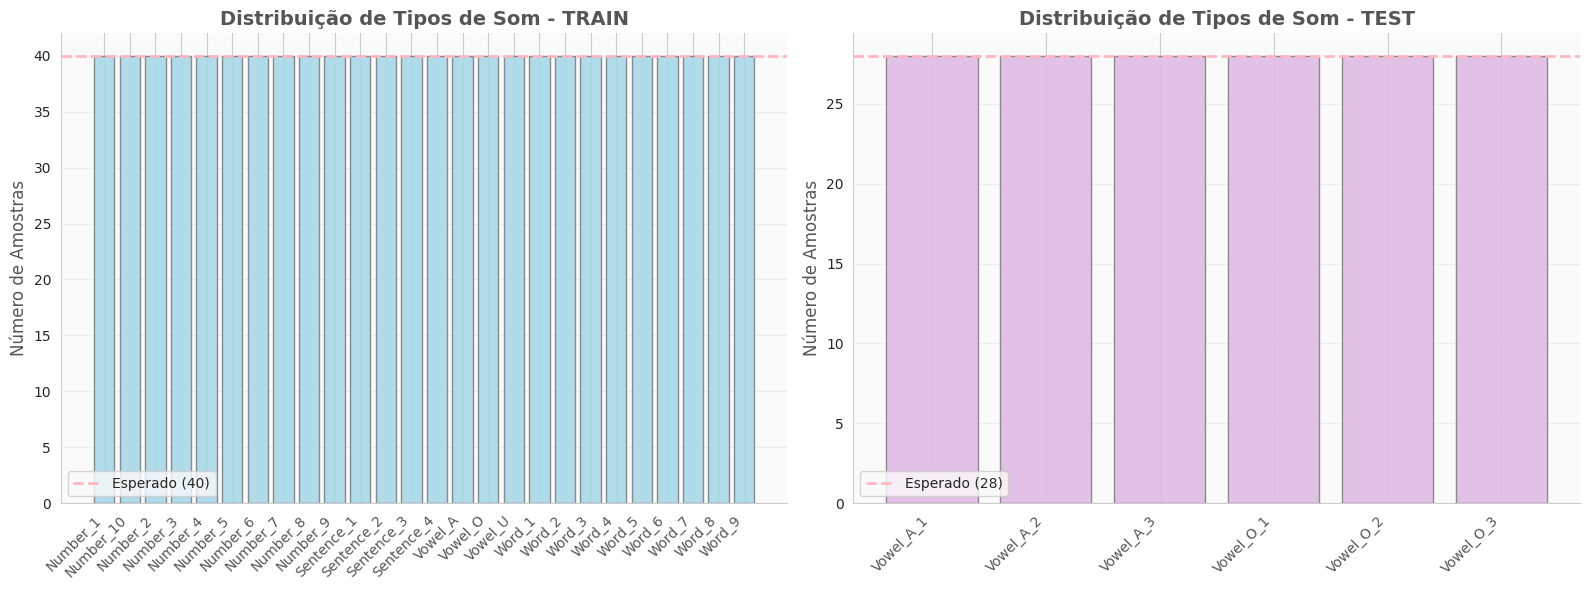

In [ ]:
# REMOVER
# ============================================================
# 2 DISTRIBUIÇÃO POR TIPO DE SOM
# ============================================================

print("\n 2. Distribuição por Tipo de Som")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TRAIN
sample_counts_train = train['sample_type'].value_counts().sort_index()
axes[0].bar(range(len(sample_counts_train)), sample_counts_train.values,
            color=PASTEL_BLUE, edgecolor='gray', linewidth=1, alpha=0.9)
axes[0].set_xticks(range(len(sample_counts_train)))
axes[0].set_xticklabels(sample_counts_train.index, rotation=45, ha='right', color='#555')
axes[0].set_title('Distribuição de Tipos de Som - TRAIN', fontsize=14, fontweight='bold', color='#555')
axes[0].set_ylabel('Número de Amostras', fontsize=12, color='#555')
axes[0].axhline(y=40, color=PASTEL_PINK, linestyle='--', linewidth=2, label='Esperado (40)')
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# TEST
sample_counts_test = test['sample_type'].value_counts().sort_index()
axes[1].bar(range(len(sample_counts_test)), sample_counts_test.values,
            color=PASTEL_LAVENDER, edgecolor='gray', linewidth=1, alpha=0.9)
axes[1].set_xticks(range(len(sample_counts_test)))
axes[1].set_xticklabels(sample_counts_test.index, rotation=45, ha='right', color='#555')
axes[1].set_title('Distribuição de Tipos de Som - TEST', fontsize=14, fontweight='bold', color='#555')
axes[1].set_ylabel('Número de Amostras', fontsize=12, color='#555')
axes[1].axhline(y=28, color=PASTEL_PINK, linestyle='--', linewidth=2, label='Esperado (28)')
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


 3. BoxPlots - Comparação entre Categorias


/tmp/ipython-input-1061295912.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_plot, labels=categorias.keys(), patch_artist=True,
/tmp/ipython-input-1061295912.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_plot, labels=categorias.keys(), patch_artist=True,
/tmp/ipython-input-1061295912.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_plot, labels=categorias.keys(), patch_artist=True,
/tmp/ipython-input-1061295912.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

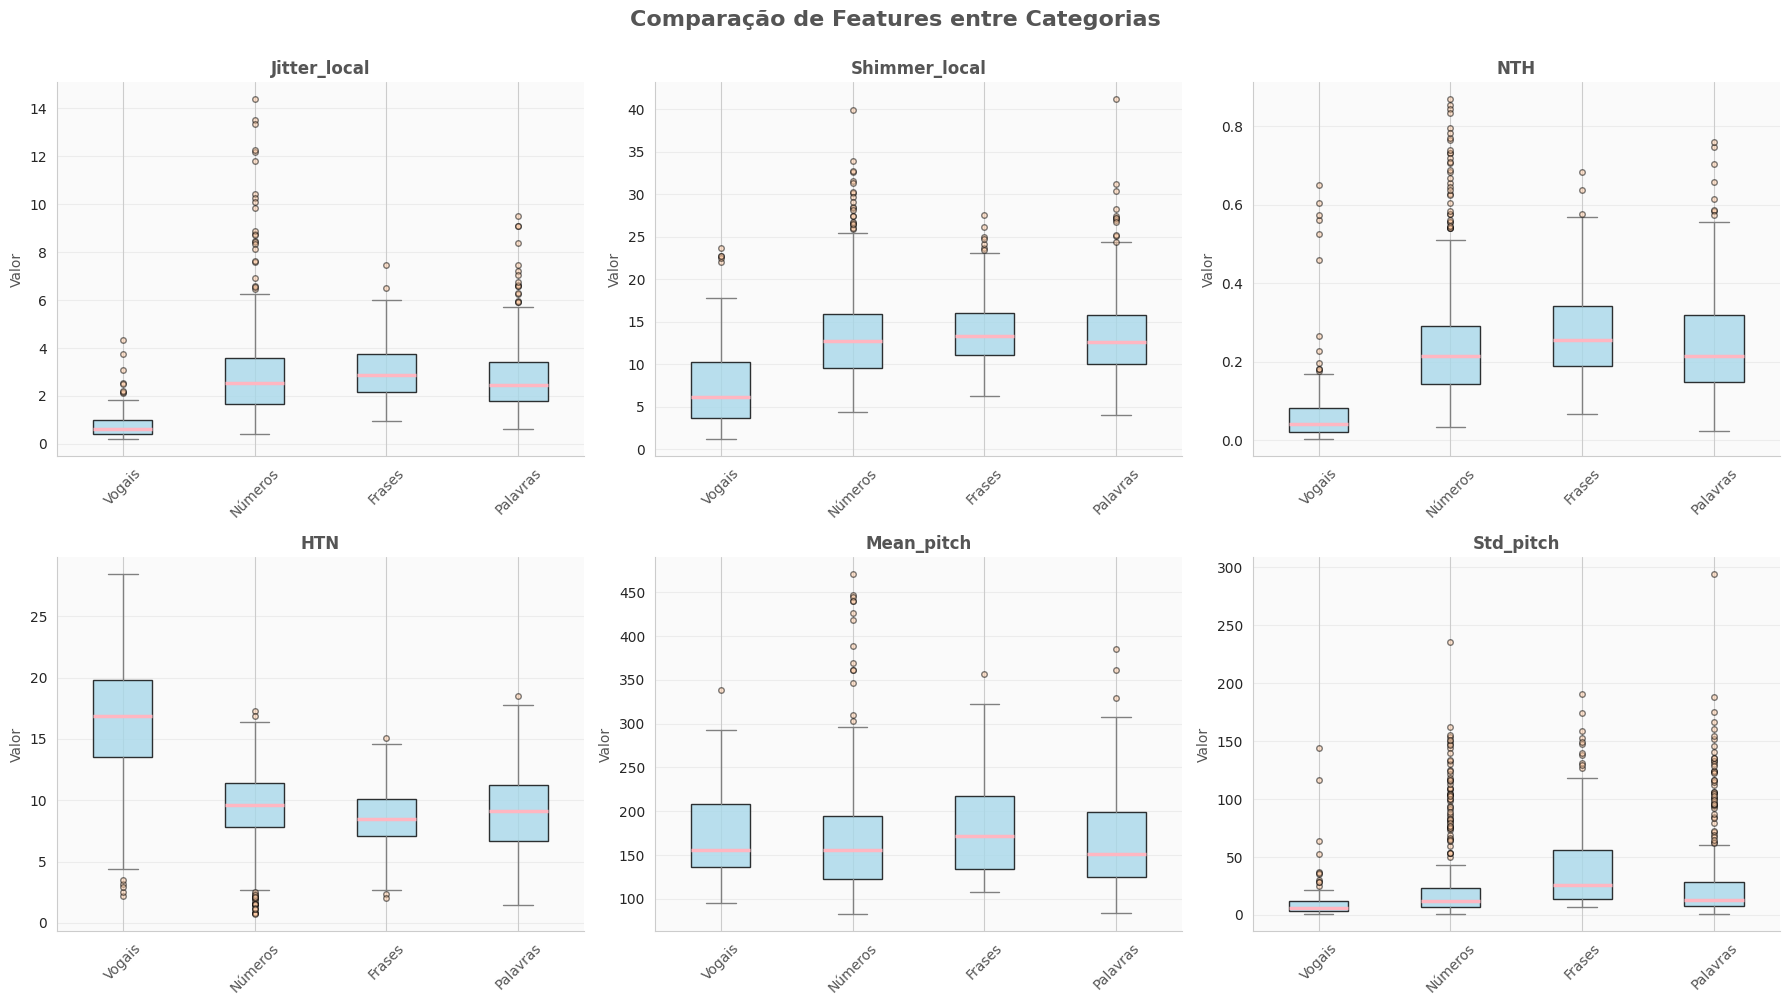

In [ ]:
# ============================================================
# 3 BOXPLOTS: COMPARAÇÃO ENTRE CATEGORIAS
# ============================================================

print("\n 3. BoxPlots - Comparação entre Categorias")

categorias = {
    'Vogais': vogais_train,
    'Números': numeros_train,
    'Frases': frases_train,
    'Palavras': palavras_train
}

features_para_boxplot = ['Jitter_local', 'Shimmer_local', 'NTH', 'HTN',
                          'Mean_pitch', 'Std_pitch']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feature in enumerate(features_para_boxplot):
    data_plot = [df[feature].values for df in categorias.values()]
    bp = axes[i].boxplot(data_plot, labels=categorias.keys(), patch_artist=True,
                          boxprops=dict(facecolor=PASTEL_BLUE, alpha=0.8),
                          medianprops=dict(color=PASTEL_PINK, linewidth=2.5),
                          whiskerprops=dict(color='gray'),
                          capprops=dict(color='gray'),
                          flierprops=dict(markerfacecolor=PASTEL_ORANGE, marker='o',
                                         markersize=4, alpha=0.5))

    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold', color='#555')
    axes[i].set_ylabel('Valor', fontsize=10, color='#555')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45, colors='#555')

plt.suptitle('Comparação de Features entre Categorias', fontsize=16, fontweight='bold',
             color='#555', y=1.00)
plt.tight_layout()
plt.show()


 4. BoxPlots - PD vs Saudáveis


/tmp/ipython-input-1605557834.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_healthy, data_pd],
/tmp/ipython-input-1605557834.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_healthy, data_pd],
/tmp/ipython-input-1605557834.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_healthy, data_pd],
/tmp/ipython-input-1605557834.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_hea

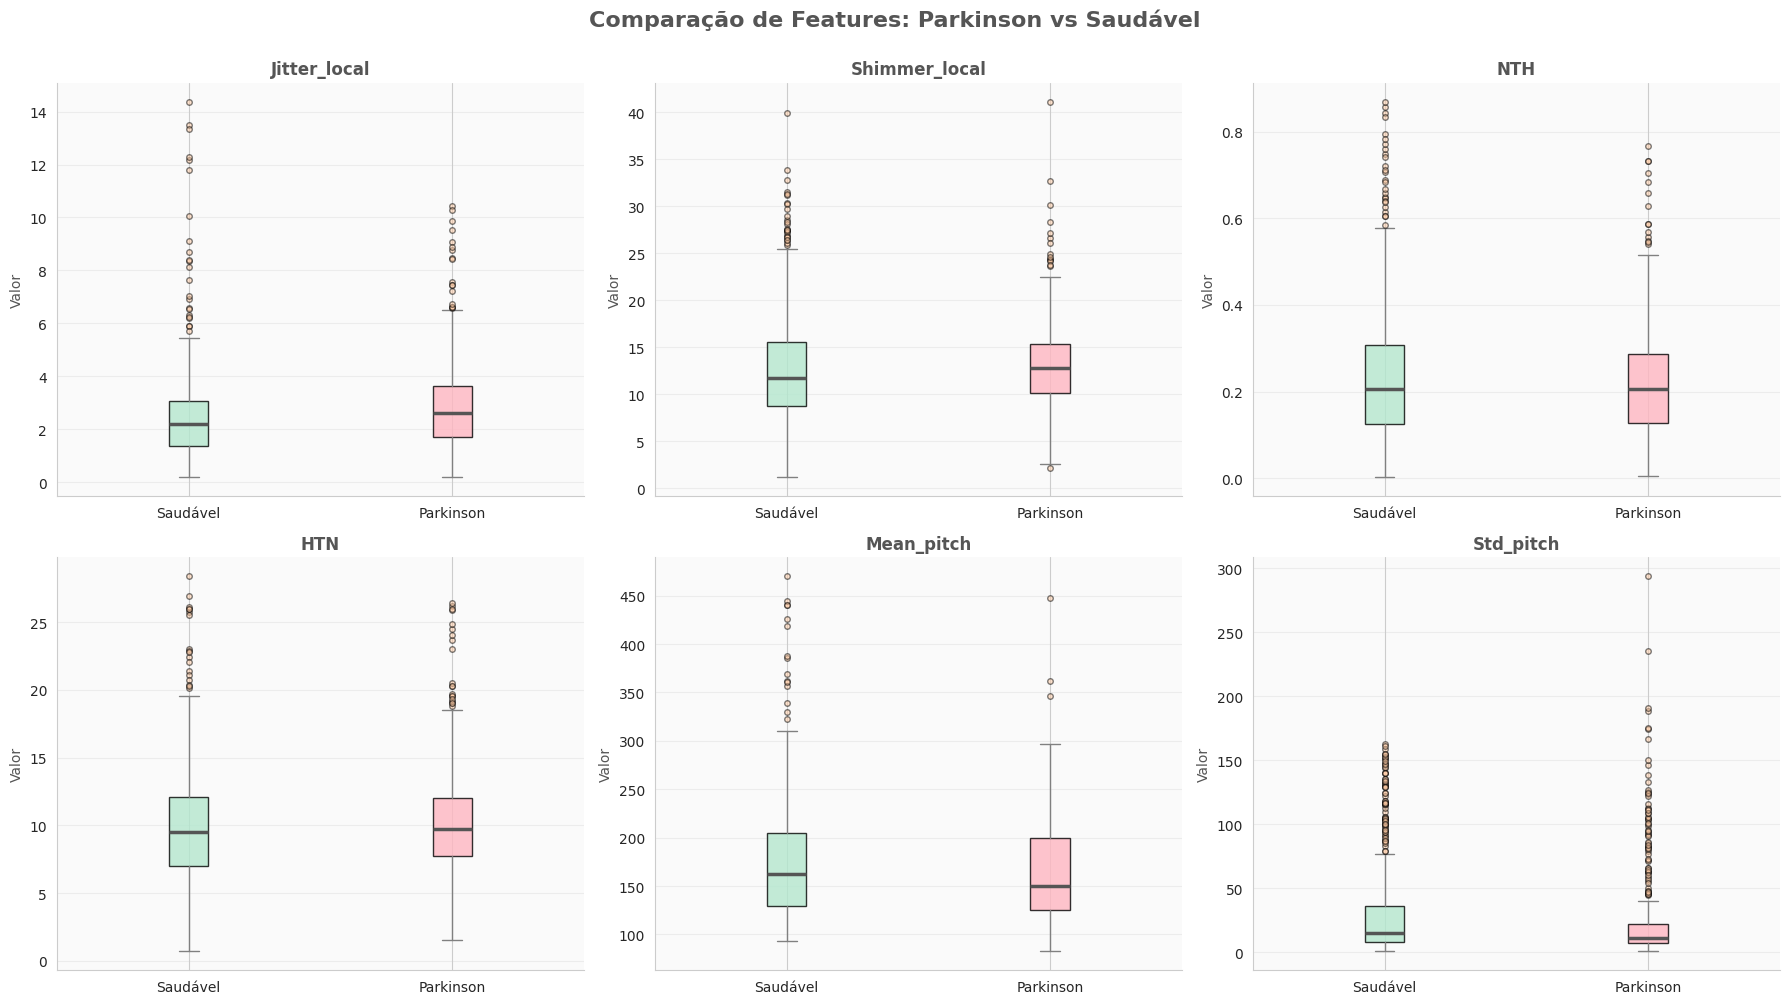

In [ ]:
# ============================================================
# 4 BOXPLOTS: PD vs SAUDÁVEIS
# ============================================================

print("\n 4. BoxPlots - PD vs Saudáveis")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feature in enumerate(features_para_boxplot):
    data_pd = train[train['class'] == 1][feature]
    data_healthy = train[train['class'] == 0][feature]

    bp = axes[i].boxplot([data_healthy, data_pd],
                          labels=['Saudável', 'Parkinson'],
                          patch_artist=True,
                          medianprops=dict(color='#555', linewidth=2.5),
                          whiskerprops=dict(color='gray'),
                          capprops=dict(color='gray'),
                          flierprops=dict(markerfacecolor=PASTEL_ORANGE, marker='o',
                                         markersize=4, alpha=0.5))

    bp['boxes'][0].set_facecolor(COLOR_HEALTHY)
    bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor(COLOR_PD)
    bp['boxes'][1].set_alpha(0.8)

    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold', color='#555')
    axes[i].set_ylabel('Valor', fontsize=10, color='#555')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Comparação de Features: Parkinson vs Saudável', fontsize=16,
             fontweight='bold', color='#555', y=1.00)
plt.tight_layout()
plt.show()


 5. Histogramas - Distribuição das Features


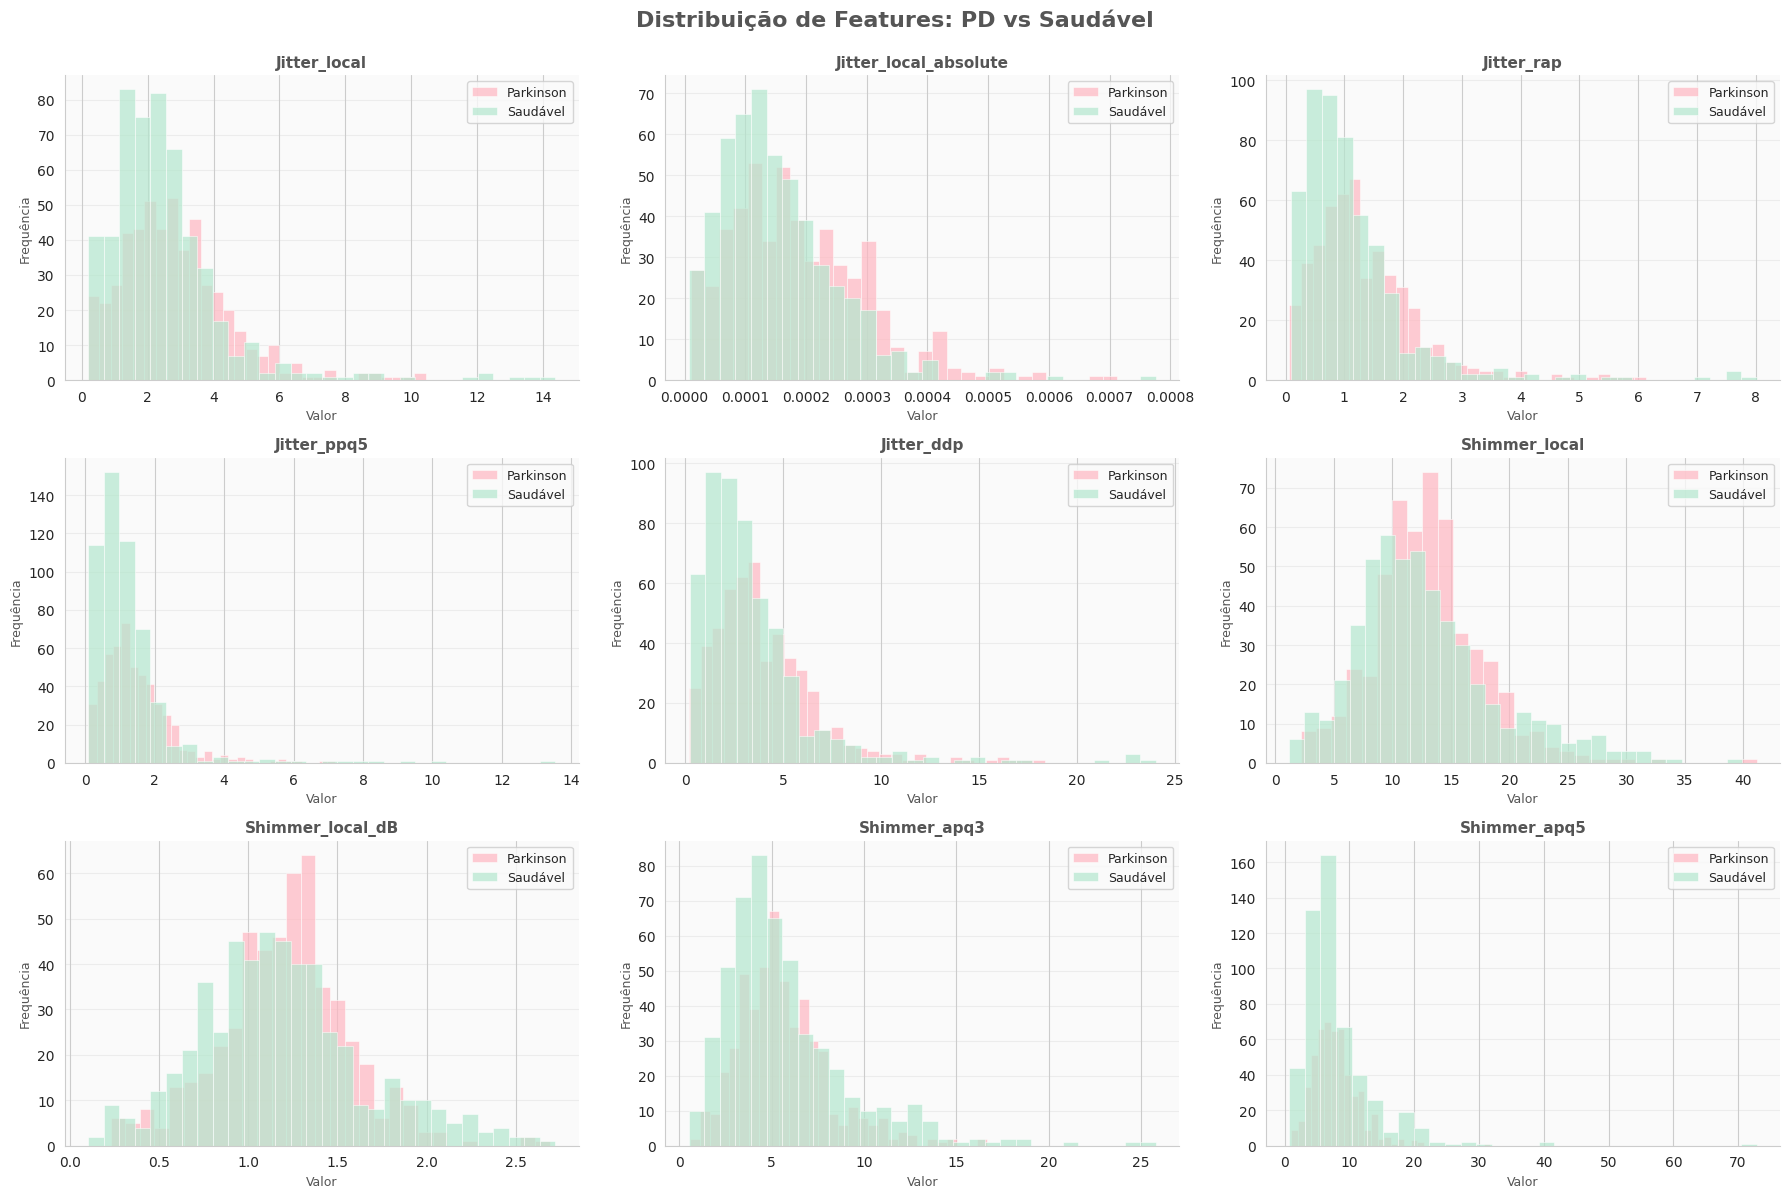

In [ ]:
# ============================================================
# 5 HISTOGRAMAS: DISTRIBUIÇÃO DAS FEATURES
# ============================================================

print("\n 5. Histogramas - Distribuição das Features")

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

features_para_hist = feature_names[:9]

for i, feature in enumerate(features_para_hist):
    axes[i].hist(train[train['class'] == 1][feature], bins=30,
                 alpha=0.7, color=COLOR_PD, label='Parkinson', edgecolor='white', linewidth=0.5)
    axes[i].hist(train[train['class'] == 0][feature], bins=30,
                 alpha=0.7, color=COLOR_HEALTHY, label='Saudável', edgecolor='white', linewidth=0.5)

    axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold', color='#555')
    axes[i].set_xlabel('Valor', fontsize=9, color='#555')
    axes[i].set_ylabel('Frequência', fontsize=9, color='#555')
    axes[i].legend(fontsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribuição de Features: PD vs Saudável', fontsize=16,
             fontweight='bold', color='#555', y=0.995)
plt.tight_layout()
plt.show()



 6. Matriz de Correlação


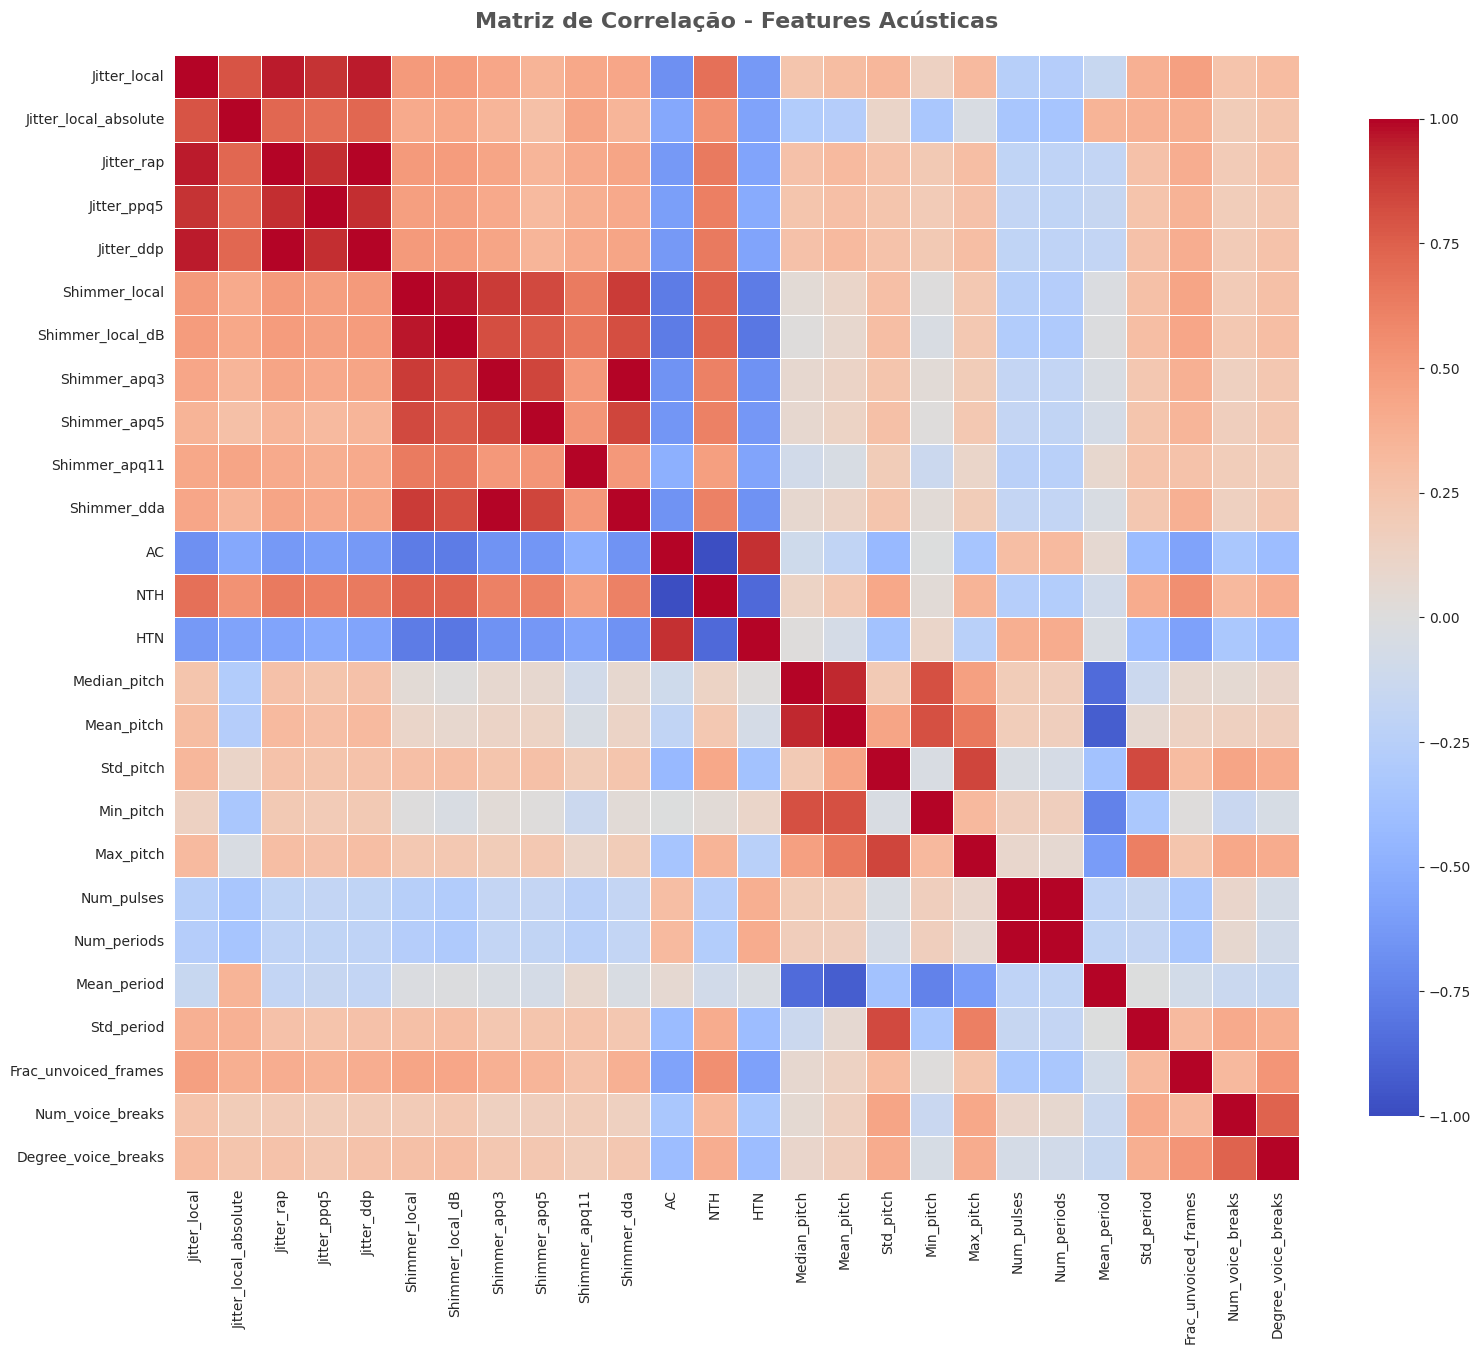


 Correlação de cada feature com a classe (Parkinson):
Jitter_local_absolute    0.166999
Shimmer_apq11            0.146326
Jitter_rap               0.111144
Jitter_ddp               0.111138
Jitter_ppq5              0.110934
Jitter_local             0.097552
Mean_period              0.081763
AC                       0.081095
Num_periods              0.047103
Num_pulses               0.041038
HTN                      0.040507
Shimmer_local_dB         0.027190
Shimmer_local            0.009062
Shimmer_apq3            -0.018156
Shimmer_dda             -0.018158
Shimmer_apq5            -0.022581
Std_period              -0.058788
Min_pitch               -0.059104
NTH                     -0.076077
Num_voice_breaks        -0.079831
Median_pitch            -0.084222
Mean_pitch              -0.103270
Std_pitch               -0.121074
Frac_unvoiced_frames    -0.122044
Degree_voice_breaks     -0.126151
Max_pitch               -0.139398
Name: class, dtype: float64


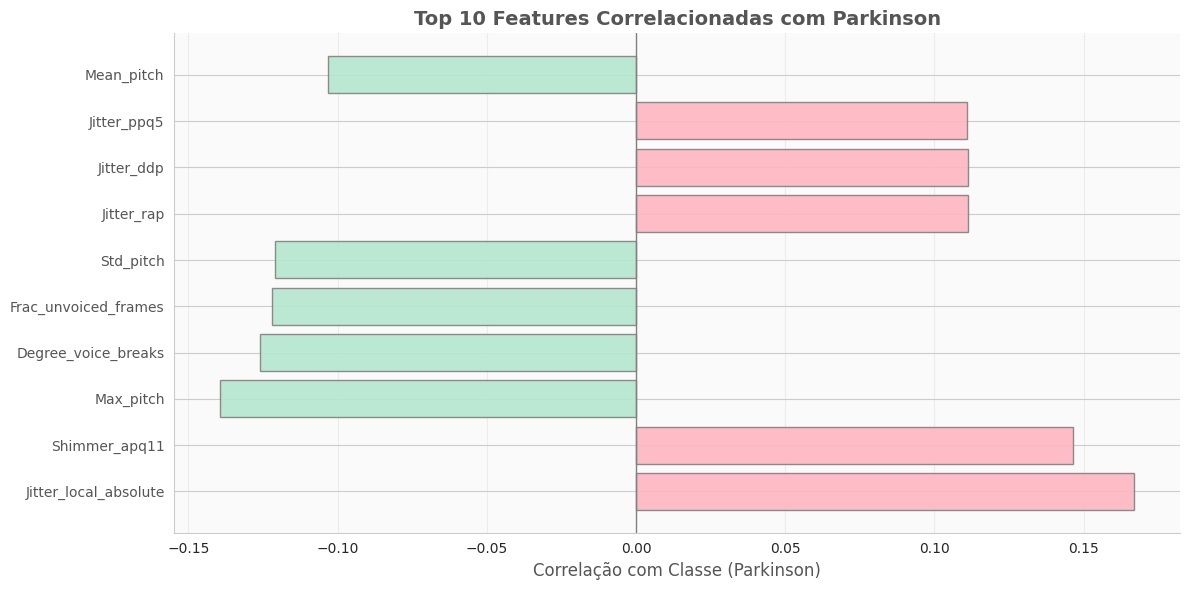

In [ ]:
# ============================================================
# 6 MATRIZ DE CORRELAÇÃO
# ============================================================

print("\n 6. Matriz de Correlação")

correlation_matrix = train[feature_names].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Matriz de Correlação - Features Acústicas', fontsize=16,
          fontweight='bold', pad=20, color='#555')
plt.tight_layout()
plt.show()

# Correlação com a classe
print("\n Correlação de cada feature com a classe (Parkinson):")
correlation_with_class = train[feature_names + ['class']].corr()['class'].drop('class').sort_values(ascending=False)
print(correlation_with_class)

# Visualizar top 10 correlações
plt.figure(figsize=(12, 6))
top_10 = correlation_with_class.abs().sort_values(ascending=False)[:10]
colors_corr = [COLOR_PD if x > 0 else COLOR_HEALTHY for x in correlation_with_class[top_10.index]]
plt.barh(range(len(top_10)), correlation_with_class[top_10.index].values,
         color=colors_corr, edgecolor='gray', alpha=0.9)
plt.yticks(range(len(top_10)), top_10.index, color='#555')
plt.xlabel('Correlação com Classe (Parkinson)', fontsize=12, color='#555')
plt.title('Top 10 Features Correlacionadas com Parkinson', fontsize=14,
          fontweight='bold', color='#555')
plt.axvline(x=0, color='gray', linewidth=1)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



 7. Scatter Plots - Features vs Classe


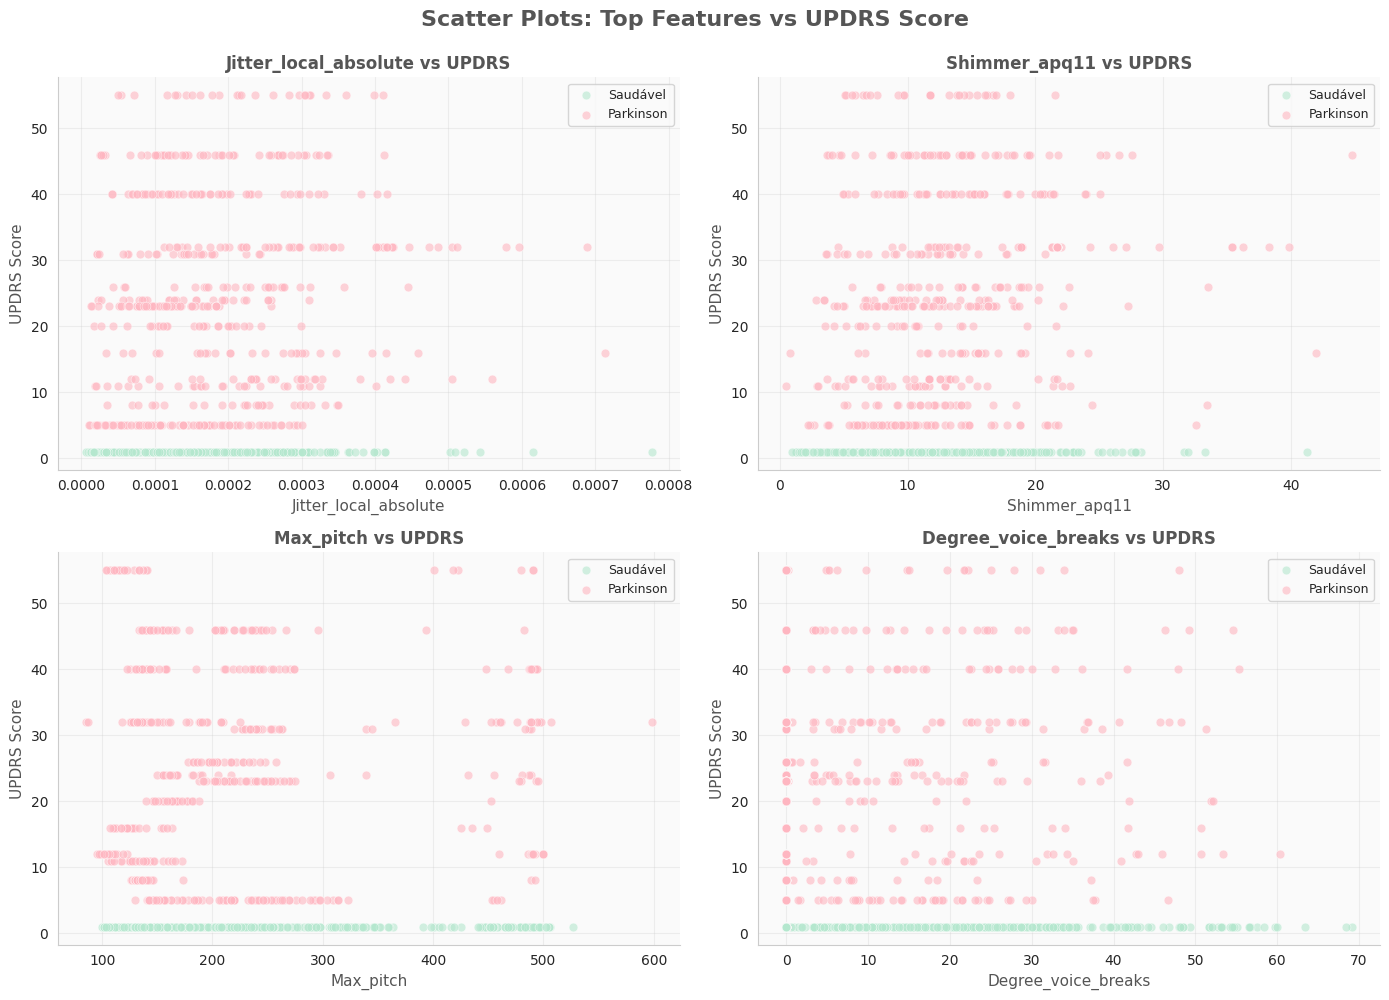

In [ ]:
# ============================================================
# 7 SCATTER PLOTS: FEATURES MAIS CORRELACIONADAS
# ============================================================

print("\n 7. Scatter Plots - Features vs Classe")

top_4_features = correlation_with_class.abs().sort_values(ascending=False)[:4].index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(top_4_features):
    axes[i].scatter(train[train['class'] == 0][feature],
                    train[train['class'] == 0]['UPDRS'],
                    alpha=0.6, s=40, color=COLOR_HEALTHY, label='Saudável',
                    edgecolor='white', linewidth=0.5)
    axes[i].scatter(train[train['class'] == 1][feature],
                    train[train['class'] == 1]['UPDRS'],
                    alpha=0.6, s=40, color=COLOR_PD, label='Parkinson',
                    edgecolor='white', linewidth=0.5)

    axes[i].set_xlabel(feature, fontsize=11, color='#555')
    axes[i].set_ylabel('UPDRS Score', fontsize=11, color='#555')
    axes[i].set_title(f'{feature} vs UPDRS', fontsize=12, fontweight='bold', color='#555')
    axes[i].legend(fontsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(alpha=0.3)

plt.suptitle('Scatter Plots: Top Features vs UPDRS Score', fontsize=16,
             fontweight='bold', color='#555', y=0.995)
plt.tight_layout()
plt.show()



 8. Violin Plots - Distribuição por Categoria


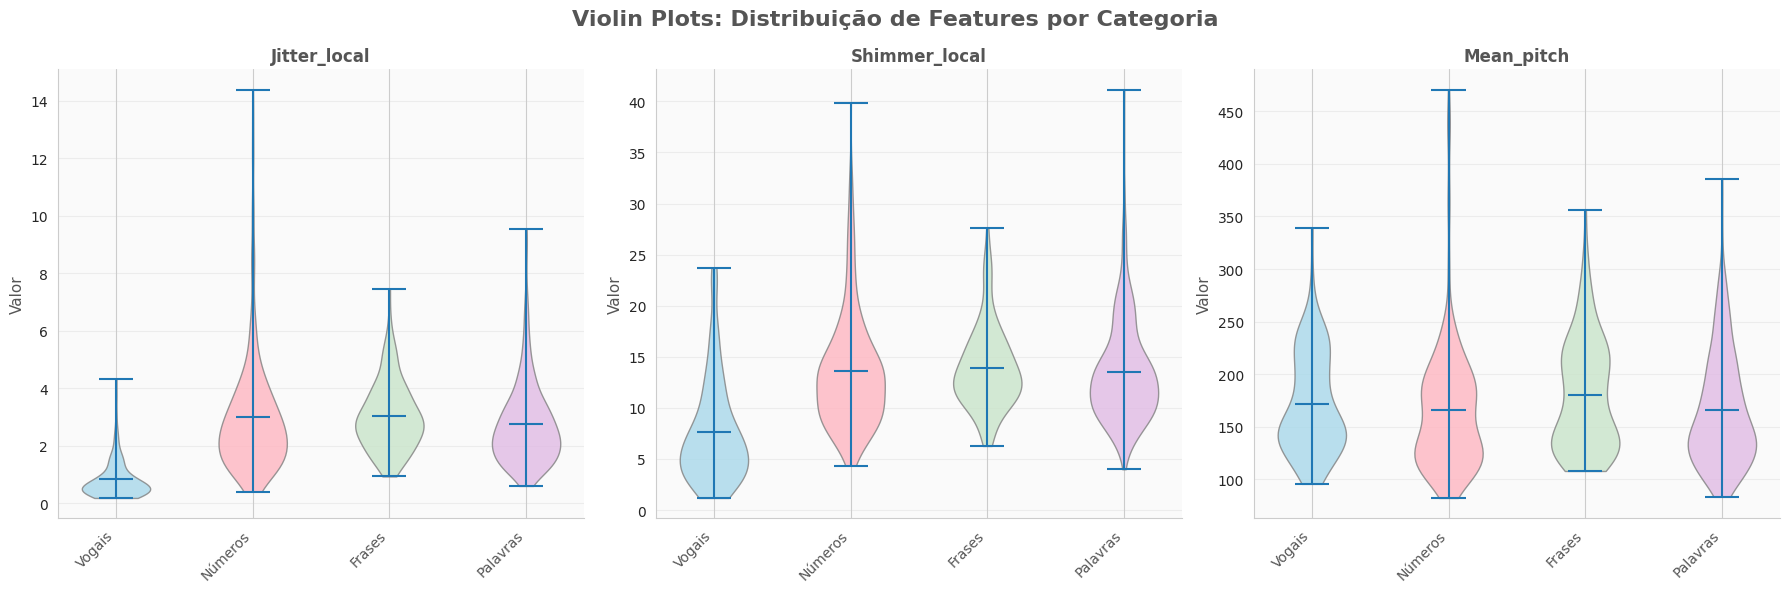

In [ ]:
# ============================================================
# 8 VIOLINPLOTS: DISTRIBUIÇÃO POR CATEGORIA
# ============================================================

print("\n 8. Violin Plots - Distribuição por Categoria")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

features_violin = ['Jitter_local', 'Shimmer_local', 'Mean_pitch']

for i, feature in enumerate(features_violin):
    data_for_violin = []
    labels_violin = []

    for nome, df in categorias.items():
        data_for_violin.append(df[feature].values)
        labels_violin.append(nome)

    parts = axes[i].violinplot(data_for_violin, positions=range(len(categorias)),
                                showmeans=True, showextrema=True)

    # Colorir violinos com paleta pastel
    for pc, color in zip(parts['bodies'], COLORS_CATEGORIES):
        pc.set_facecolor(color)
        pc.set_alpha(0.8)
        pc.set_edgecolor('gray')

    axes[i].set_xticks(range(len(categorias)))
    axes[i].set_xticklabels(labels_violin, rotation=45, ha='right', color='#555')
    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold', color='#555')
    axes[i].set_ylabel('Valor', fontsize=11, color='#555')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Violin Plots: Distribuição de Features por Categoria', fontsize=16,
             fontweight='bold', color='#555')
plt.tight_layout()
plt.show()



 9. Heatmap - Diferença PD vs Saudável por Categoria


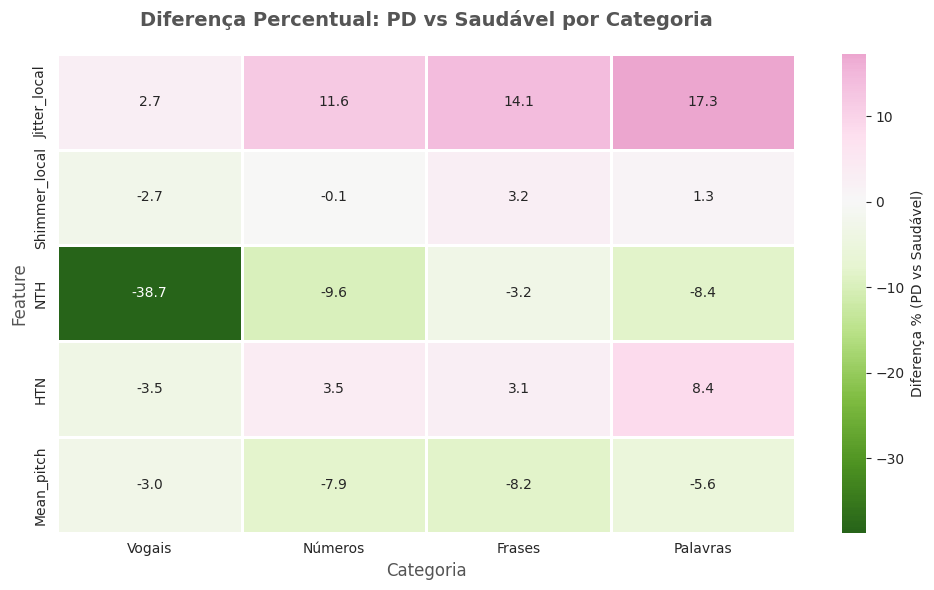

In [ ]:
# ============================================================
# 9 HEATMAP: DIFERENÇA PD vs SAUDÁVEIS POR CATEGORIA
# ============================================================

print("\n 9. Heatmap - Diferença PD vs Saudável por Categoria")

diff_data = []
features_diff = ['Jitter_local', 'Shimmer_local', 'NTH', 'HTN', 'Mean_pitch']

for feature in features_diff:
    row = []
    for nome, df in categorias.items():
        pd_mean = df[df['class'] == 1][feature].mean()
        healthy_mean = df[df['class'] == 0][feature].mean()
        diff_percent = ((pd_mean - healthy_mean) / healthy_mean * 100) if healthy_mean != 0 else 0
        row.append(diff_percent)
    diff_data.append(row)

plt.figure(figsize=(10, 6))
sns.heatmap(diff_data, annot=True, fmt='.1f', cmap='PiYG_r', center=0,
            xticklabels=categorias.keys(), yticklabels=features_diff,
            cbar_kws={'label': 'Diferença % (PD vs Saudável)'}, linewidths=1, linecolor='white')
plt.title('Diferença Percentual: PD vs Saudável por Categoria', fontsize=14,
          fontweight='bold', pad=20, color='#555')
plt.ylabel('Feature', fontsize=12, color='#555')
plt.xlabel('Categoria', fontsize=12, color='#555')
plt.tight_layout()
plt.show()


 10. Distribuição do UPDRS Score...


/tmp/ipython-input-3712923116.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(updrs_by_cat, labels=categorias.keys(), patch_artist=True,


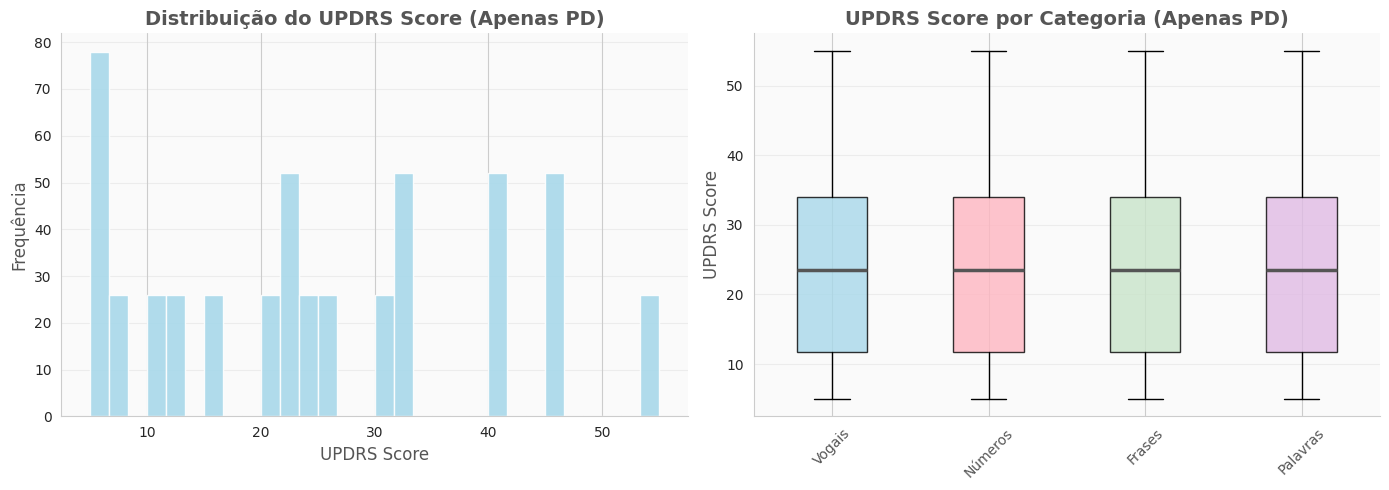

In [ ]:
# ============================================================
# 10 DISTRIBUIÇÃO DE UPDRS
# ============================================================

print("\n 10. Distribuição do UPDRS Score...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(train[train['class'] == 1]['UPDRS'], bins=30, color=PASTEL_BLUE,
             edgecolor='white', alpha=0.9)
axes[0].set_title('Distribuição do UPDRS Score (Apenas PD)', fontsize=14,
                  fontweight='bold', color='#555')
axes[0].set_xlabel('UPDRS Score', fontsize=12, color='#555')
axes[0].set_ylabel('Frequência', fontsize=12, color='#555')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# BoxPlot por categoria
updrs_by_cat = [df[df['class'] == 1]['UPDRS'].values for df in categorias.values()]
bp = axes[1].boxplot(updrs_by_cat, labels=categorias.keys(), patch_artist=True,
                      medianprops=dict(color='#555', linewidth=2.5))
for patch, color in zip(bp['boxes'], COLORS_CATEGORIES):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('UPDRS Score por Categoria (Apenas PD)', fontsize=14,
                  fontweight='bold', color='#555')
axes[1].set_ylabel('UPDRS Score', fontsize=12, color='#555')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='x', rotation=45, colors='#555')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
# ============================================================
# 🔁 Ajuste final do TRAIN para alinhar com TEST (removendo UPDRS)
# ============================================================

import numpy as np

# Garantir que os nomes de coluna ainda são string
train.columns = [str(c) for c in train.columns]
test.columns  = [str(c) for c in test.columns]

# Agora vamos montar o train_final SEM a coluna '27' (UPDRS)
# e mantendo a coluna '28' (class)
# Ordem alvo: ['0', '1', ..., '26', '28']
colunas_treinoraw_sem_updrs = [str(i) for i in range(0, 27)] + ['28']

train = train[colunas_treinoraw_sem_updrs]

print("✅ Reconstruímos o train SEM a coluna considerada UPDRS.")
print("Novo shape do train:", train.shape)
print("Primeiras colunas do train:", train.columns[:5].tolist(), "...")
print("Últimas colunas do train:", train.columns[-5:].tolist(), "\n")

# Agora renomear tanto train quanto test com o schema final

feature_names = [
    'Jitter_local', 'Jitter_local_absolute', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp',
    'Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5',
    'Shimmer_apq11', 'Shimmer_dda', 'AC', 'NTH', 'HTN',
    'Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch',
    'Num_pulses', 'Num_periods', 'Mean_period', 'Std_period',
    'Frac_unvoiced_frames', 'Num_voice_breaks', 'Degree_voice_breaks'
]

expected_cols = ['subject_id'] + feature_names + ['class']  # total 28

# Renomear o train agora que ele tem 28 colunas certas
train.columns = expected_cols

# O test já tinha 28 colunas e já estava renomeado antes,
# mas vamos garantir consistência (caso ainda estivesse numérico)
if list(test.columns)[0] != 'subject_id':
    test.columns = expected_cols

print("✅ Colunas finais aplicadas nos dois dataframes!")
print("Train ->", train.columns[:3].tolist(), "...", train.columns[-3:].tolist())
print("Test  ->", test.columns[:3].tolist(),  "...", test.columns[-3:].tolist())

# -------------------------------
# 📊 Checagem de integridade pós-ajuste
# -------------------------------
print("\n🔍 Verificação básica pós-ajuste:")
print(f"Subject IDs únicos (train): {train['subject_id'].nunique()}")
print(f"Subject IDs únicos (test):  {test['subject_id'].nunique()}")
print(f"Distribuição de classes no train: {train['class'].value_counts().to_dict()}")
print(f"Distribuição de classes no test : {test['class'].value_counts().to_dict()}")

# ============================================================
# 🔢 CRIAR sample_number
# ============================================================

print("\n" + "="*70)
print("🔢 CRIANDO sample_number")
print("="*70)

train['sample_number'] = train.groupby('subject_id').cumcount() + 1
test['sample_number']  = test.groupby('subject_id').cumcount() + 1

print("\n✅ sample_number criado com sucesso!")
print("\nTRAIN - Primeiras 10 linhas:")
print(train[['subject_id', 'sample_number', 'class']].head(10))

print("\nTEST - Primeiras 10 linhas:")
print(test[['subject_id', 'sample_number', 'class']].head(10))

print(f"\n🔍 Validação:")
print(f"sample_number no TRAIN: min={train['sample_number'].min()}, max={train['sample_number'].max()}")
print(f"sample_number no TEST:  min={test['sample_number'].min()}, max={test['sample_number'].max()}")
print(f"Amostras por pessoa (train): {train.groupby('subject_id').size().unique()}")
print(f"Amostras por pessoa (test):  {test.groupby('subject_id').size().unique()}")

# ============================================================
# 🎙️ MAPEANDO TIPOS DE SOM
# ============================================================

print("\n" + "="*70)
print("🎙️ MAPEANDO TIPOS DE SOM")
print("="*70)

train_sample_map = {
    1:'Vowel_A',2:'Vowel_O',3:'Vowel_U',
    4:'Number_1',5:'Number_2',6:'Number_3',7:'Number_4',8:'Number_5',
    9:'Number_6',10:'Number_7',11:'Number_8',12:'Number_9',13:'Number_10',
    14:'Sentence_1',15:'Sentence_2',16:'Sentence_3',17:'Sentence_4',
    18:'Word_1',19:'Word_2',20:'Word_3',21:'Word_4',22:'Word_5',
    23:'Word_6',24:'Word_7',25:'Word_8',26:'Word_9'
}

test_sample_map = {
    1:'Vowel_A_1',2:'Vowel_A_2',3:'Vowel_A_3',
    4:'Vowel_O_1',5:'Vowel_O_2',6:'Vowel_O_3'
}

train['sample_type'] = train['sample_number'].map(train_sample_map)
test['sample_type']  = test['sample_number'].map(test_sample_map)

print("\n✅ sample_type mapeado!")
print("\nTRAIN - Distribuição de tipos:")
print(train['sample_type'].value_counts().sort_index())

print("\nTEST - Distribuição de tipos:")
print(test['sample_type'].value_counts().sort_index())

# ============================================================
# 👁️ VISUALIZAÇÃO FINAL
# ============================================================

print("\n" + "="*70)
print("👁️ VISUALIZAÇÃO DOS DADOS ORGANIZADOS (SEM UPDRS)")
print("="*70)

print("\n🔹 Amostra do conjunto de treino (primeiras 20 linhas):")
display(train[['subject_id', 'sample_number', 'sample_type', 'class']].head(20))

print("\n🔹 Amostra do conjunto de teste (primeiras 20 linhas):")
display(test[['subject_id', 'sample_number', 'sample_type', 'class']].head(20))


✅ Reconstruímos o train SEM a coluna considerada UPDRS.
Novo shape do train: (1040, 28)
Primeiras colunas do train: ['0', '1', '2', '3', '4'] ...
Últimas colunas do train: ['23', '24', '25', '26', '28'] 

✅ Colunas finais aplicadas nos dois dataframes!
Train -> ['subject_id', 'Jitter_local', 'Jitter_local_absolute'] ... ['Num_voice_breaks', 'Degree_voice_breaks', 'class']
Test  -> ['subject_id', 'Jitter_local', 'Jitter_local_absolute'] ... ['Num_voice_breaks', 'Degree_voice_breaks', 'class']

🔍 Verificação básica pós-ajuste:
Subject IDs únicos (train): 40
Subject IDs únicos (test):  28
Distribuição de classes no train: {1: 520, 0: 520}
Distribuição de classes no test : {1: 168}

🔢 CRIANDO sample_number

✅ sample_number criado com sucesso!

TRAIN - Primeiras 10 linhas:
   subject_id  sample_number  class
0           1              1      1
1           1              2      1
2           1              3      1
3           1              4      1
4           1              5      1
5    

,subject_id,sample_number,sample_type,class
0,1,1,Vowel_A,1
1,1,2,Vowel_O,1
2,1,3,Vowel_U,1
3,1,4,Number_1,1
4,1,5,Number_2,1
5,1,6,Number_3,1
6,1,7,Number_4,1
7,1,8,Number_5,1
8,1,9,Number_6,1
9,1,10,Number_7,1



🔹 Amostra do conjunto de teste (primeiras 20 linhas):


,subject_id,sample_number,sample_type,class
0,1,1,Vowel_A_1,1
1,1,2,Vowel_A_2,1
2,1,3,Vowel_A_3,1
3,1,4,Vowel_O_1,1
4,1,5,Vowel_O_2,1
5,1,6,Vowel_O_3,1
6,2,1,Vowel_A_1,1
7,2,2,Vowel_A_2,1
8,2,3,Vowel_A_3,1
9,2,4,Vowel_O_1,1


# ANOTAÇÕES

Remover a DISTRIBUIÇÃO DE CLASSES, DISTRIBUIÇÃO POR TIPO DE SOM, SCATTER PLOTS: FEATURES MAIS CORRELACIONADAS,

Ajustar BOXPLOTS: COMPARAÇÃO ENTRE CATEGORIAS, HISTOGRAMAS: DISTRIBUIÇÃO DAS FEATURES, MATRIZ DE CORRELAÇÃO, HEATMAP: DIFERENÇA PD vs SAUDÁVEIS POR CATEGORIA, VIOLINPLOTS: DISTRIBUIÇÃO POR CATEGORIA

Adicionar as distribuições por idade e gênero

Adicionar os cruzamentos entre as distribuições

Comparativos entre: pd e controle